# Projet 6 - Élaborez un modèle de scoring

In [9]:
!pip install missingno

import missingno as msno


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("Projet+Mise+en+prod+-+home-credit-default-risk")

fichiers = {
    "application_test" : "application_test.csv",
    "application_train" : "application_train.csv",
    "bureau_balance" : "bureau_balance.csv",
    "bureau" : "bureau.csv",
    "credit_card_balance" : "credit_card_balance.csv",
    "installments_payments" : "installments_payments.csv",
    "POS_CASH" : "POS_CASH_balance.csv",
    "prev_application" : "previous_application.csv",
    "sample_submission" : "sample_submission.csv",
}

# For loop  
dfs = {}  # empty dictionary at first
for nom, fichier in fichiers.items():
    dfs[nom] = pd.read_csv(DATA_DIR / fichier)

# access : dfs["application_train"], dfs["bureau"], etc.

columns_description = pd.read_csv(DATA_DIR / "HomeCredit_columns_description.csv", encoding="cp1252") 

##### 1. columns_description table

In [11]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(columns_description)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


##### 2. POS_CASH table

In [12]:
dfs['POS_CASH']

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0
...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.0,0.0,Active,843,0
10001354,1717234,141565,-19,12.0,0.0,Active,602,0
10001355,1283126,315695,-21,10.0,0.0,Active,609,0
10001356,1082516,450255,-22,12.0,0.0,Active,614,0


In [13]:
dfs['POS_CASH'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [14]:
((dfs['POS_CASH'].isnull().sum() / len(dfs['POS_CASH'])) * 100).round(2)

SK_ID_PREV               0.00
SK_ID_CURR               0.00
MONTHS_BALANCE           0.00
CNT_INSTALMENT           0.26
CNT_INSTALMENT_FUTURE    0.26
NAME_CONTRACT_STATUS     0.00
SK_DPD                   0.00
SK_DPD_DEF               0.00
dtype: float64

<Axes: >

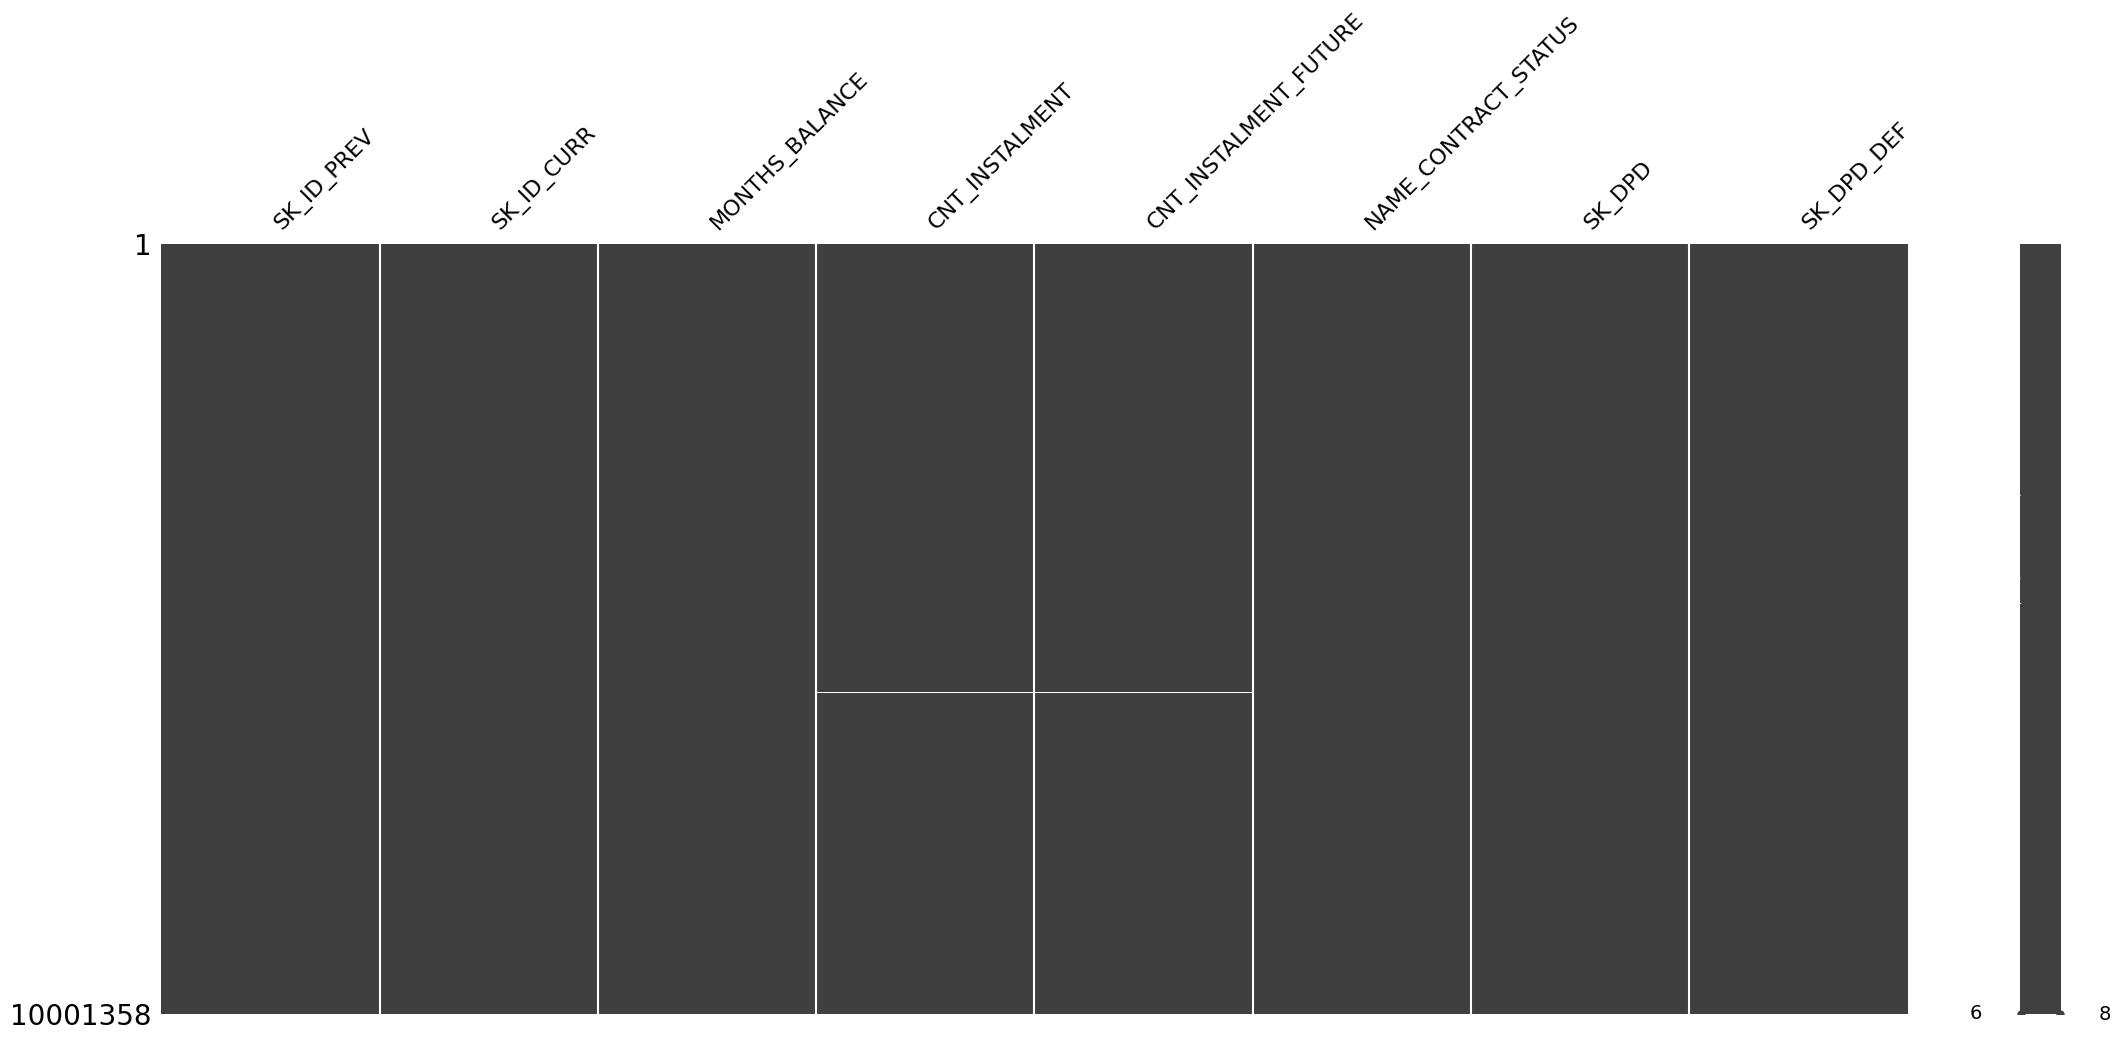

In [15]:
%matplotlib inline
msno.matrix(dfs['POS_CASH'])

In [16]:
dfs['POS_CASH'].dtypes

SK_ID_PREV                 int64
SK_ID_CURR                 int64
MONTHS_BALANCE             int64
CNT_INSTALMENT           float64
CNT_INSTALMENT_FUTURE    float64
NAME_CONTRACT_STATUS      object
SK_DPD                     int64
SK_DPD_DEF                 int64
dtype: object

In [17]:
dfs['POS_CASH'].value_counts()

SK_ID_PREV  SK_ID_CURR  MONTHS_BALANCE  CNT_INSTALMENT  CNT_INSTALMENT_FUTURE  NAME_CONTRACT_STATUS  SK_DPD  SK_DPD_DEF
1000001     158271      -10             12.0            12.0                   Active                0       0             1
2211150     122580      -75             12.0            0.0                    Completed             0       0             1
                        -82             12.0            7.0                    Active                0       0             1
                        -81             12.0            6.0                    Active                0       0             1
                        -80             12.0            5.0                    Active                0       0             1
                                                                                                                          ..
1576022     145134      -27             10.0            10.0                   Active                0       0             1
     

In [18]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['POS_CASH'].nunique().sort_values(ascending=False)
    )

SK_ID_PREV               936325
SK_ID_CURR               337252
SK_DPD                     3400
SK_DPD_DEF                 2307
MONTHS_BALANCE               96
CNT_INSTALMENT_FUTURE        79
CNT_INSTALMENT               73
NAME_CONTRACT_STATUS          9
dtype: int64

In [19]:
for col in ['MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS']:
    print(f'{col}', dfs["POS_CASH"][col].unique(), '\n')

MONTHS_BALANCE [-31 -33 -32 -35 -38 -39 -34 -41 -37 -40 -43 -36 -42 -47 -44 -46 -45 -27
 -25 -24 -30 -28 -26 -29 -48 -15 -19 -22 -14 -18 -16 -21 -17 -20 -23  -1
  -6  -2  -3  -5  -4 -13 -11 -10  -9  -7  -8 -54 -49 -52 -53 -50 -51 -55
 -12 -94 -95 -92 -91 -96 -93 -57 -64 -56 -59 -60 -66 -65 -58 -63 -62 -61
 -87 -86 -88 -89 -90 -72 -74 -73 -82 -78 -81 -75 -77 -80 -76 -79 -69 -70
 -71 -68 -67 -83 -85 -84] 

CNT_INSTALMENT [48. 36. 12. 24. 60. 18.  4. 42. 25. 14. 16. 13.  8. 10. 15. 11. 30. 54.
  6.  9.  5. 17.  3.  2. 20. 32. nan  1.  7. 47. 49. 28. 43. 23. 21. 19.
 39. 37. 35. 27. 22. 41. 31. 61. 26. 34. 29. 44. 55. 33. 66. 46. 59. 38.
 72. 40. 57. 45. 92. 56. 84. 51. 52. 58. 62. 53. 64. 50. 77. 70. 81. 63.
 71. 68.] 

CNT_INSTALMENT_FUTURE [45. 35.  9. 42. 12. 43. 36. 16. 24.  5. 15.  1. 28. 23. 56. 11.  7. 18.
 17. 46. 21.  0.  4. 40. 32. 19.  8. 10.  2. 13. 14.  3.  6. 48. 22. 34.
 47. 30. 29. 41. 54. 20. 37. 31. 27. 26. nan 25. 38. 33. 39. 53. 58. 50.
 51. 52. 55. 59. 57. 60. 49. 44.

In [20]:
dfs['POS_CASH'].describe().round(2)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
count,10001358.00,10001358.00,10001358.00,9975287.00,9975271.00,10001358.00,10001358.00
mean,1903216.60,278403.86,-35.01,17.09,10.48,11.61,0.65
std,535846.53,102763.75,26.07,12.00,11.11,132.71,32.76
min,1000001.00,100001.00,-96.00,1.00,0.00,0.00,0.00
25%,1434405.00,189550.00,-54.00,10.00,3.00,0.00,0.00
50%,1896565.00,278654.00,-28.00,12.00,7.00,0.00,0.00
75%,2368963.00,367429.00,-13.00,24.00,14.00,0.00,0.00
max,2843499.00,456255.00,-1.00,92.00,85.00,4231.00,3595.00


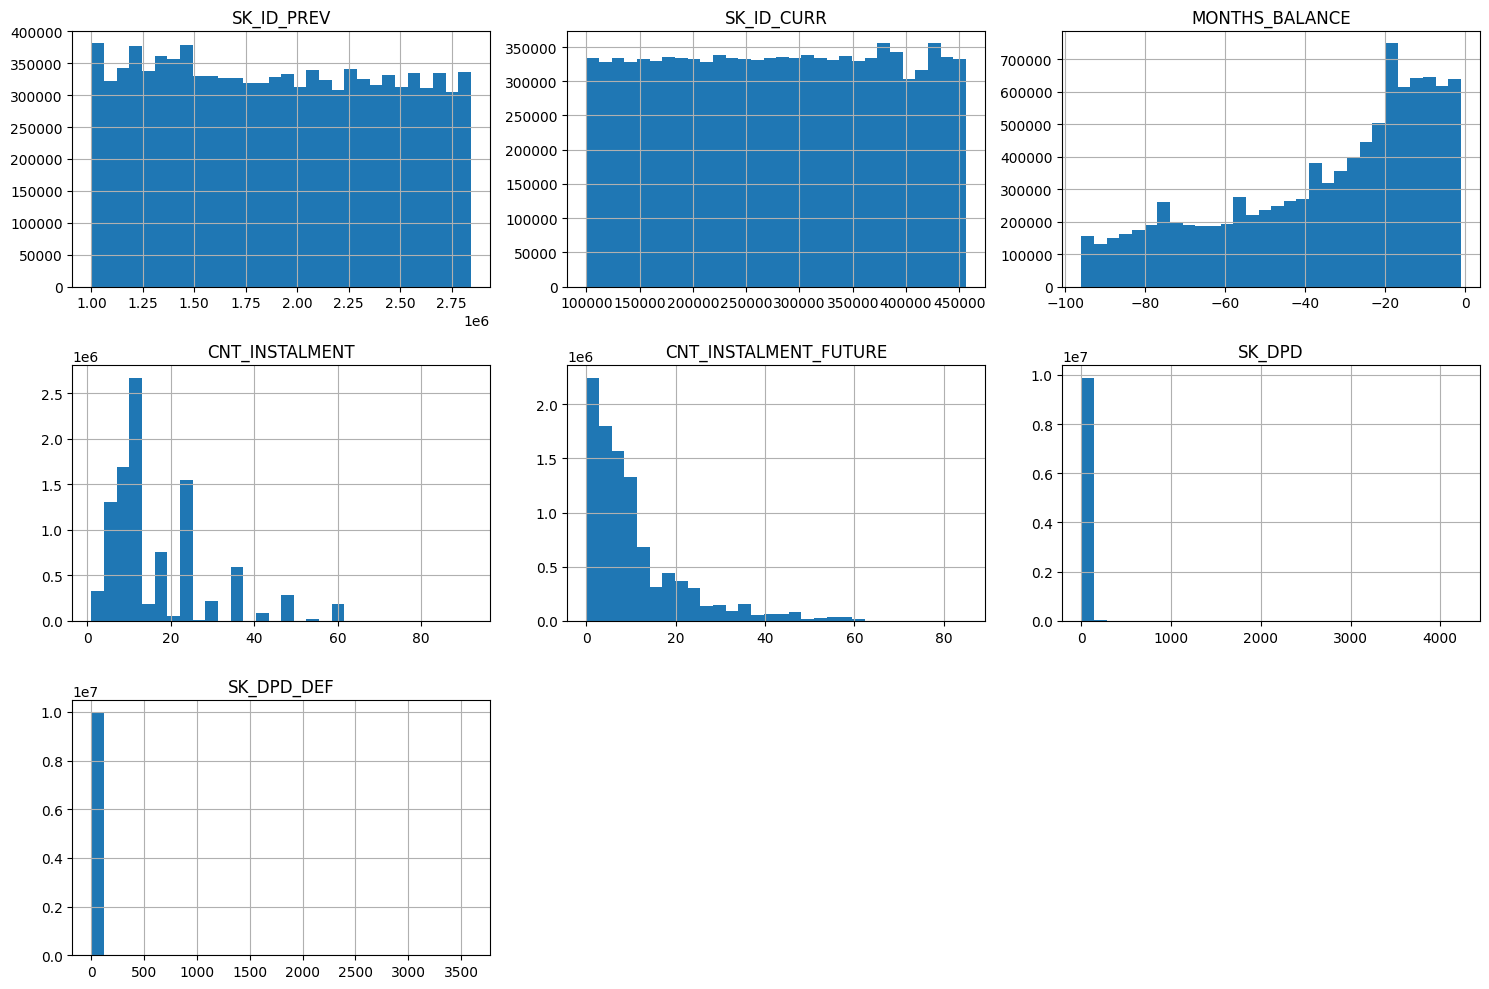

In [21]:
import matplotlib.pyplot as plt

dfs["POS_CASH"].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [22]:
dfs["POS_CASH"]["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

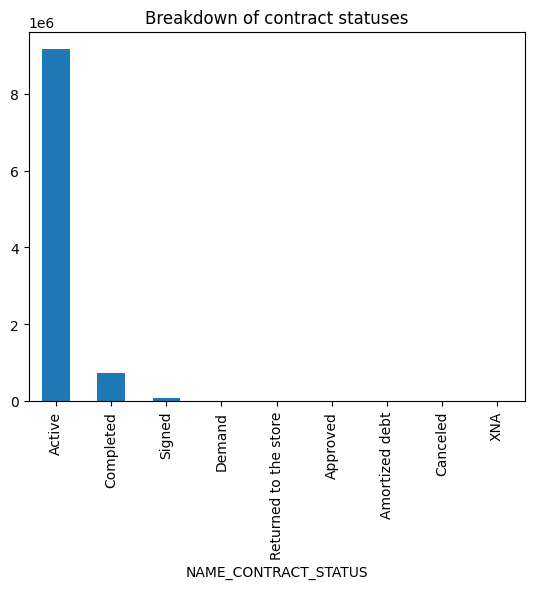

In [23]:
dfs["POS_CASH"]["NAME_CONTRACT_STATUS"].value_counts().plot(kind="bar")
plt.title("Breakdown of contract statuses")
plt.show()

##### 3. application_train table

In [24]:
with pd.option_context('display.max_columns', None):
    display(dfs['application_train'])

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [25]:
dfs['application_train'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [26]:
with pd.option_context('display.max_rows', 130):
    display(
        (dfs['application_train'].isnull().sum() / len(dfs['application_train']) * 100)
        .round(2)
        .sort_values(ascending=False)
    )

COMMONAREA_MEDI                 69.87
COMMONAREA_AVG                  69.87
COMMONAREA_MODE                 69.87
NONLIVINGAPARTMENTS_MODE        69.43
NONLIVINGAPARTMENTS_AVG         69.43
NONLIVINGAPARTMENTS_MEDI        69.43
FONDKAPREMONT_MODE              68.39
LIVINGAPARTMENTS_MODE           68.35
LIVINGAPARTMENTS_AVG            68.35
LIVINGAPARTMENTS_MEDI           68.35
FLOORSMIN_AVG                   67.85
FLOORSMIN_MODE                  67.85
FLOORSMIN_MEDI                  67.85
YEARS_BUILD_MEDI                66.50
YEARS_BUILD_MODE                66.50
YEARS_BUILD_AVG                 66.50
OWN_CAR_AGE                     65.99
LANDAREA_MEDI                   59.38
LANDAREA_MODE                   59.38
LANDAREA_AVG                    59.38
BASEMENTAREA_MEDI               58.52
BASEMENTAREA_AVG                58.52
BASEMENTAREA_MODE               58.52
EXT_SOURCE_1                    56.38
NONLIVINGAREA_MODE              55.18
NONLIVINGAREA_AVG               55.18
NONLIVINGARE

<Axes: >

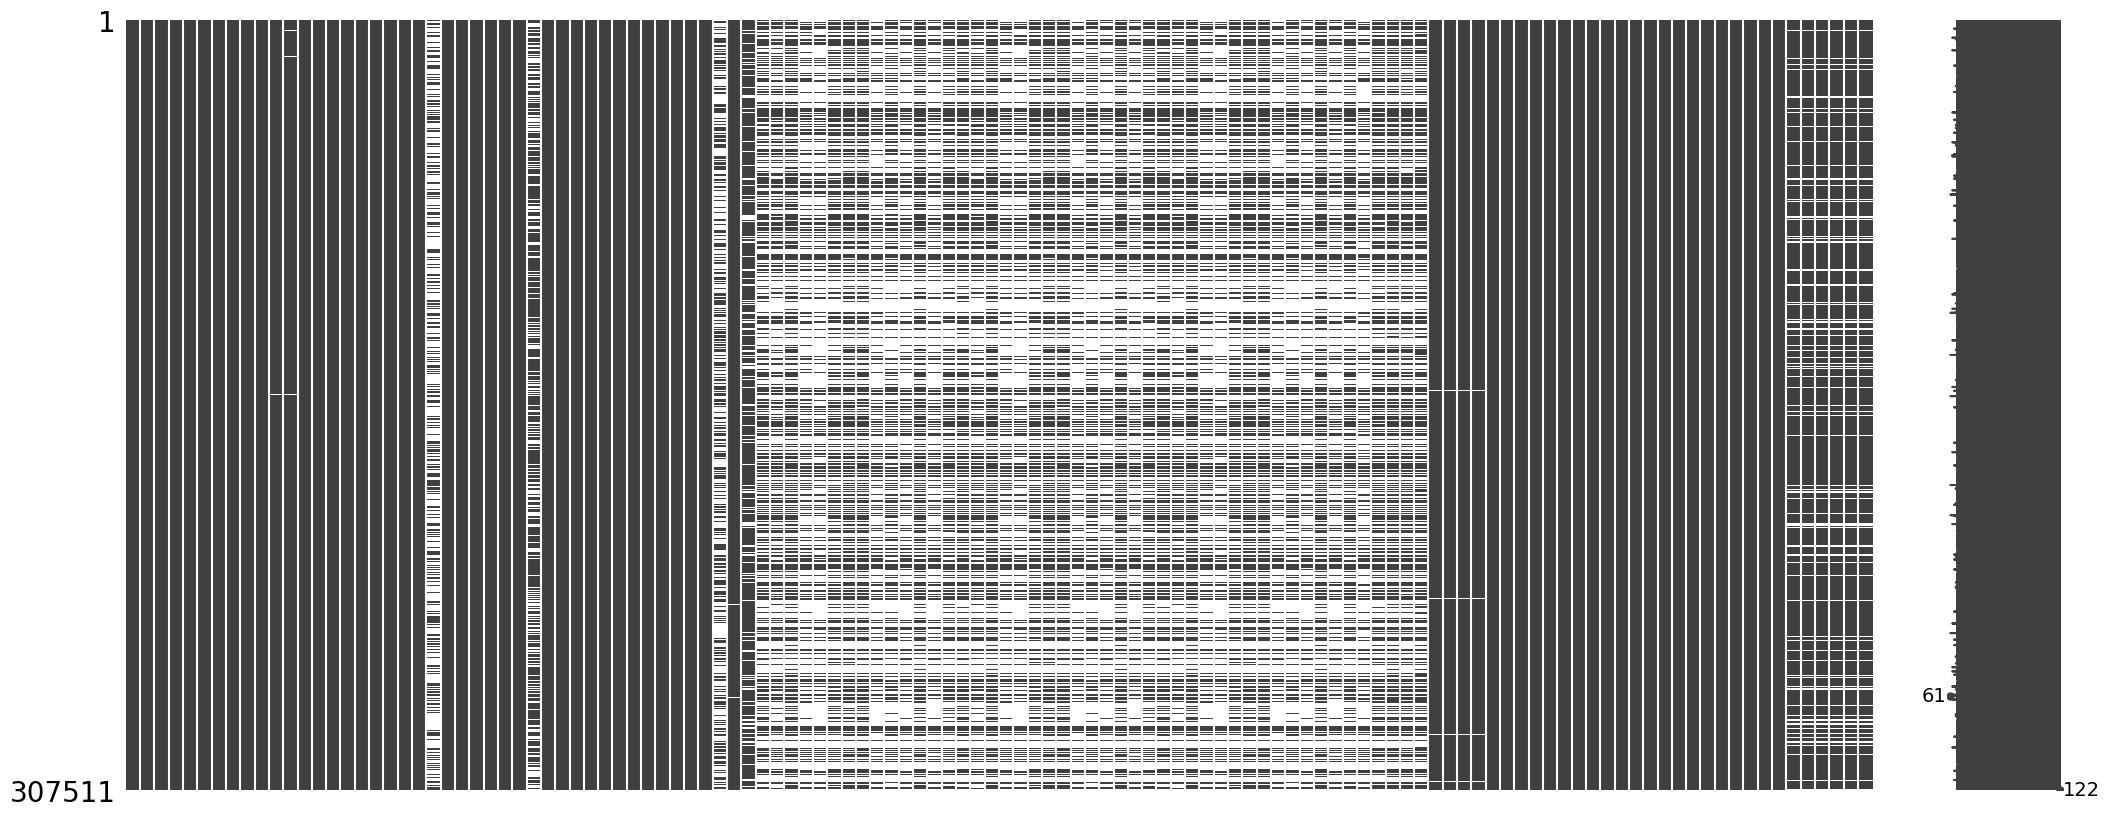

In [27]:
%matplotlib inline
msno.matrix(dfs['application_train'])

<Axes: >

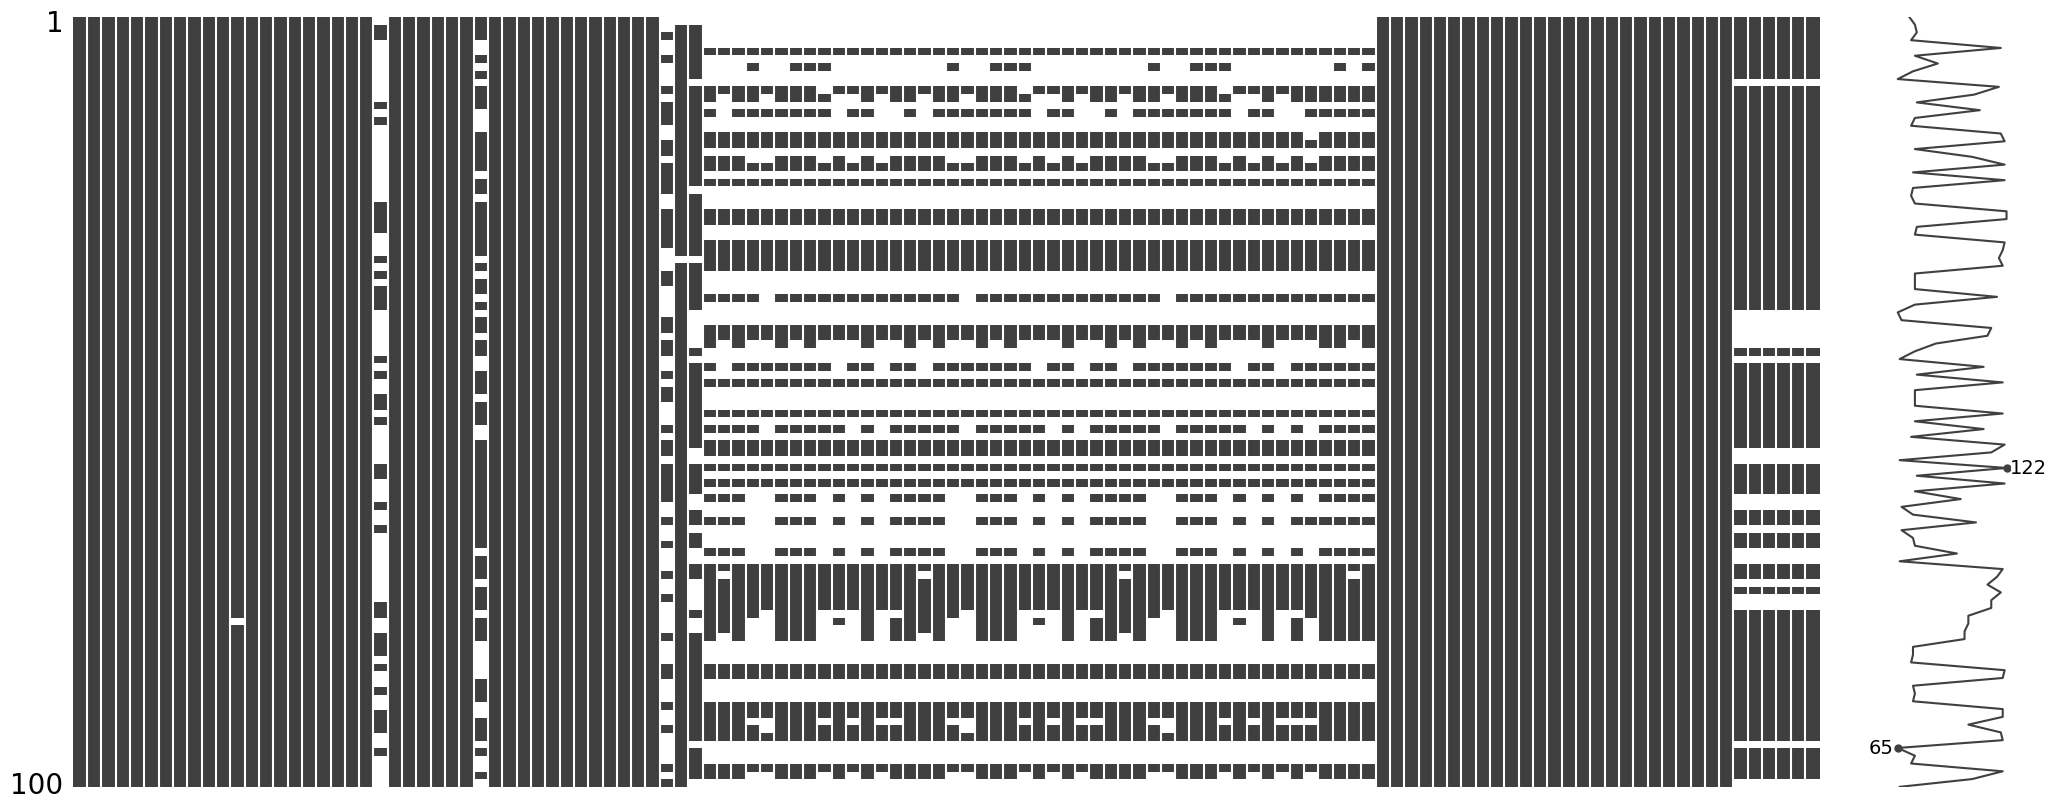

In [28]:
%matplotlib inline
msno.matrix(dfs['application_train'].sample(100))

<Axes: >

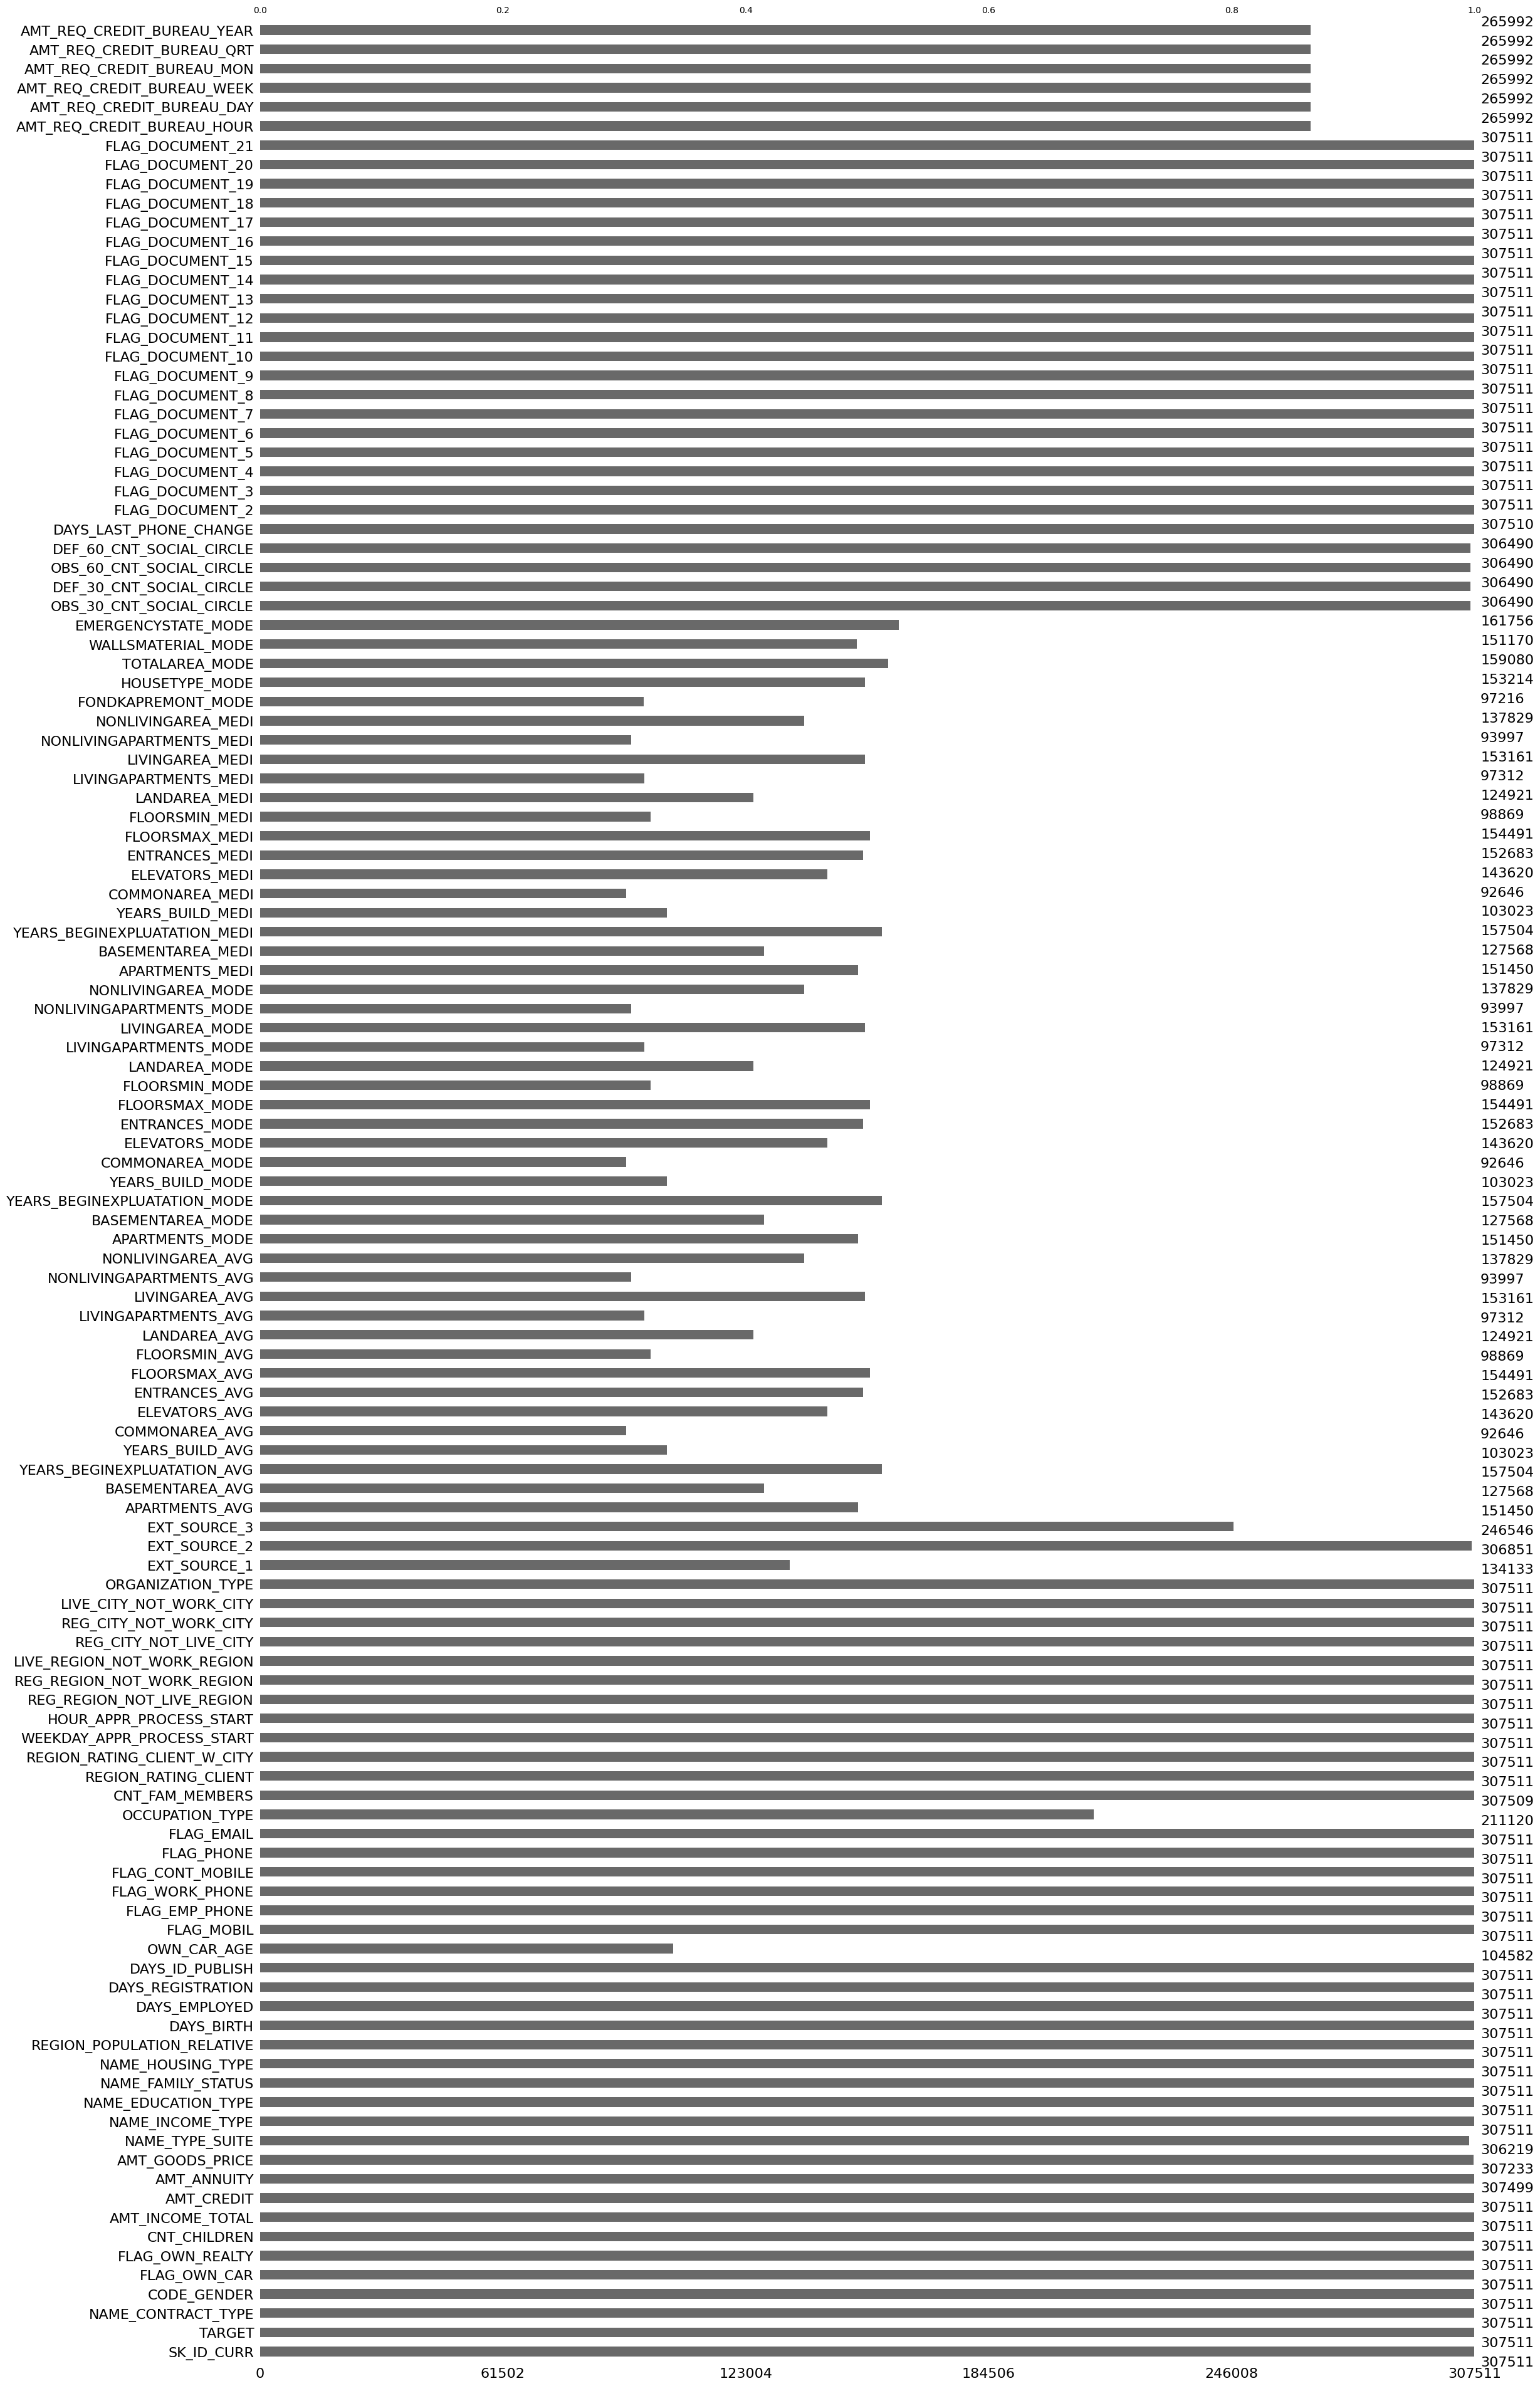

In [29]:
msno.bar(dfs['application_train'])

In [30]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_train'].nunique().sort_values(ascending=False)
    )

SK_ID_CURR                      307511
EXT_SOURCE_2                    119831
EXT_SOURCE_1                    114584
DAYS_BIRTH                       17460
DAYS_REGISTRATION                15688
AMT_ANNUITY                      13672
DAYS_EMPLOYED                    12574
DAYS_ID_PUBLISH                   6168
AMT_CREDIT                        5603
LIVINGAREA_MODE                   5301
LIVINGAREA_MEDI                   5281
LIVINGAREA_AVG                    5199
TOTALAREA_MODE                    5116
BASEMENTAREA_MODE                 3841
BASEMENTAREA_AVG                  3780
DAYS_LAST_PHONE_CHANGE            3773
BASEMENTAREA_MEDI                 3772
LANDAREA_MODE                     3563
LANDAREA_MEDI                     3560
LANDAREA_AVG                      3527
NONLIVINGAREA_MODE                3327
NONLIVINGAREA_MEDI                3323
NONLIVINGAREA_AVG                 3290
COMMONAREA_MEDI                   3202
COMMONAREA_AVG                    3181
COMMONAREA_MODE          

In [31]:
for col in dfs["application_train"].columns:
    n = dfs["application_train"][col].nunique()
    if (n <= 30 and n > 2): # Only columns with fewer than 30 unique values, but more than 2, are displayed (this excludes flags and other binary columns)
        print(f"{col} ({n} values) :", dfs["application_train"][col].unique(), "\n")

CODE_GENDER (3 values) : ['M' 'F' 'XNA'] 

CNT_CHILDREN (15 values) : [ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14] 

NAME_TYPE_SUITE (7 values) : ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people'] 

NAME_INCOME_TYPE (8 values) : ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave'] 

NAME_EDUCATION_TYPE (5 values) : ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree'] 

NAME_FAMILY_STATUS (6 values) : ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown'] 

NAME_HOUSING_TYPE (6 values) : ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment'] 

OCCUPATION_TYPE (18 values) : ['Laborers' 'Core staff' 'Accountants' 'Managers' nan 'Drivers'
 'Sales staff' 'Cleaning staff' 'Cooking staff' 'Private service staff'
 'Medicine staff' 'Secu

In [32]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_train'].value_counts()
    )

SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  NAME_TYPE_SUITE  NAME_INCOME_TYPE      NAME_EDUCATION_TYPE            NAME_FAMILY_STATUS    NAME_HOUSING_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL  OCCUPATION_TYPE        CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY  WEEKDAY_APPR_PROCESS_START  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY  ORGANIZATION_TYPE       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  FLOORSMAX_AVG  FLOORSMIN_AVG  LANDAREA_AVG  LI

In [33]:
len(dfs["application_train"].select_dtypes(include="number").columns)

106

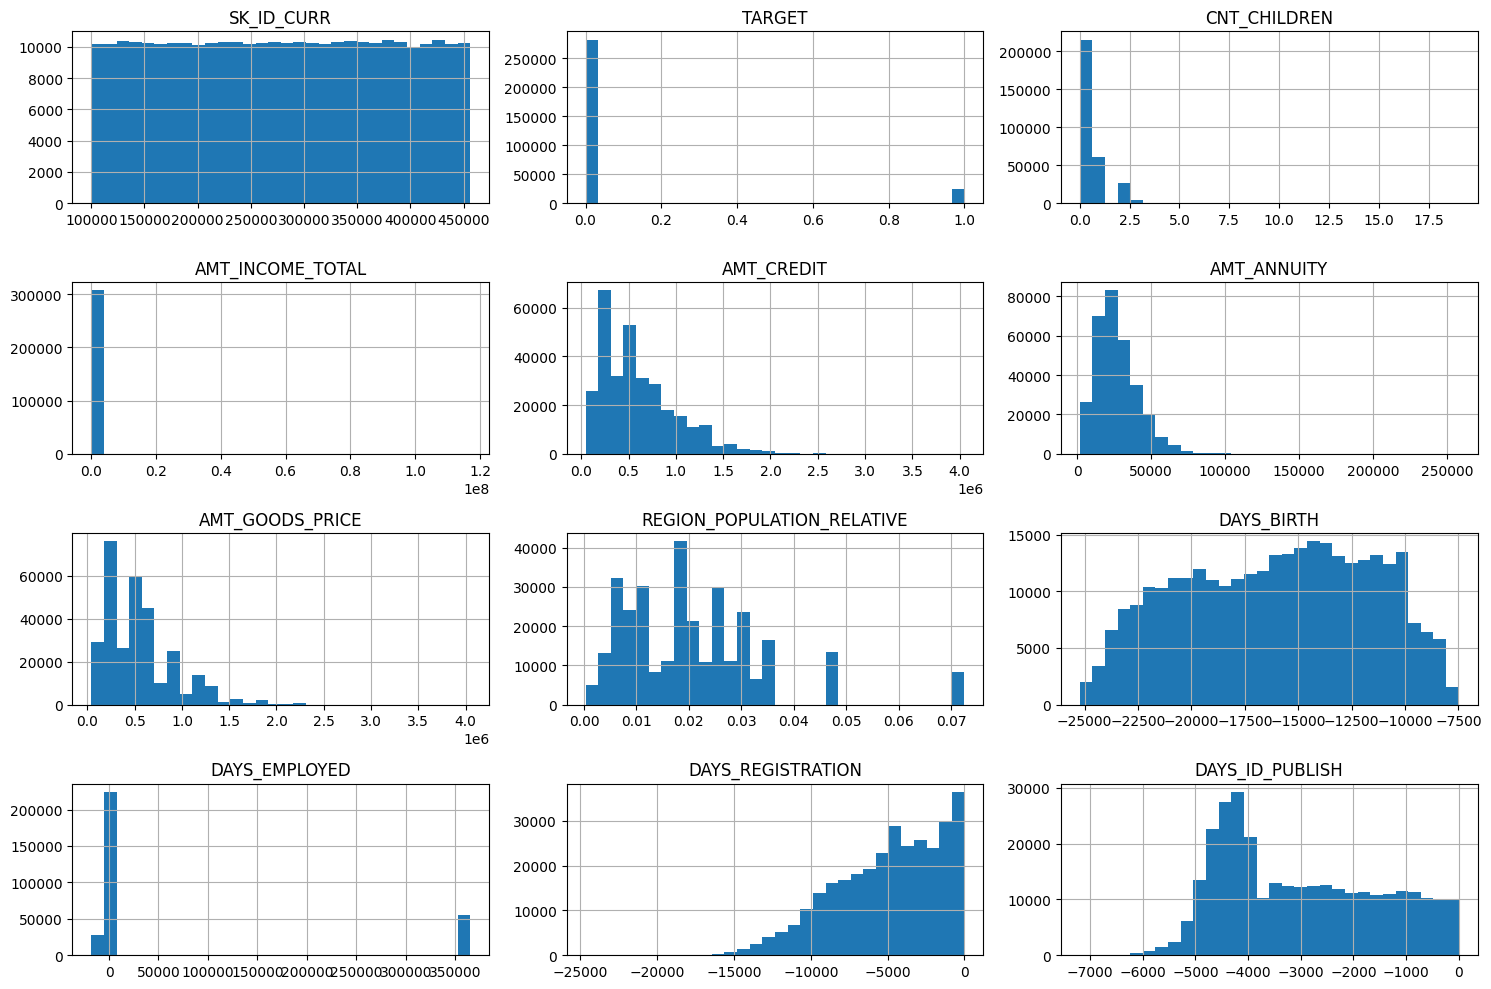

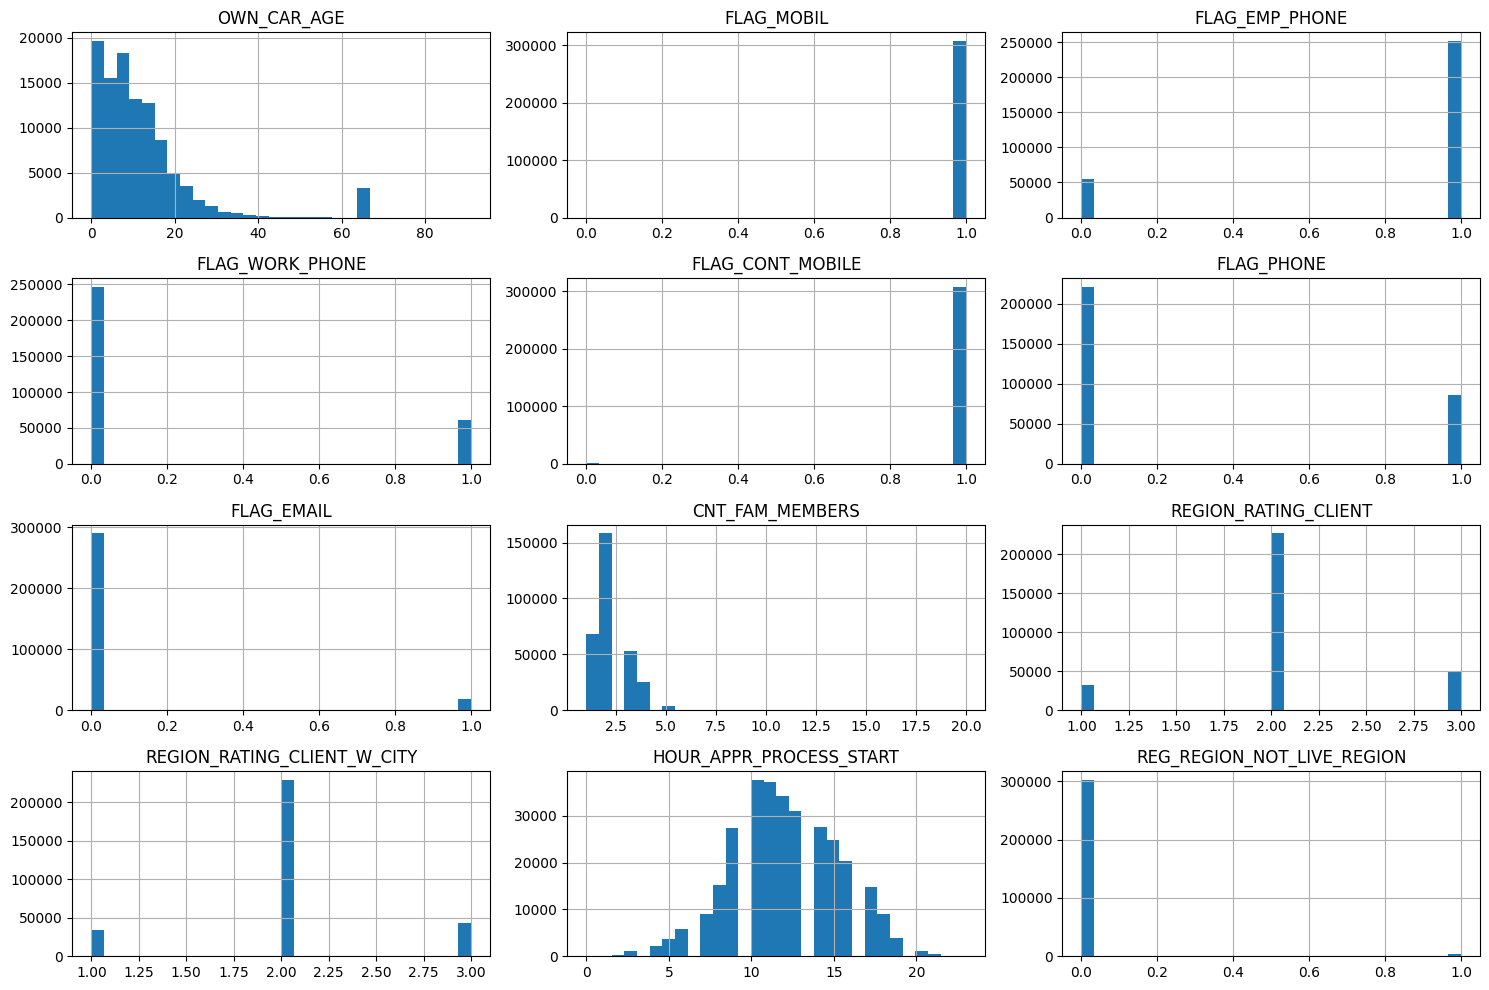

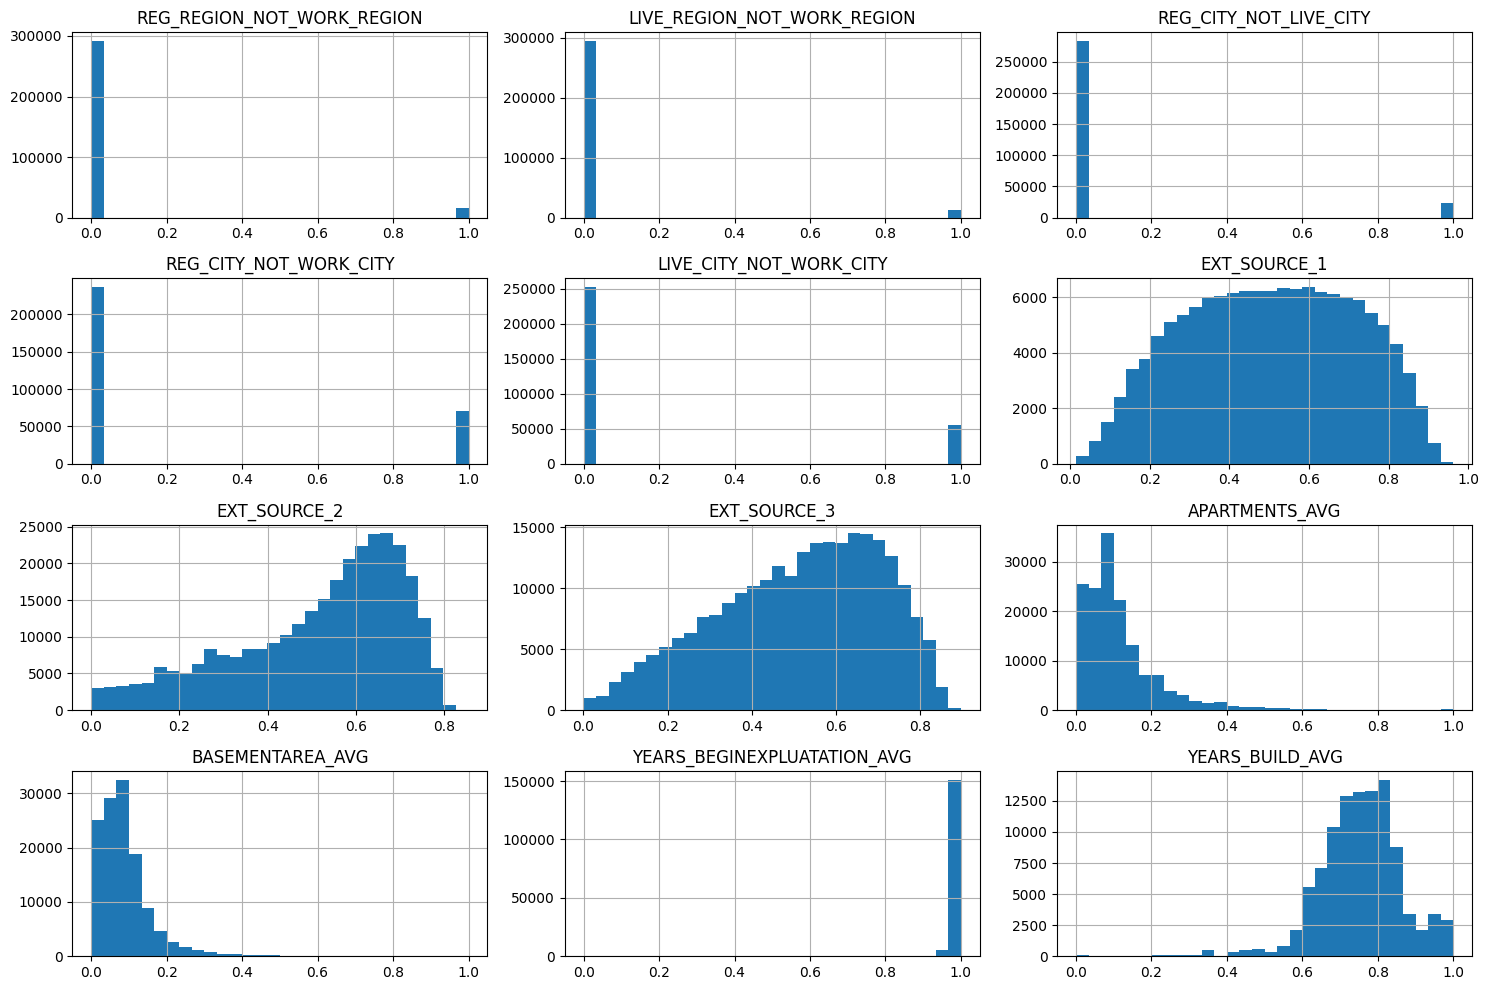

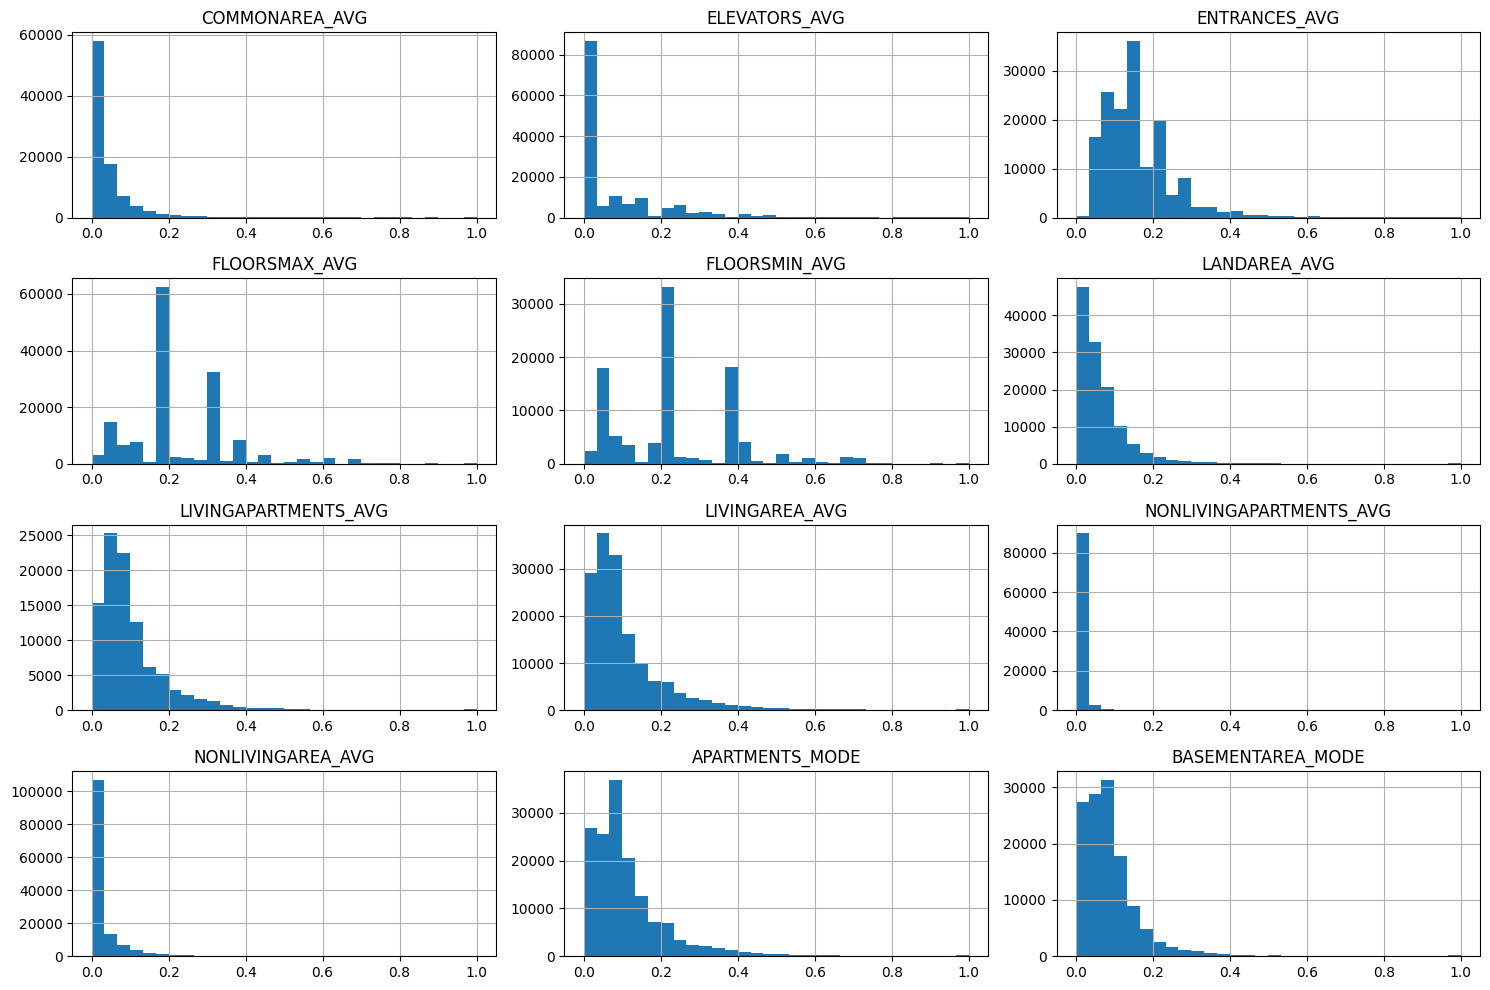

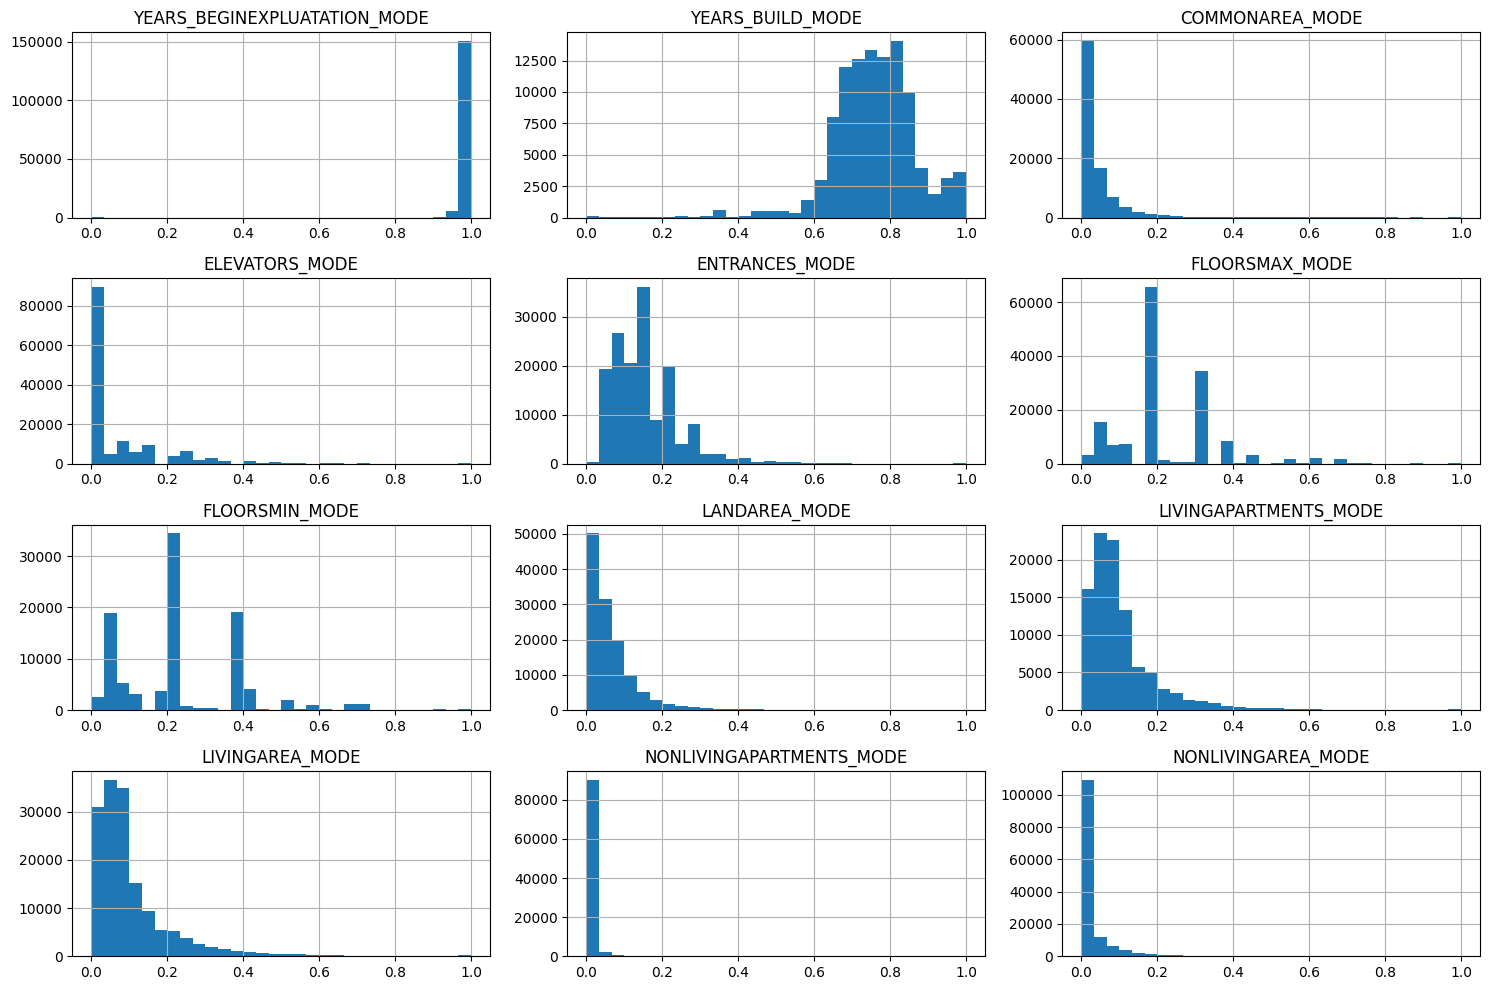

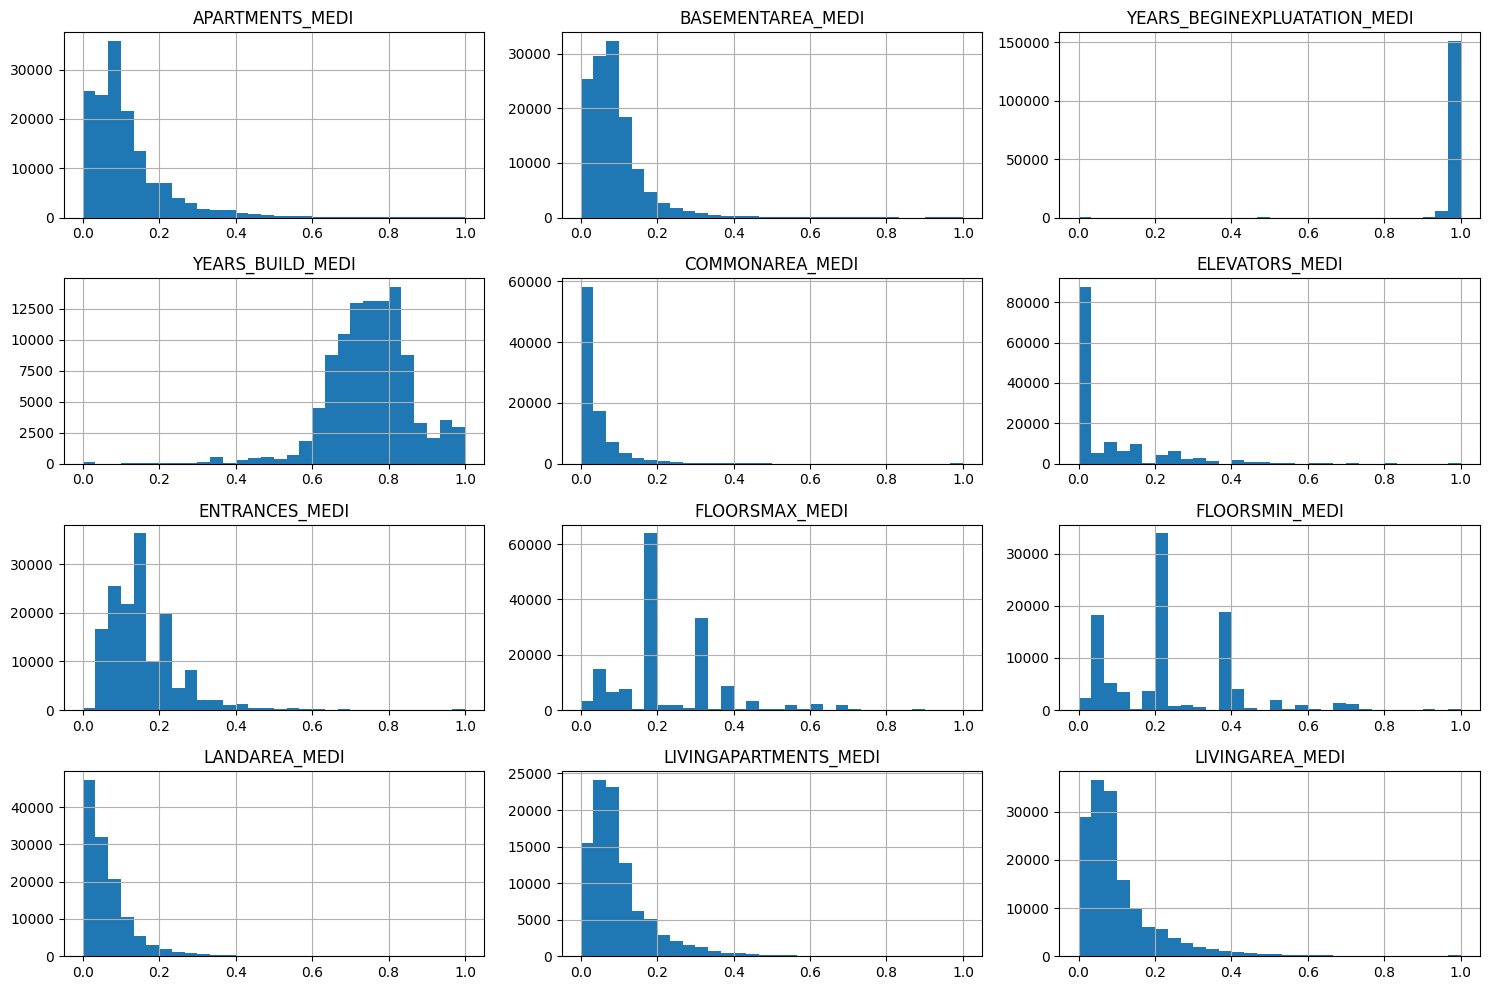

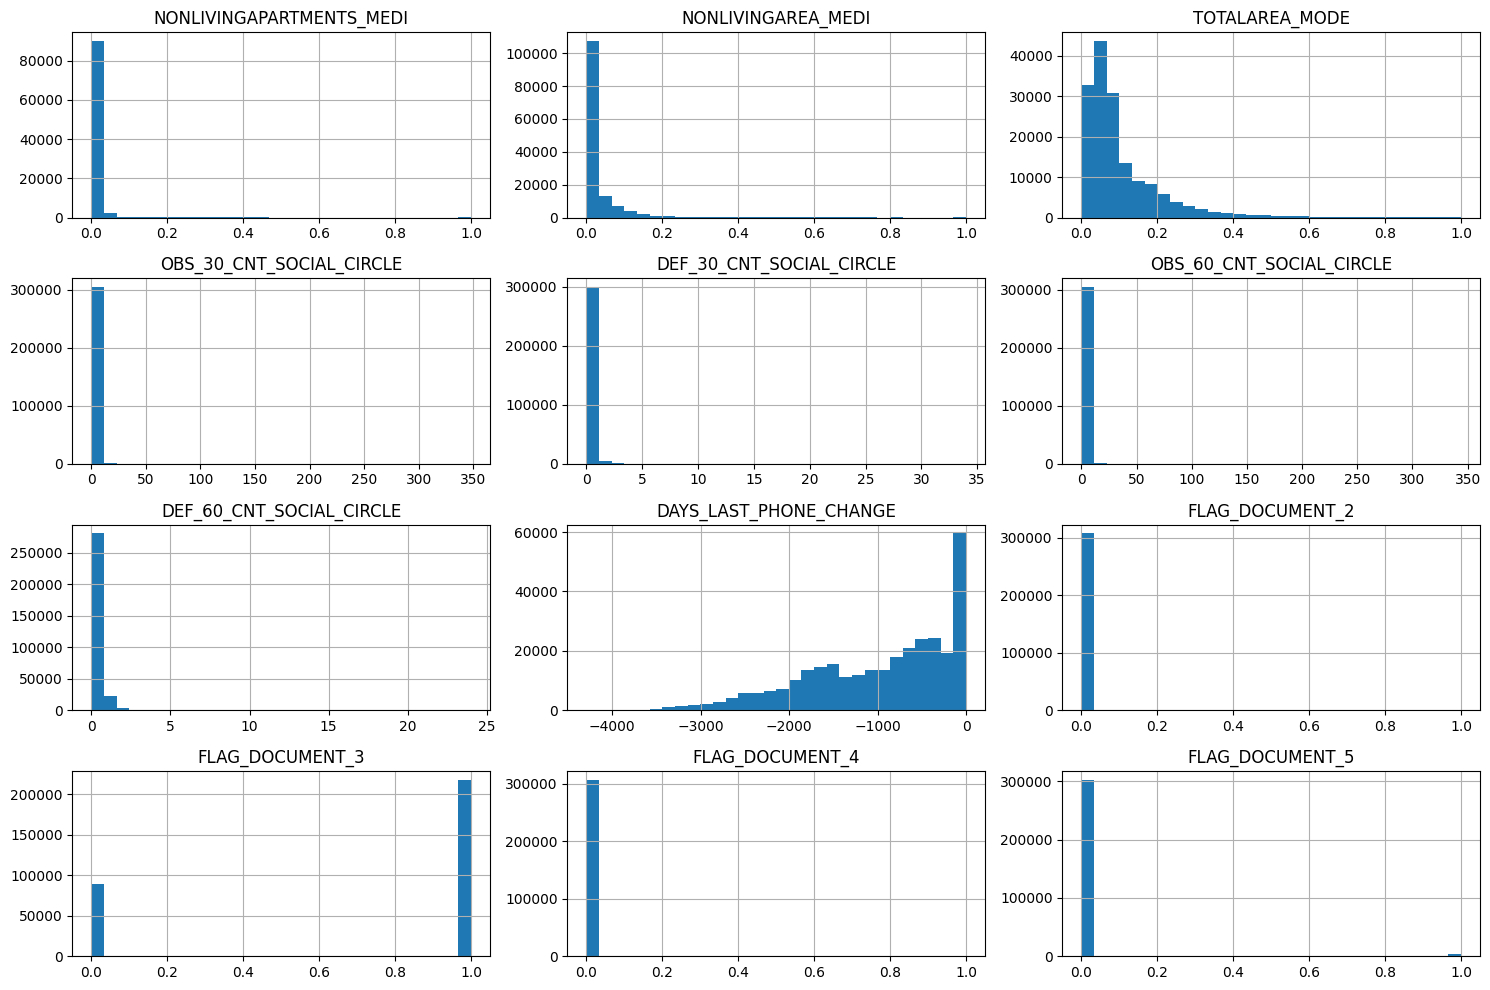

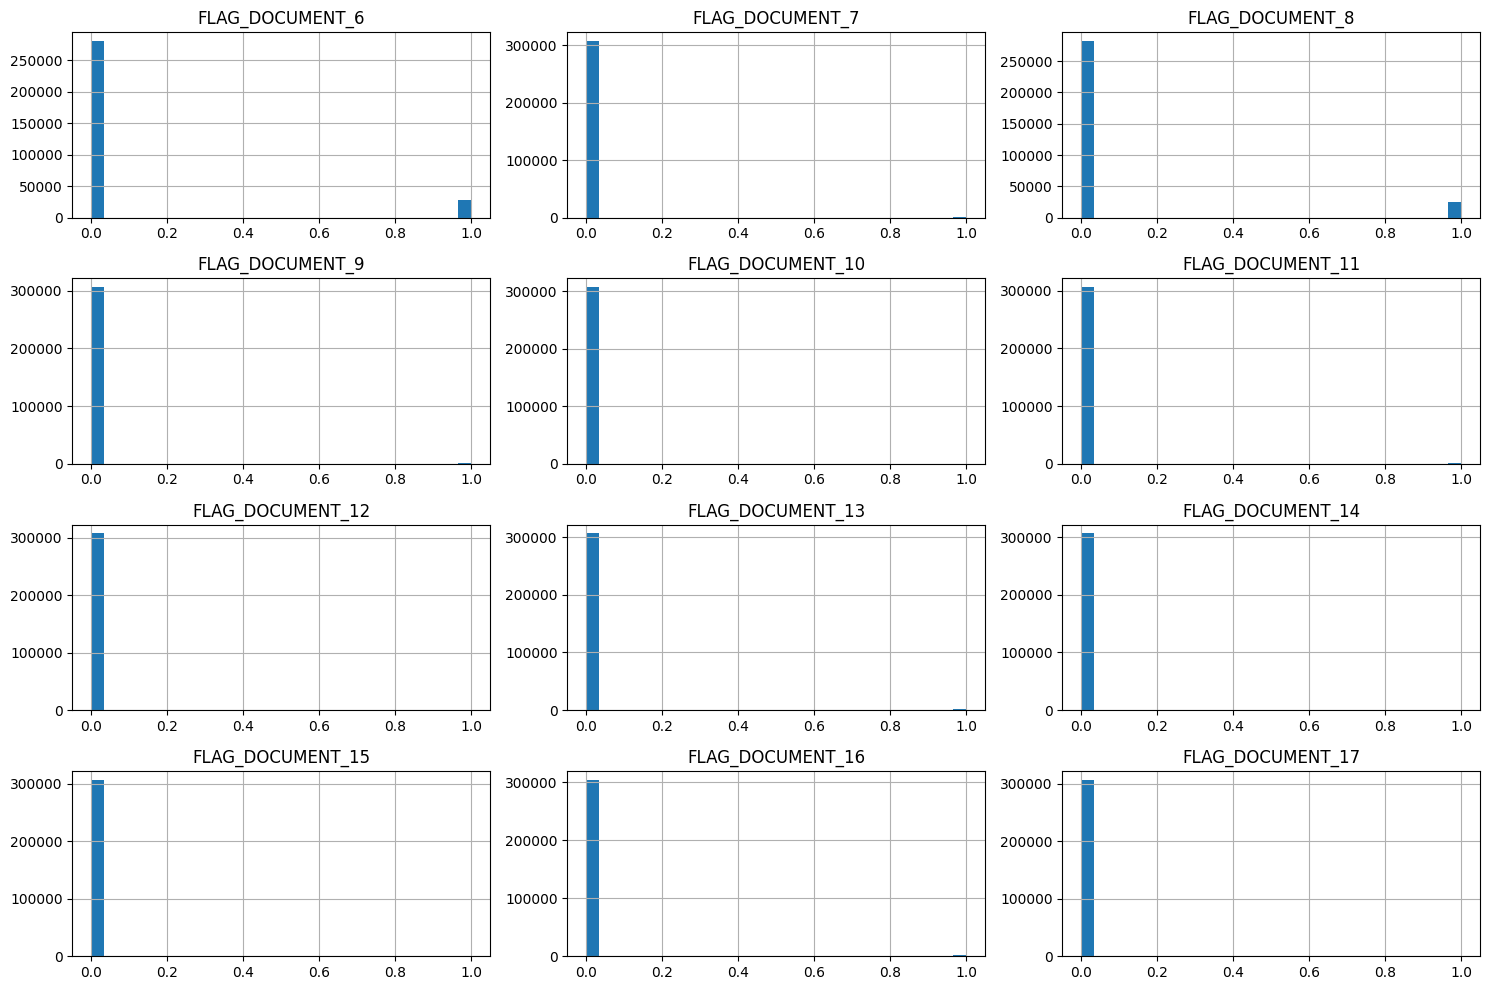

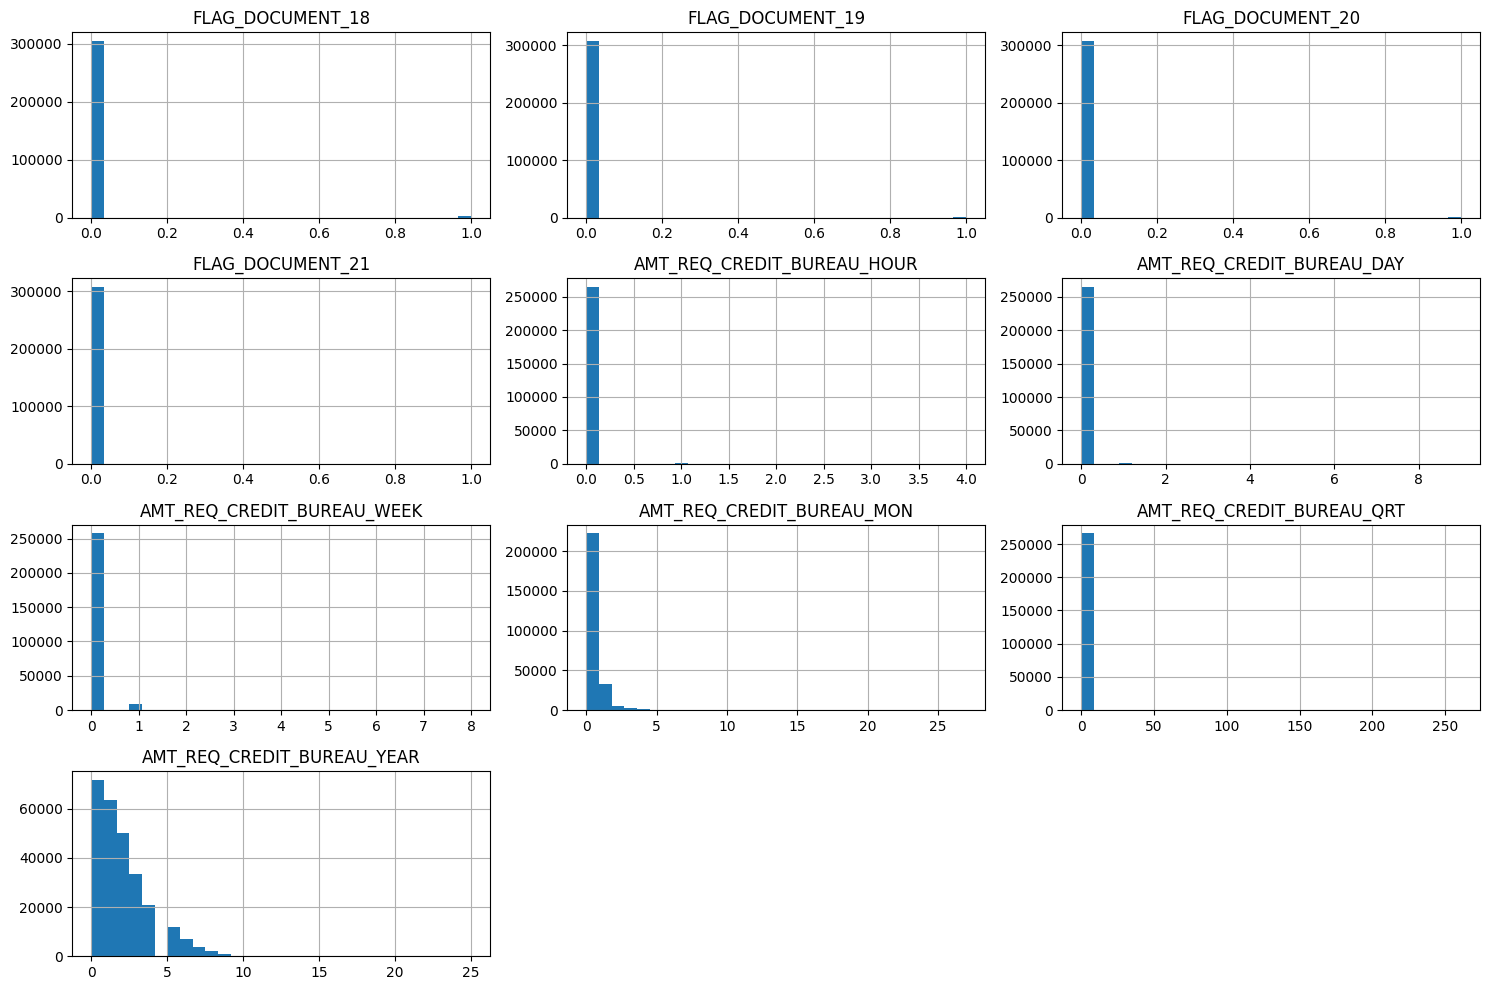

In [34]:
numeric_cols = dfs["application_train"].select_dtypes(include="number").columns
chunk_size = 12

for i in range(0, len(numeric_cols), chunk_size):
    cols_chunk = numeric_cols[i:i + chunk_size]
    dfs["application_train"][cols_chunk].hist(figsize=(15, 10), bins=30)
    plt.tight_layout()
    plt.show()

In [35]:
dfs["application_train"][[
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH"
]]

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH
0,-9461,-637,-3648.0,-2120
1,-16765,-1188,-1186.0,-291
2,-19046,-225,-4260.0,-2531
3,-19005,-3039,-9833.0,-2437
4,-19932,-3038,-4311.0,-3458
...,...,...,...,...
307506,-9327,-236,-8456.0,-1982
307507,-20775,365243,-4388.0,-4090
307508,-14966,-7921,-6737.0,-5150
307509,-11961,-4786,-2562.0,-931


In [36]:
dfs["application_train"][[
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH"
]].describe()

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH
count,307511.000000,307511.000000,307511.000000,307511.000000
mean,-16036.995067,63815.045904,-4986.120328,-2994.202373
std,4363.988632,141275.766519,3522.886321,1509.450419
min,-25229.000000,-17912.000000,-24672.000000,-7197.000000
25%,-19682.000000,-2760.000000,-7479.500000,-4299.000000
50%,-15750.000000,-1213.000000,-4504.000000,-3254.000000
75%,-12413.000000,-289.000000,-2010.000000,-1720.000000
max,-7489.000000,365243.000000,0.000000,0.000000


In [37]:
days_cols = [c for c in [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH"
]]
(dfs['application_train'][days_cols].mask(dfs['application_train'][days_cols] > 0) / -365.25).describe().round(1)

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH
count,307511.0,252137.0,307511.0,307511.0
mean,43.9,6.5,13.7,8.2
std,11.9,6.4,9.6,4.1
min,20.5,-0.0,-0.0,-0.0
25%,34.0,2.1,5.5,4.7
50%,43.1,4.5,12.3,8.9
75%,53.9,8.7,20.5,11.8
max,69.1,49.0,67.5,19.7


In [38]:
for c in ['DAYS_BIRTH', 'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    print(c, (dfs["application_train"][c] == 0).sum())

DAYS_BIRTH 0
DAYS_EMPLOYED 2
DAYS_REGISTRATION 80
DAYS_ID_PUBLISH 16
DAYS_LAST_PHONE_CHANGE 37672


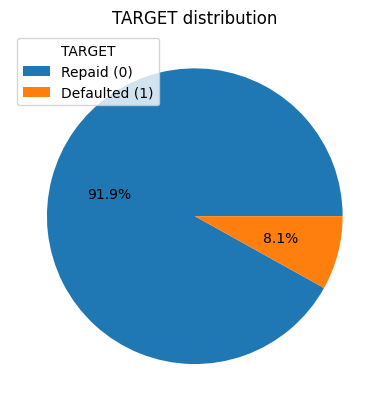

In [39]:
counts = dfs['application_train']['TARGET'].value_counts()

plt.pie(counts, autopct="%1.1f%%")
plt.legend(labels=["Repaid (0)", "Defaulted (1)"], title="TARGET", loc="best")
plt.title("TARGET distribution")
plt.show()

In [40]:
with pd.option_context('display.max_columns', None):
    display(dfs['application_test'])

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Marr

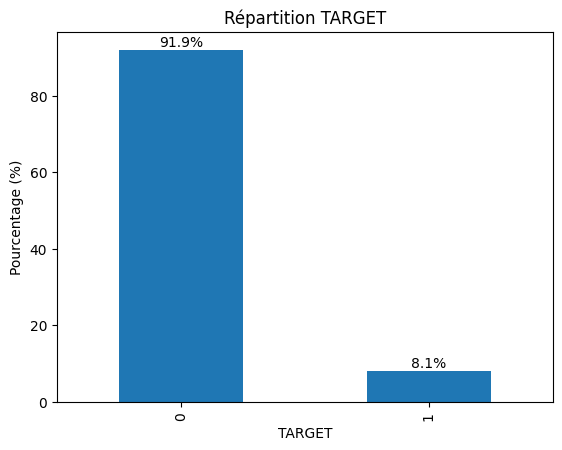

In [41]:
counts = dfs['application_train']['TARGET'].value_counts(normalize=True) * 100
counts.plot(kind='bar')
plt.ylabel("Pourcentage (%)")
plt.title("Répartition TARGET")
for i, v in enumerate(counts):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

The defaulted class, which is what we want to detect, is much less frequent than the repaid class. This is the classical **class imbalance problem**, which we will address using *stratify* in the train/test split, along with a few other dedicated methods.

##### 4. application_test table

In [42]:
dfs['application_test']

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,1.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0


In [43]:
dfs['application_test'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 int64  
 18   DAYS

In [44]:
cols_train = set(dfs['application_train'].columns)
cols_test = set(dfs['application_test'].columns)
cols_train - cols_test

{'TARGET'}

This is simply to check that the columns are identical between the `application_train` and `application_test` tables (which is confirmed, with the exception of the ‘Target’ column, which is present in `application_train`). 

In [45]:
with pd.option_context('display.max_rows', 130):
    display(
        (dfs['application_test'].isnull().sum() / len(dfs['application_test']) * 100)
        .round(2)
        .sort_values(ascending=False)
    )

COMMONAREA_AVG                  68.72
COMMONAREA_MODE                 68.72
COMMONAREA_MEDI                 68.72
NONLIVINGAPARTMENTS_AVG         68.41
NONLIVINGAPARTMENTS_MODE        68.41
NONLIVINGAPARTMENTS_MEDI        68.41
FONDKAPREMONT_MODE              67.28
LIVINGAPARTMENTS_AVG            67.25
LIVINGAPARTMENTS_MODE           67.25
LIVINGAPARTMENTS_MEDI           67.25
FLOORSMIN_MEDI                  66.61
FLOORSMIN_AVG                   66.61
FLOORSMIN_MODE                  66.61
OWN_CAR_AGE                     66.29
YEARS_BUILD_AVG                 65.28
YEARS_BUILD_MEDI                65.28
YEARS_BUILD_MODE                65.28
LANDAREA_MEDI                   57.96
LANDAREA_AVG                    57.96
LANDAREA_MODE                   57.96
BASEMENTAREA_MEDI               56.71
BASEMENTAREA_AVG                56.71
BASEMENTAREA_MODE               56.71
NONLIVINGAREA_AVG               53.51
NONLIVINGAREA_MODE              53.51
NONLIVINGAREA_MEDI              53.51
ELEVATORS_MO

<Axes: >

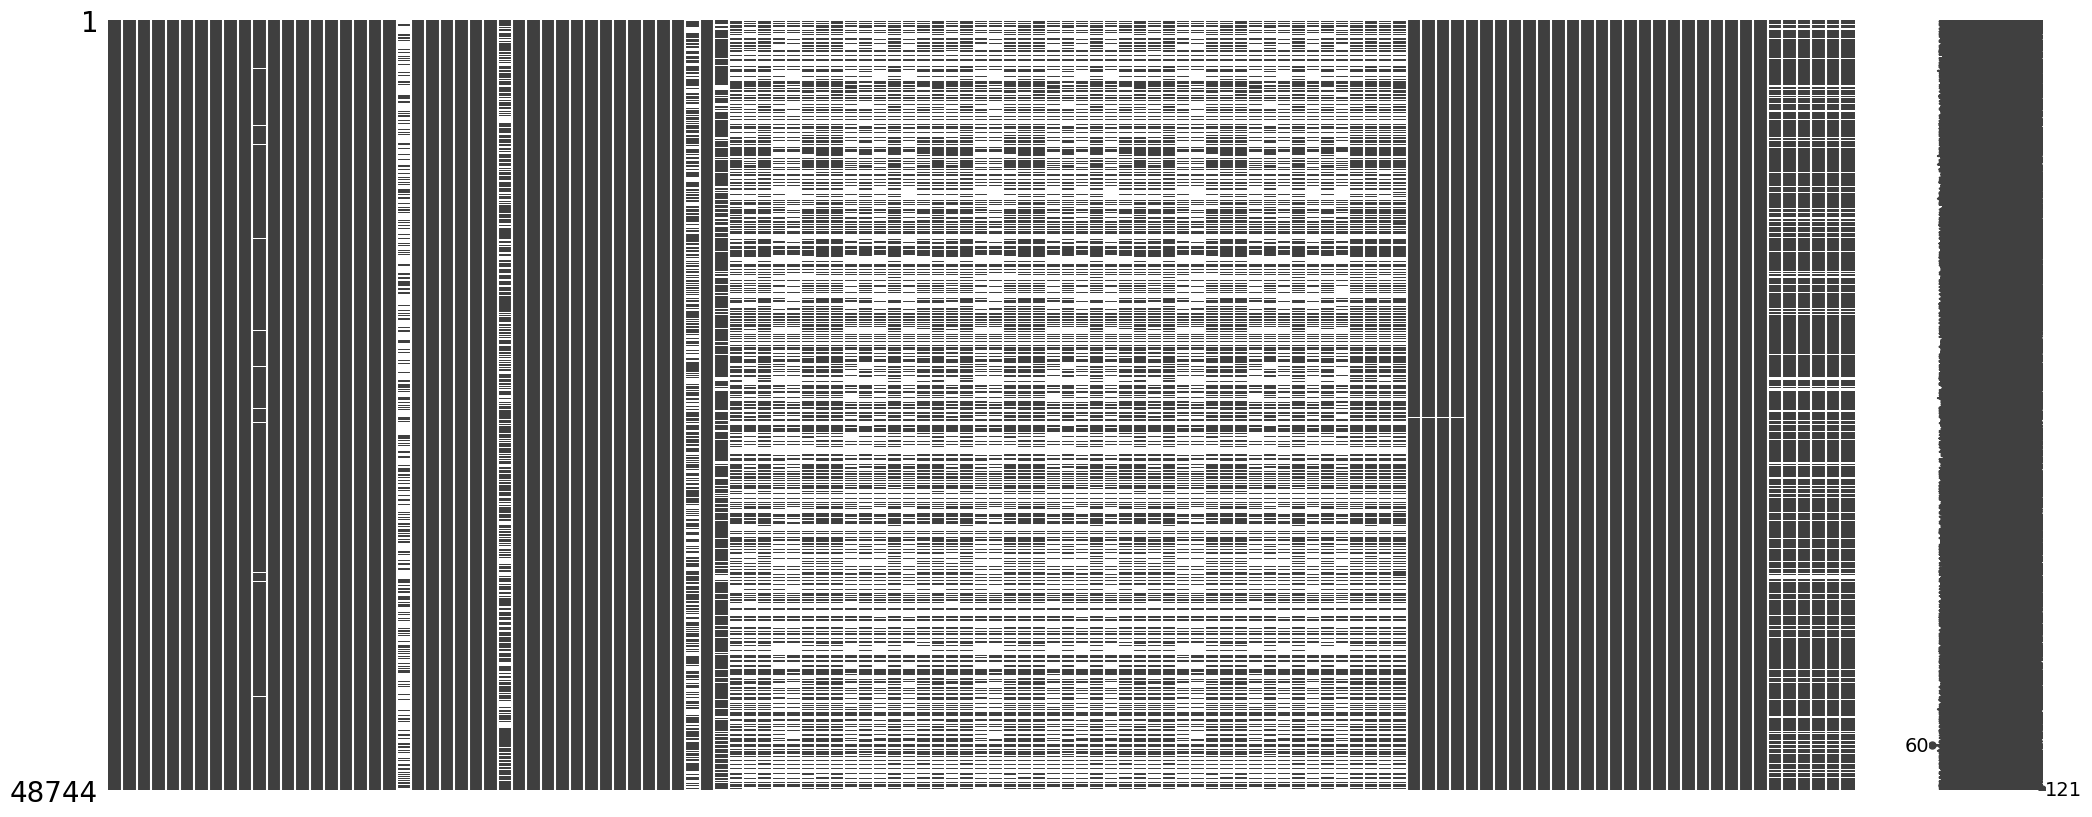

In [46]:
%matplotlib inline
msno.matrix(dfs['application_test'])

<Axes: >

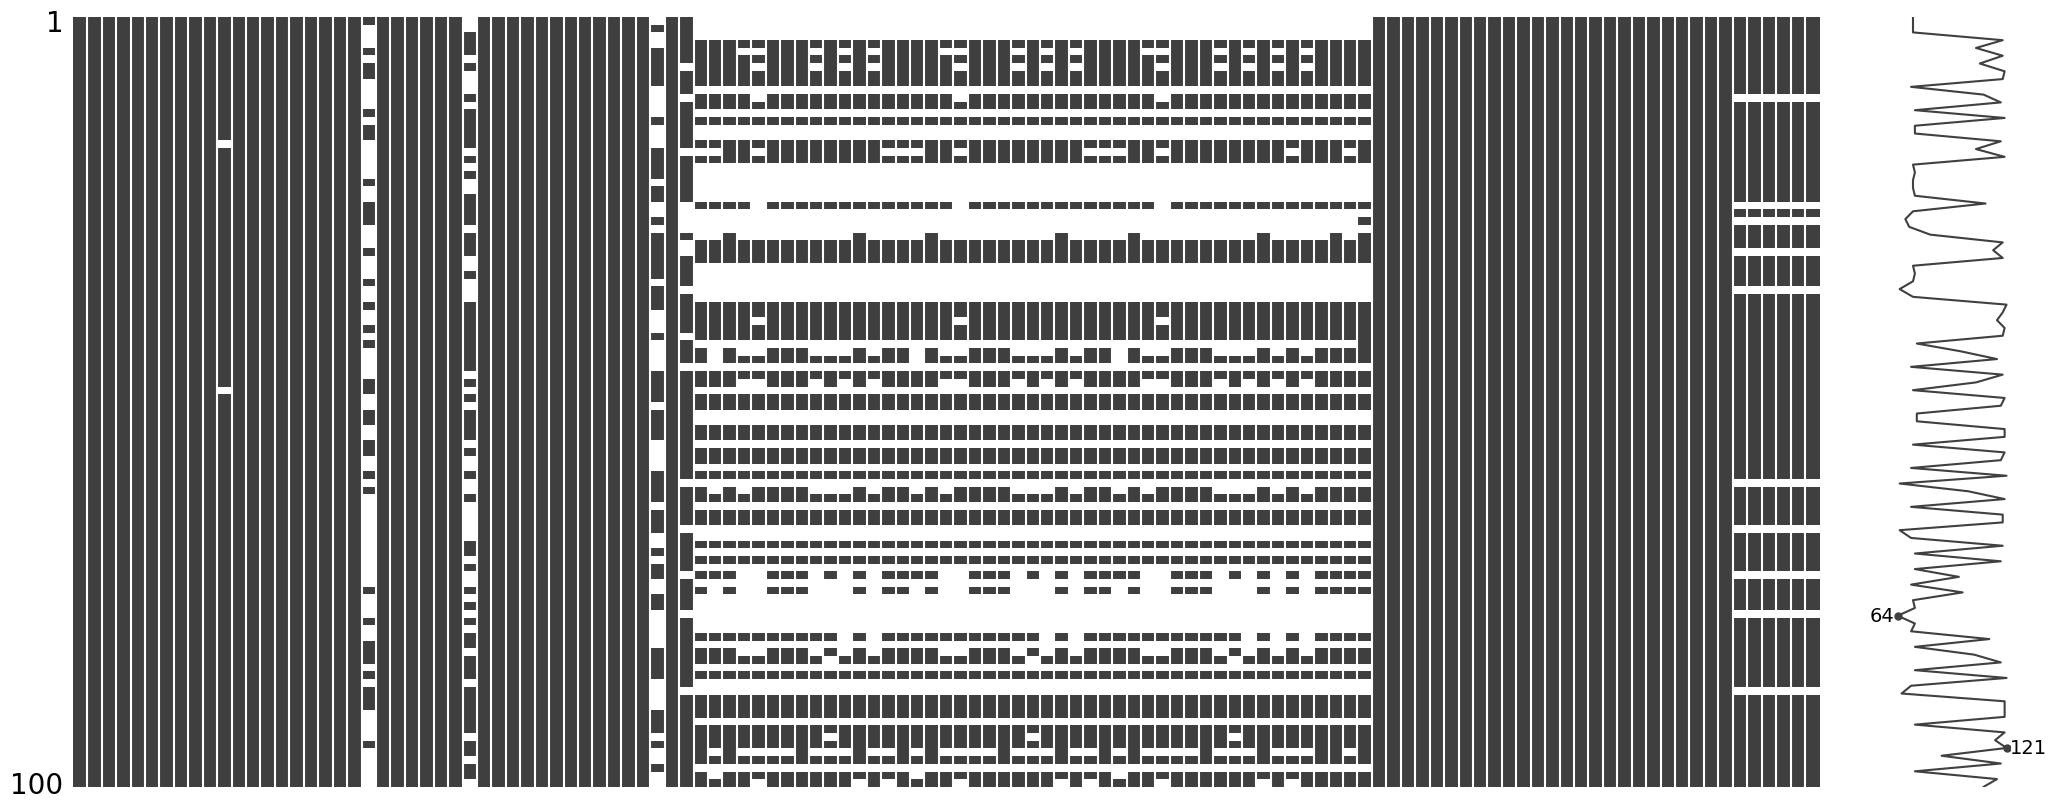

In [47]:
%matplotlib inline
msno.matrix(dfs['application_test'].sample(100))

<Axes: >

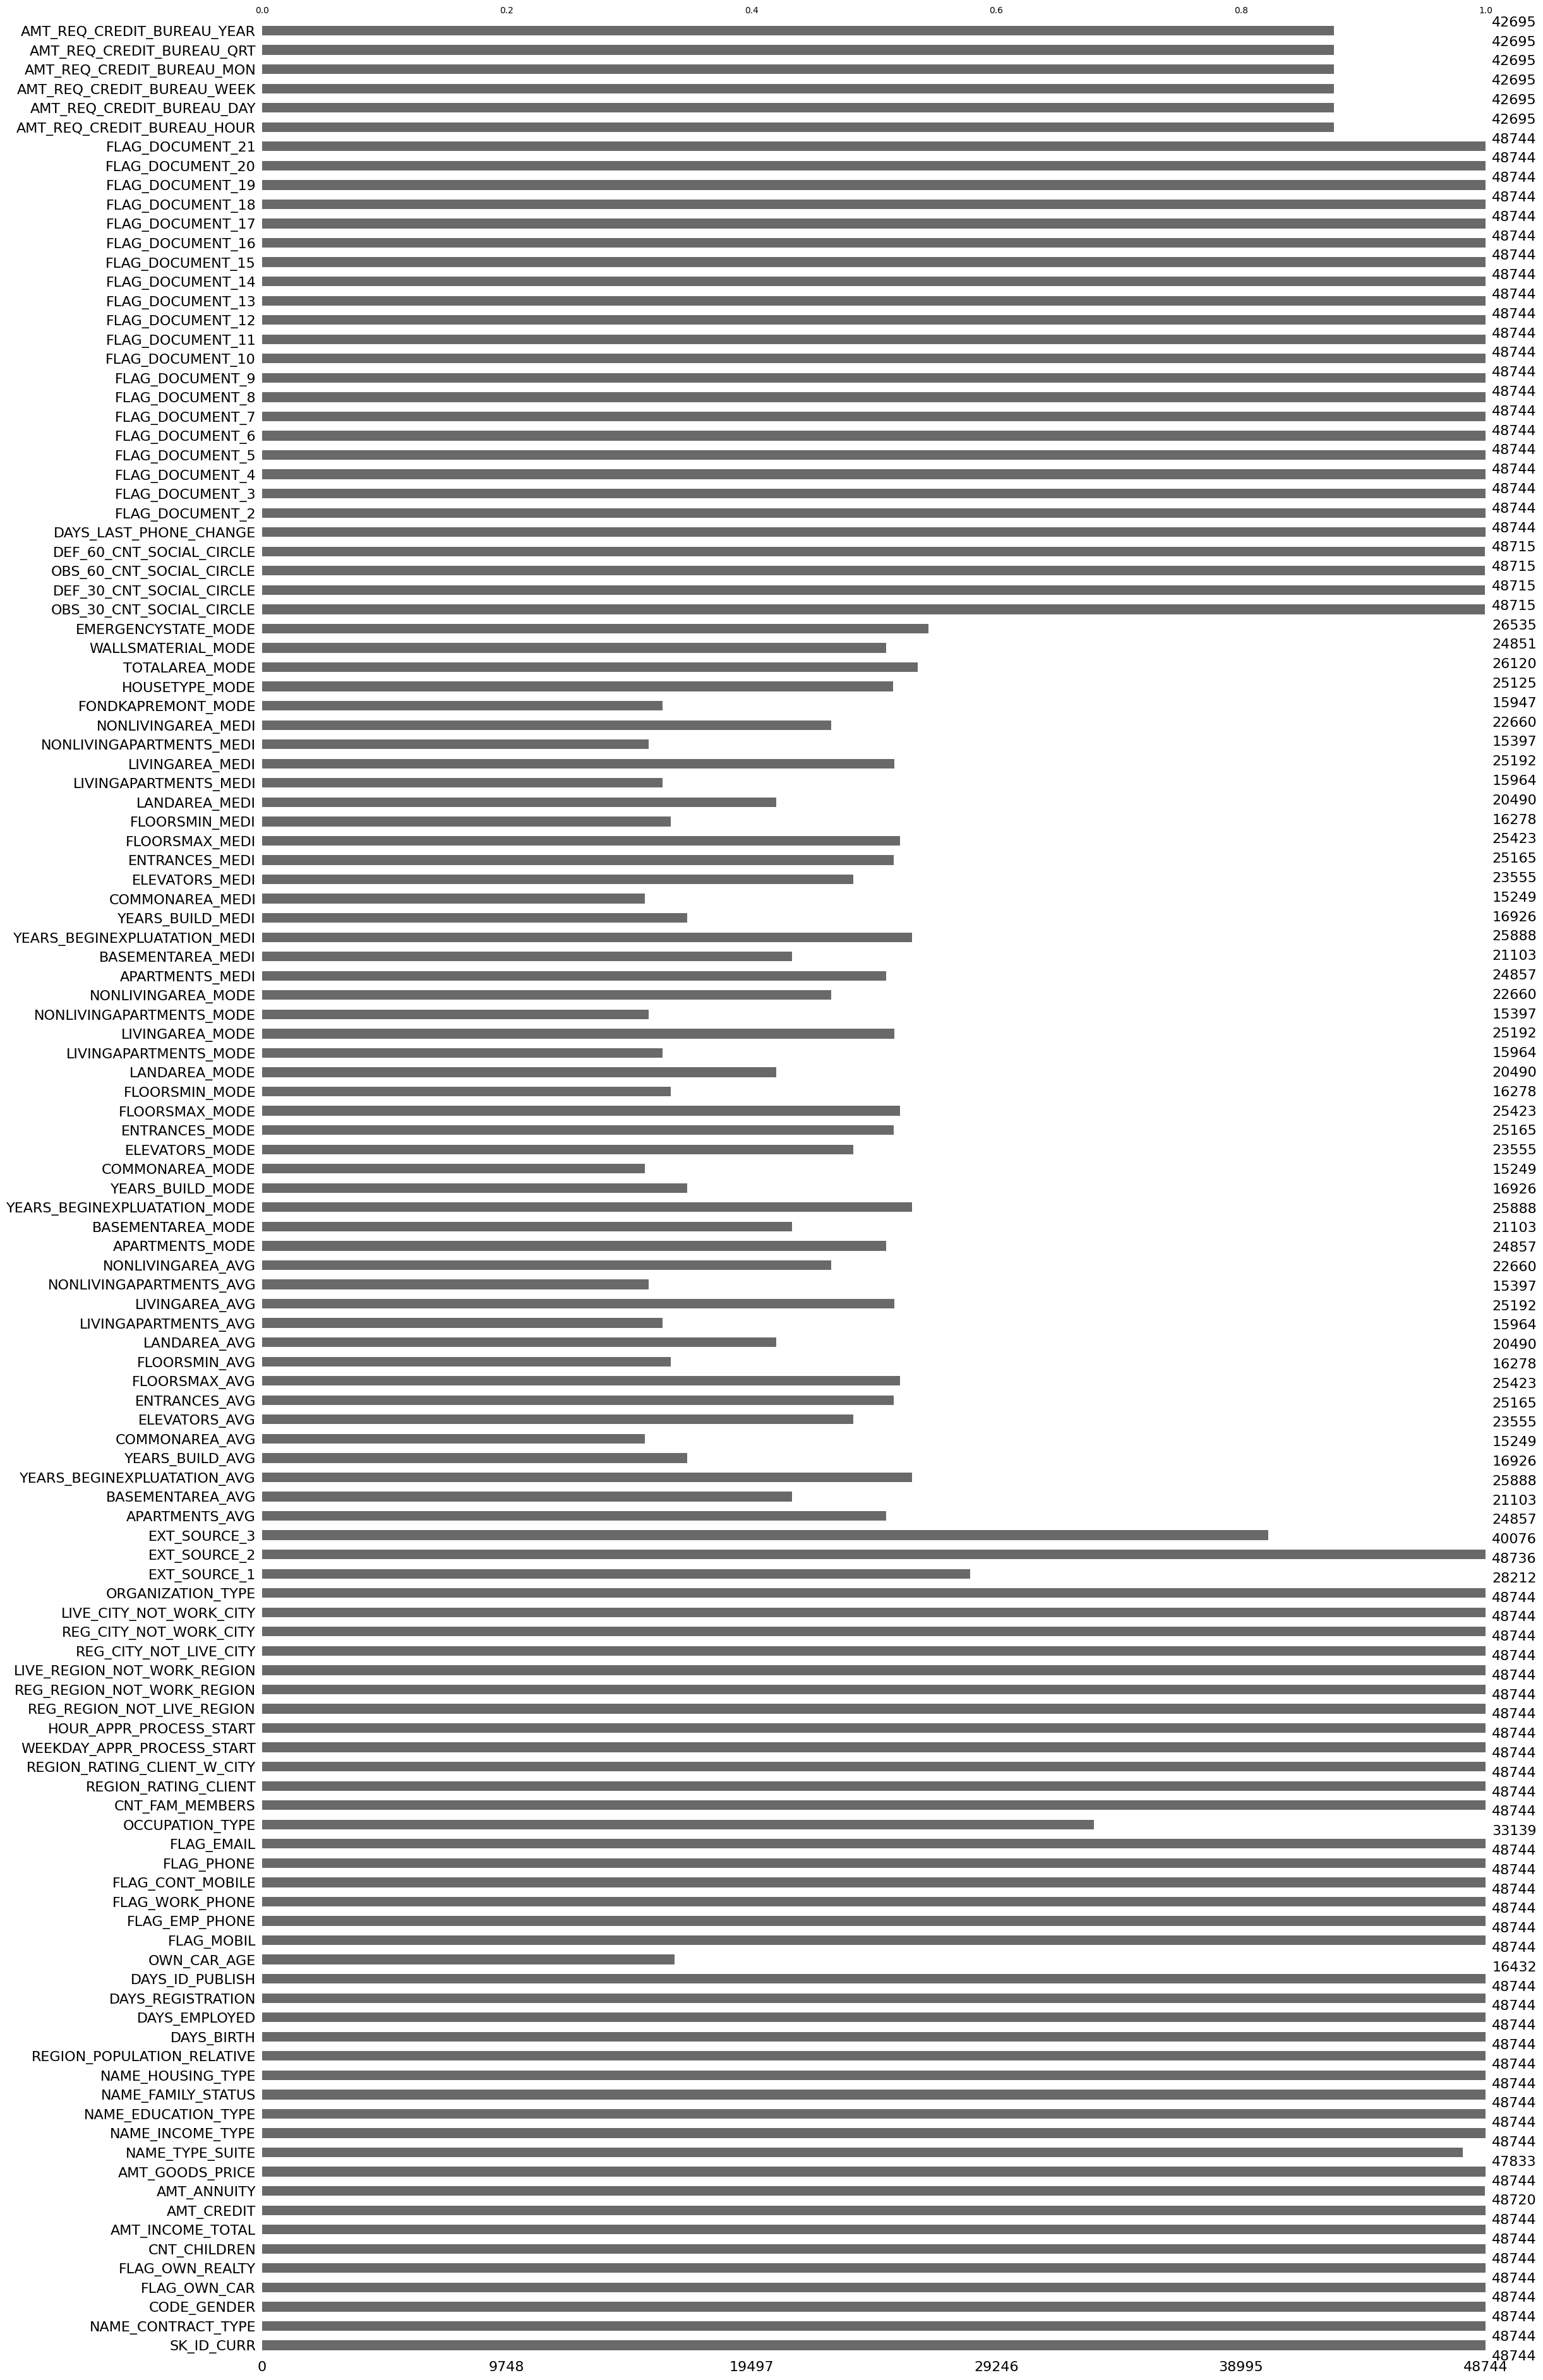

In [48]:
msno.bar(dfs['application_test'])

In [49]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_test'].nunique().sort_values(ascending=False)
    )

SK_ID_CURR                      48744
EXT_SOURCE_2                    38885
EXT_SOURCE_1                    27207
DAYS_BIRTH                      15477
DAYS_REGISTRATION               12618
DAYS_EMPLOYED                    7863
AMT_ANNUITY                      7491
DAYS_ID_PUBLISH                  5880
LIVINGAREA_MEDI                  3885
LIVINGAREA_AVG                   3848
LIVINGAREA_MODE                  3842
TOTALAREA_MODE                   3820
DAYS_LAST_PHONE_CHANGE           3579
AMT_CREDIT                       2937
BASEMENTAREA_MODE                2835
BASEMENTAREA_AVG                 2816
BASEMENTAREA_MEDI                2805
LANDAREA_MEDI                    2562
LANDAREA_MODE                    2560
LANDAREA_AVG                     2540
COMMONAREA_AVG                   2042
COMMONAREA_MEDI                  2034
NONLIVINGAREA_MEDI               2030
NONLIVINGAREA_AVG                2026
NONLIVINGAREA_MODE               2025
COMMONAREA_MODE                  2001
APARTMENTS_A

In [50]:
for col in dfs["application_test"].columns:
    n = dfs["application_test"][col].nunique()
    if (n <= 30 and n > 2): # Only columns with fewer than 30 unique values, but more than 2, are displayed (this excludes flags and other binary columns)
        print(f"{col} ({n} values) :", dfs["application_test"][col].unique(), "\n")

CNT_CHILDREN (11 values) : [ 0  2  1  3  8  4  6  5  7 20 11] 

NAME_TYPE_SUITE (7 values) : ['Unaccompanied' nan 'Family' 'Spouse, partner' 'Group of people'
 'Other_B' 'Children' 'Other_A'] 

NAME_INCOME_TYPE (7 values) : ['Working' 'State servant' 'Pensioner' 'Commercial associate'
 'Businessman' 'Student' 'Unemployed'] 

NAME_EDUCATION_TYPE (5 values) : ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree'] 

NAME_FAMILY_STATUS (5 values) : ['Married' 'Single / not married' 'Civil marriage' 'Widow' 'Separated'] 

NAME_HOUSING_TYPE (6 values) : ['House / apartment' 'With parents' 'Rented apartment'
 'Municipal apartment' 'Office apartment' 'Co-op apartment'] 

OCCUPATION_TYPE (18 values) : [nan 'Low-skill Laborers' 'Drivers' 'Sales staff' 'High skill tech staff'
 'Core staff' 'Laborers' 'Managers' 'Accountants' 'Medicine staff'
 'Security staff' 'Private service staff' 'Secretaries' 'Cleaning staff'
 'Cooking staff' 'HR staff' '

In [51]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['application_test'].value_counts()
    )

SK_ID_CURR  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  NAME_TYPE_SUITE  NAME_INCOME_TYPE      NAME_EDUCATION_TYPE            NAME_FAMILY_STATUS    NAME_HOUSING_TYPE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL  OCCUPATION_TYPE  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY  WEEKDAY_APPR_PROCESS_START  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY  ORGANIZATION_TYPE       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  FLOORSMAX_AVG  FLOORSMIN_AVG  LANDAREA_AVG  LIVINGAPARTMENTS

In [52]:
len(dfs["application_test"].select_dtypes(include="number").columns)

105

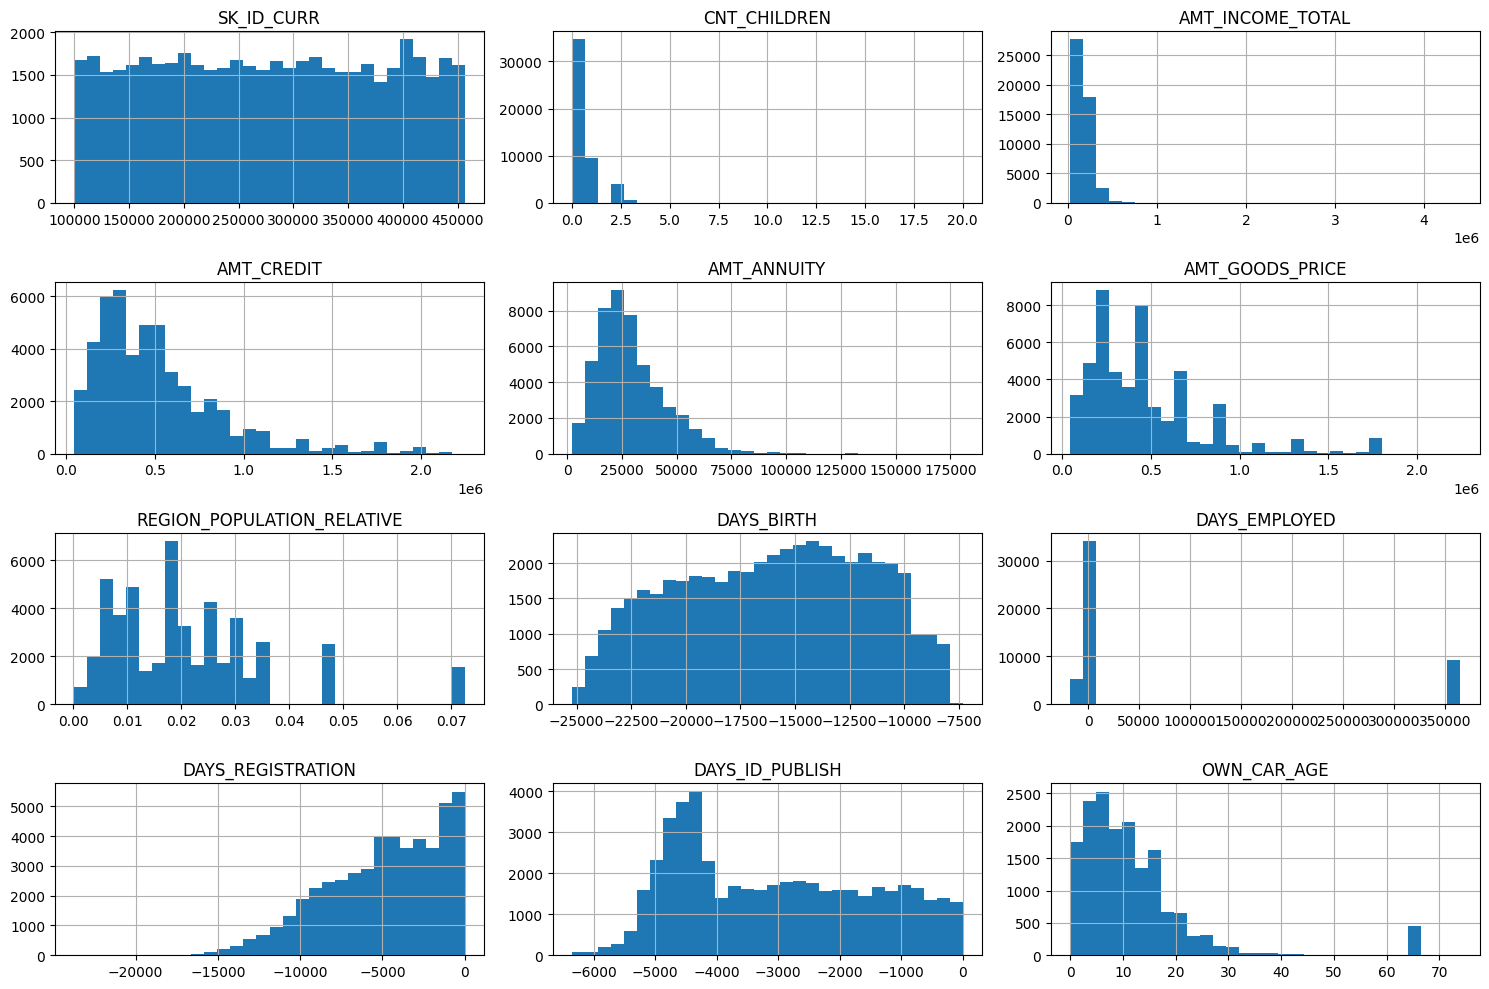

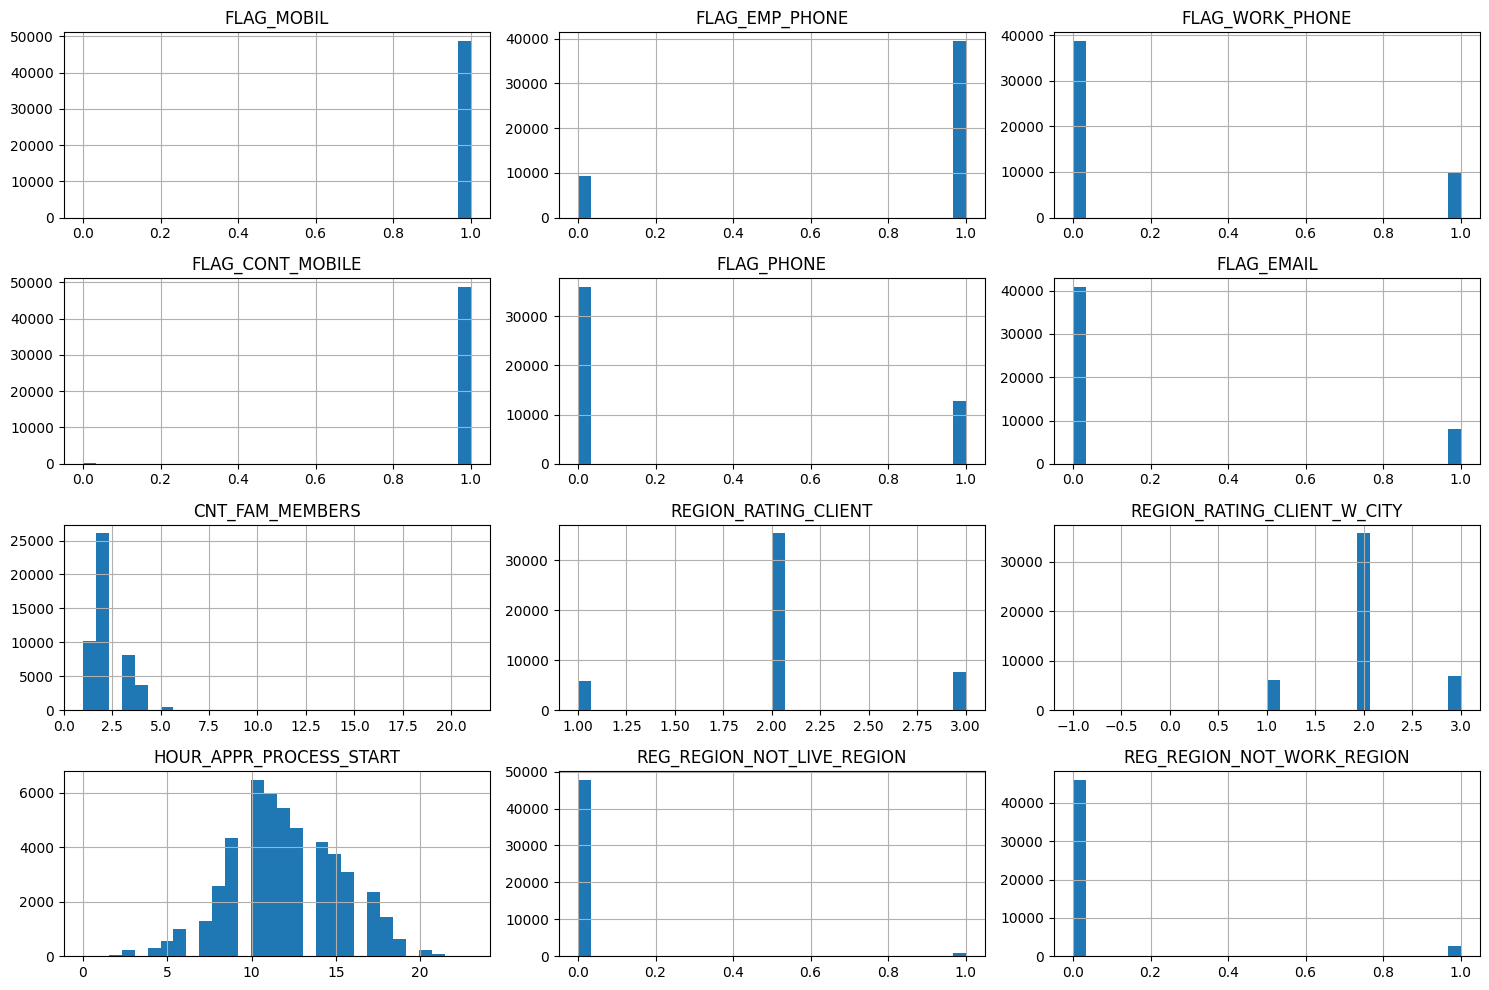

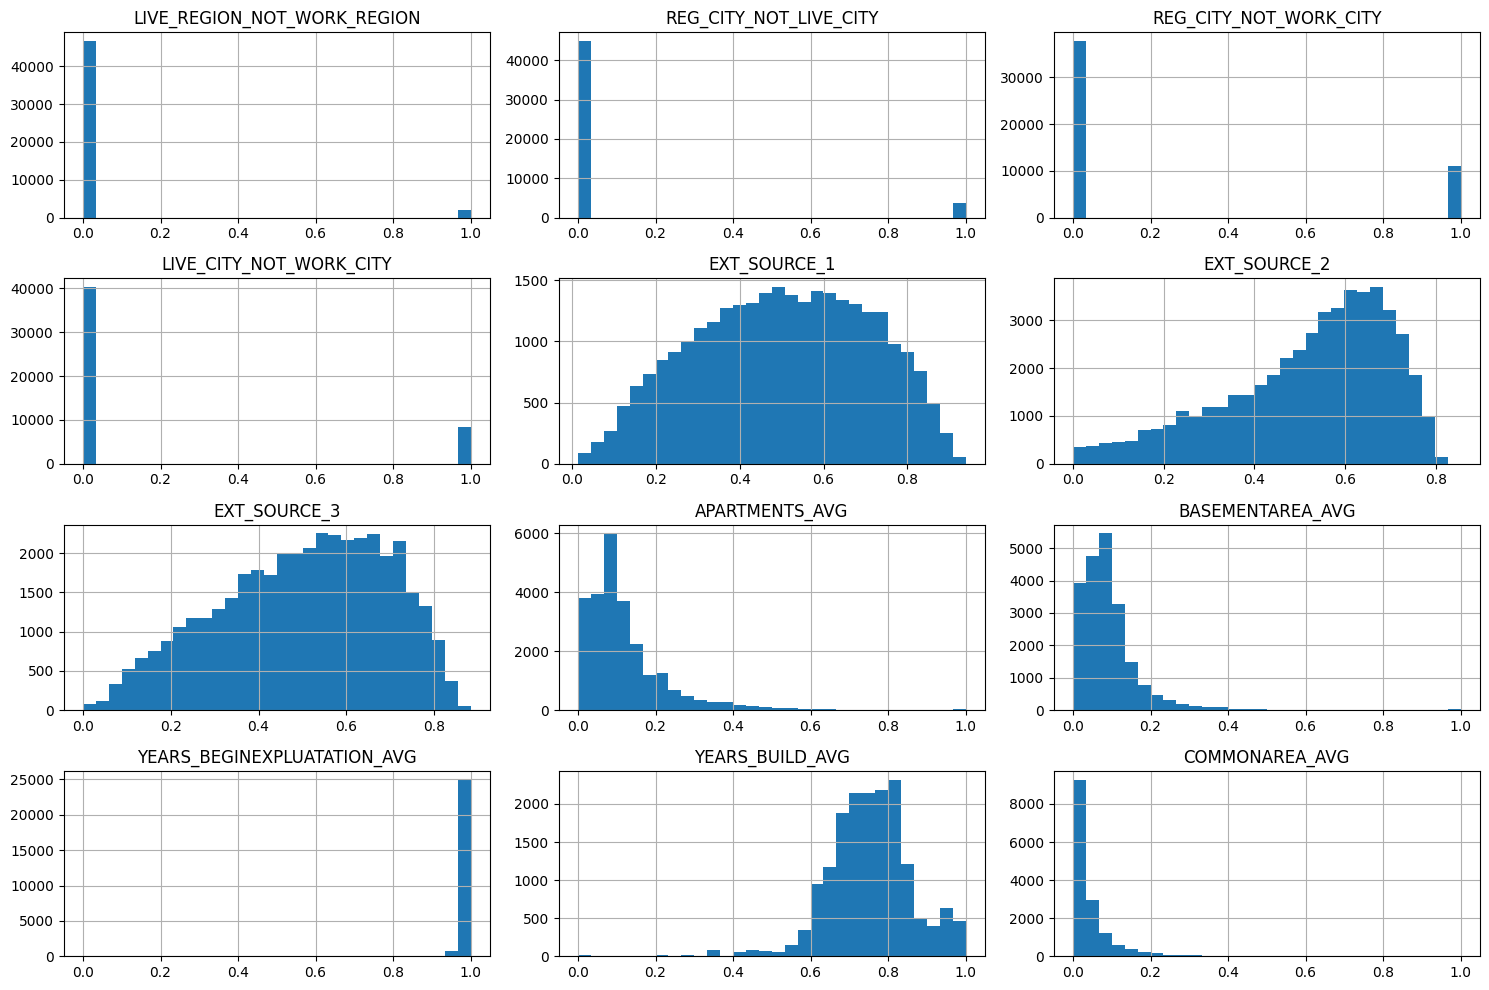

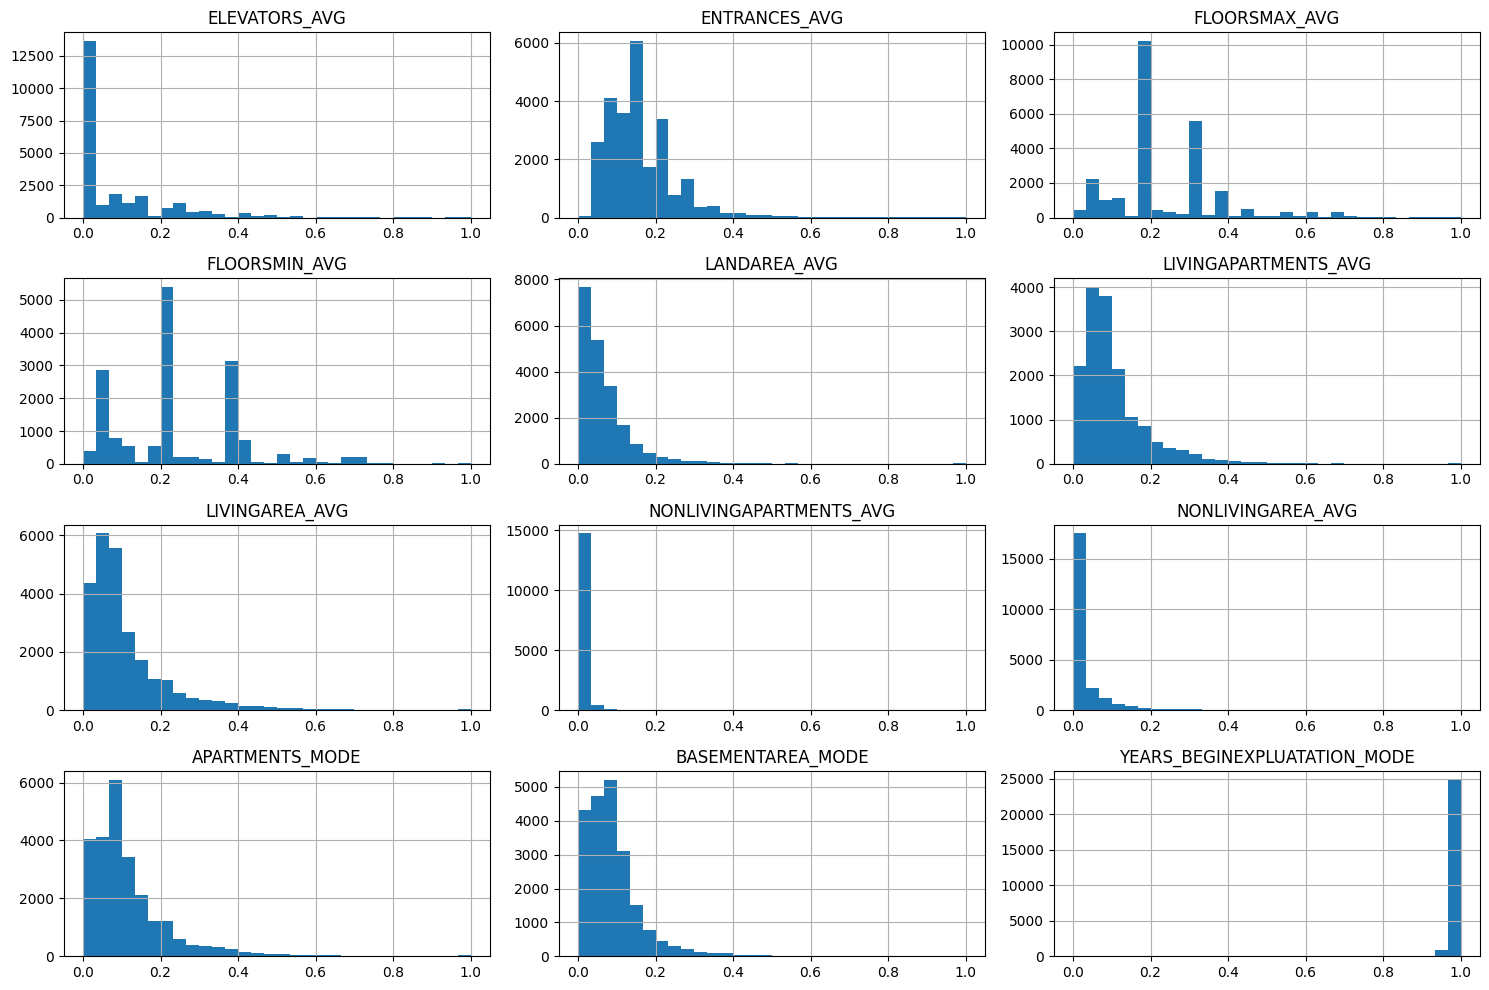

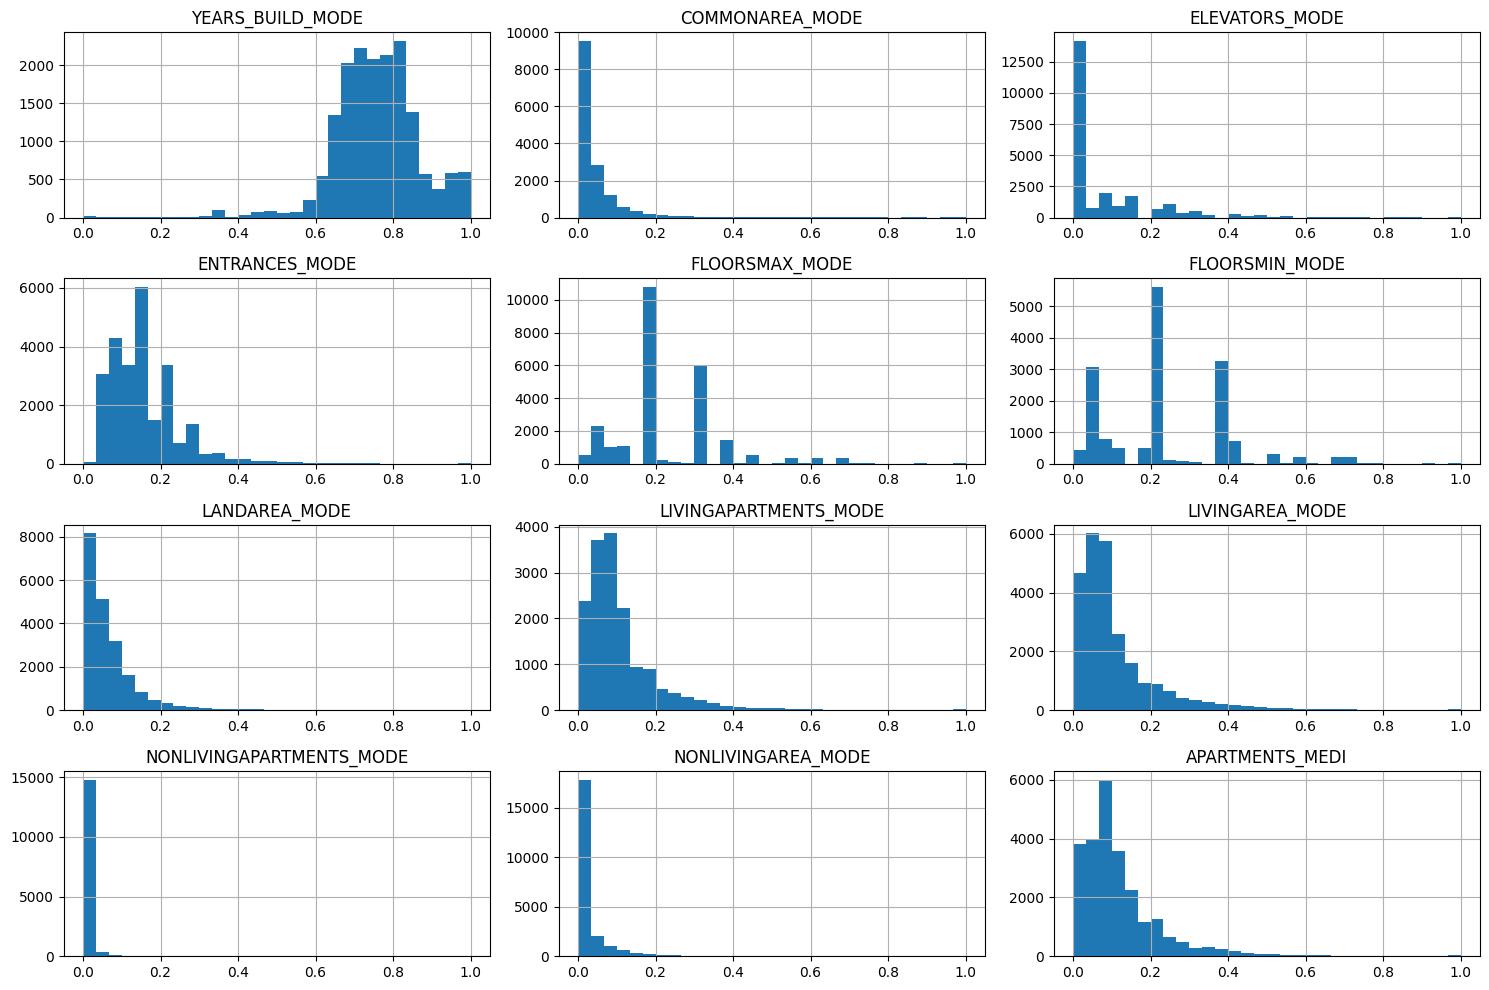

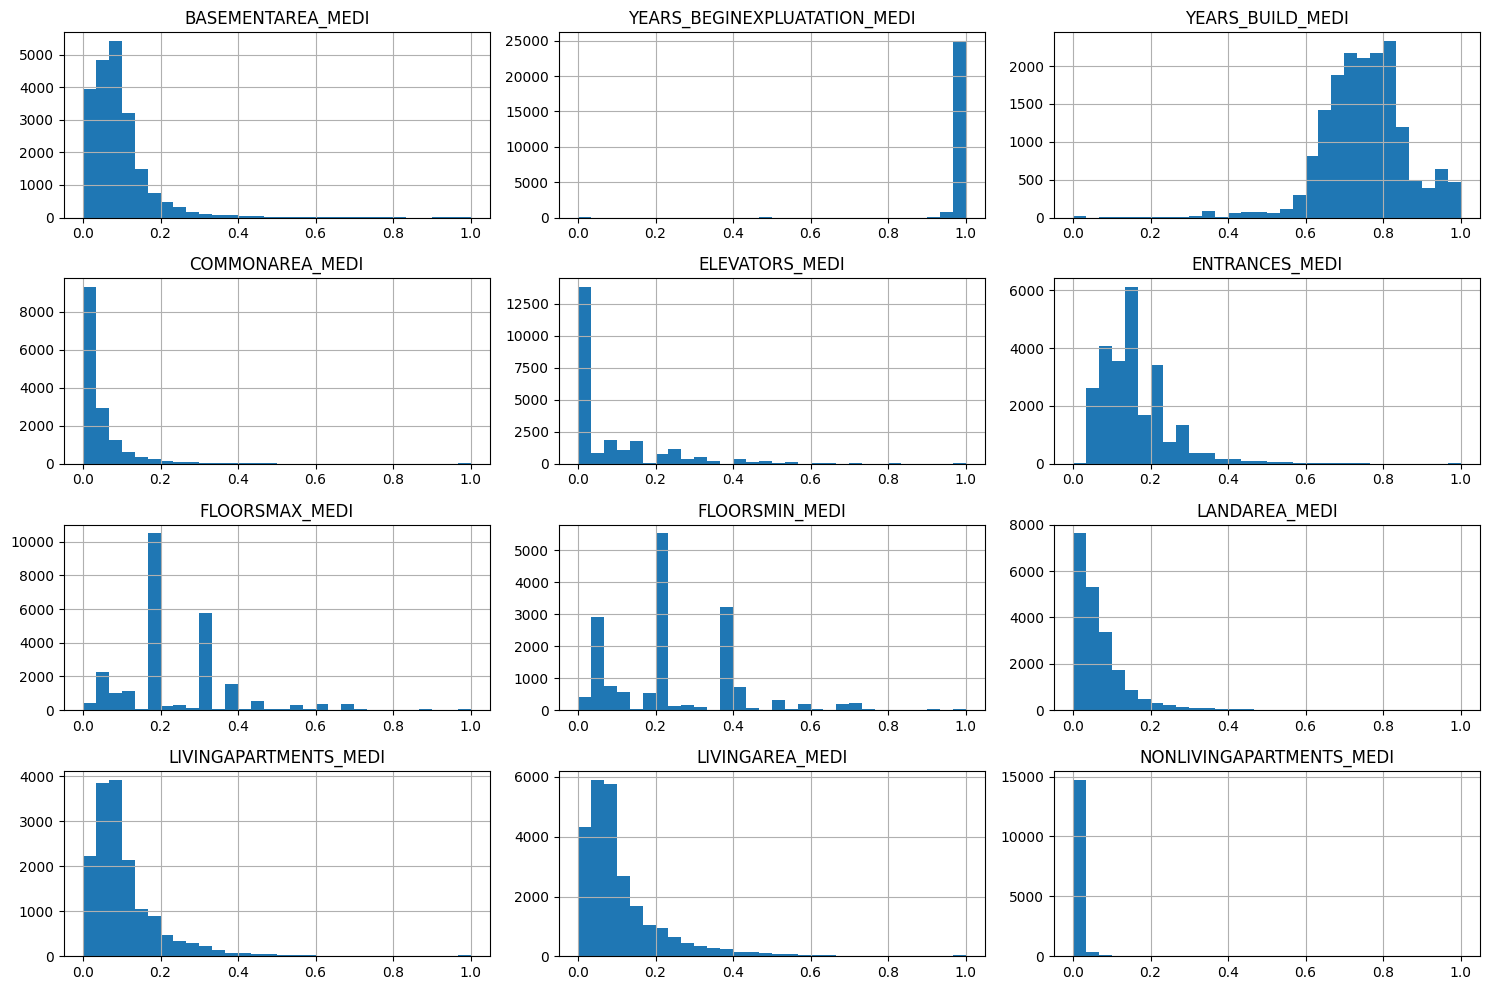

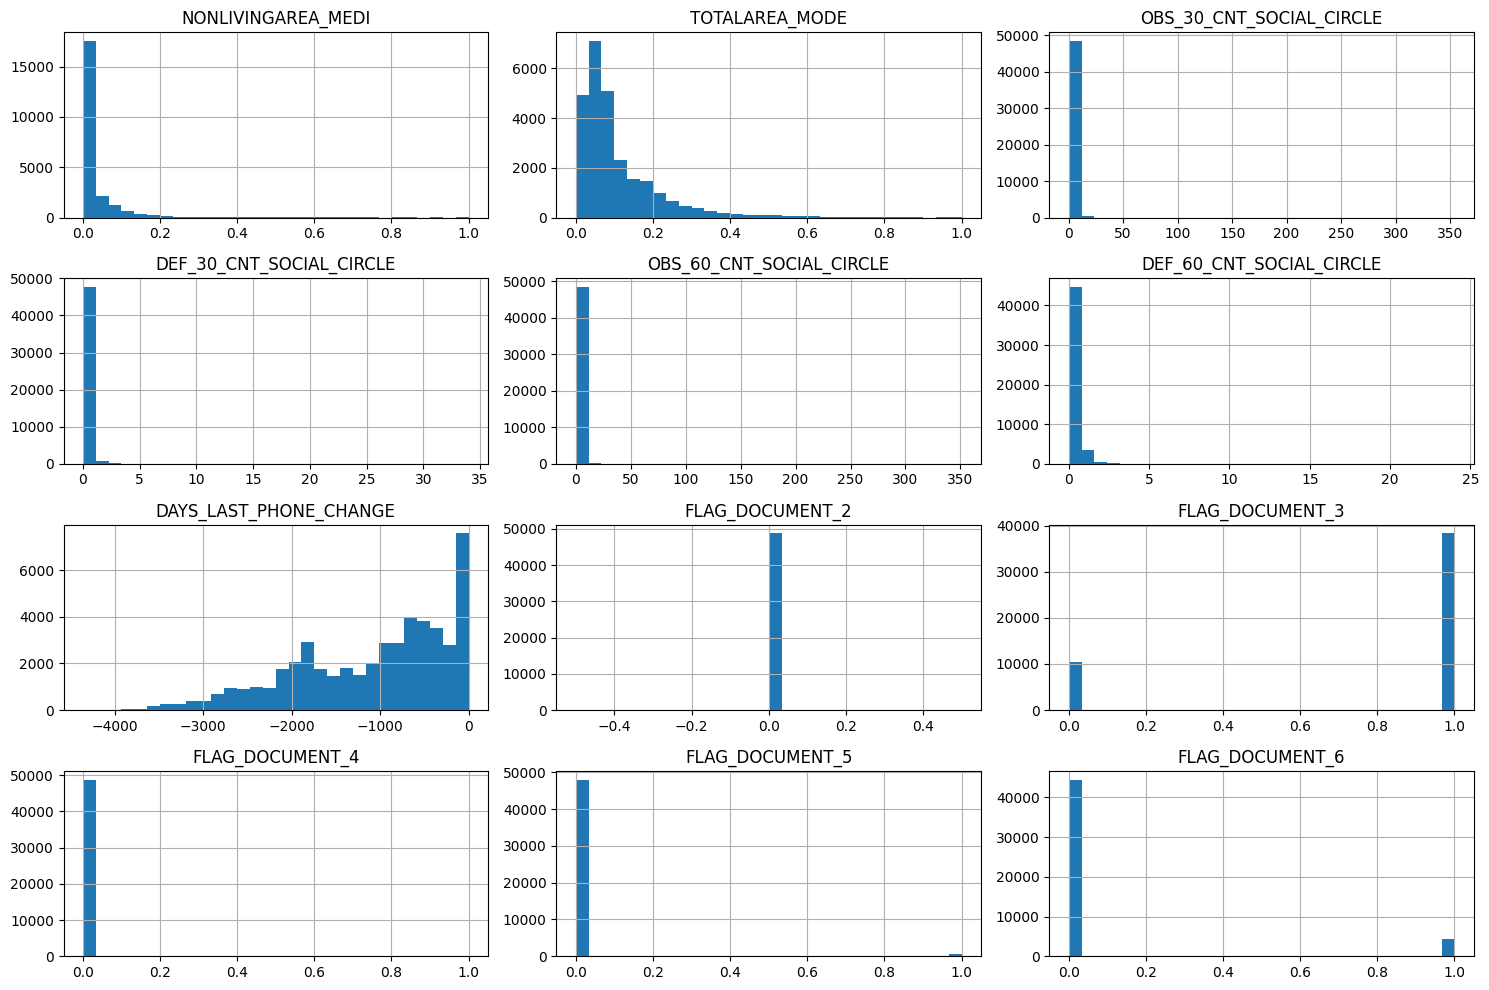

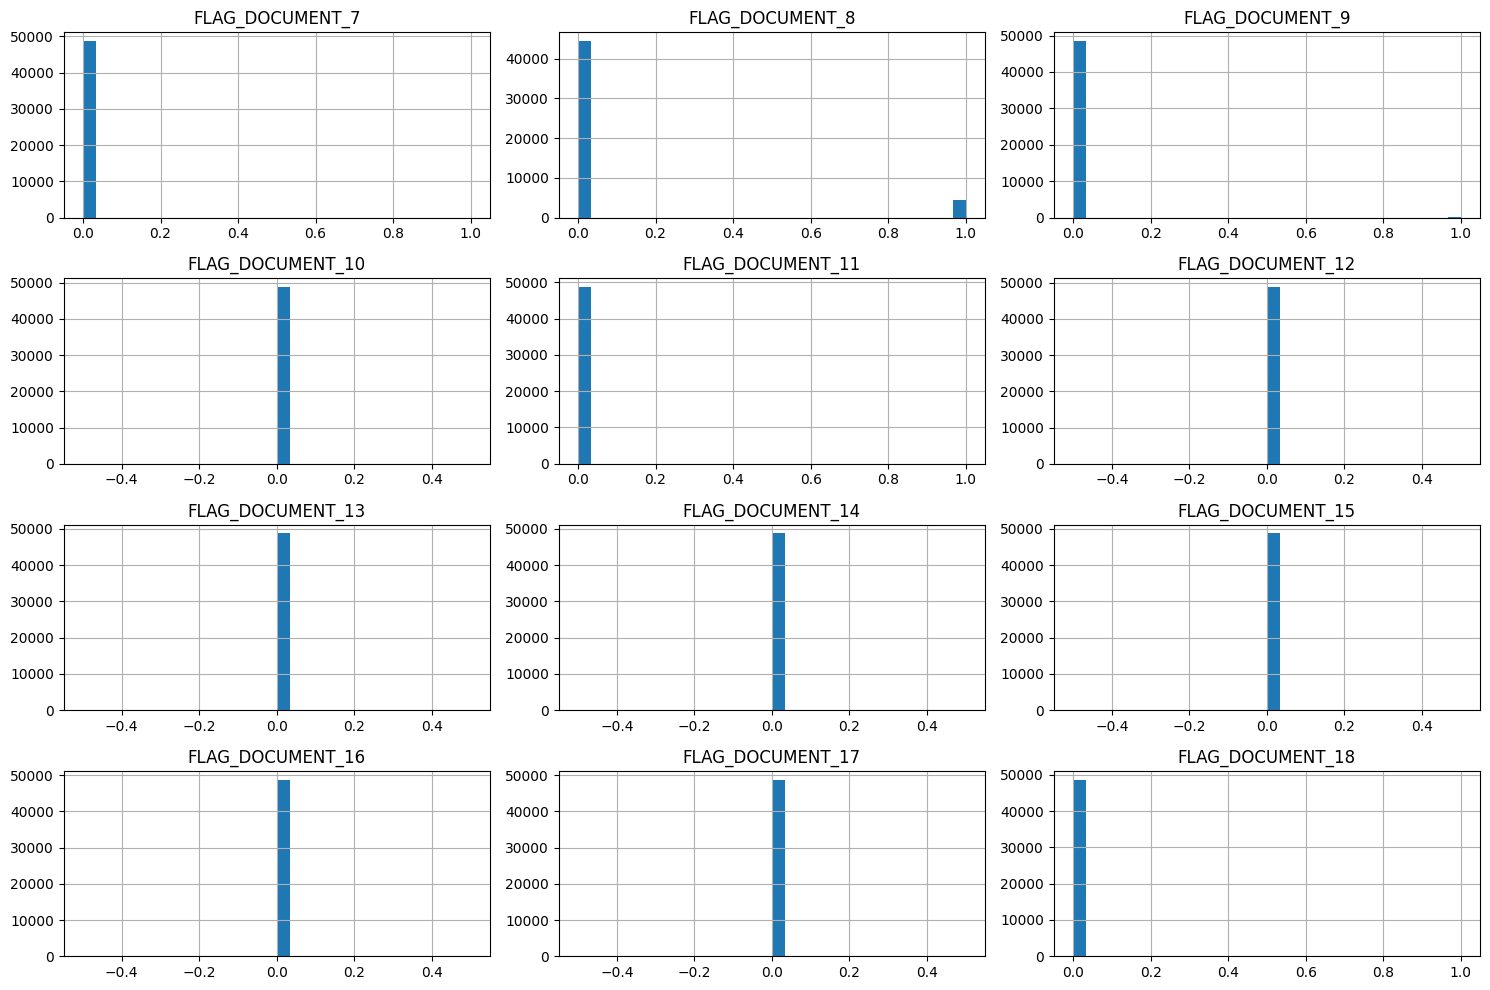

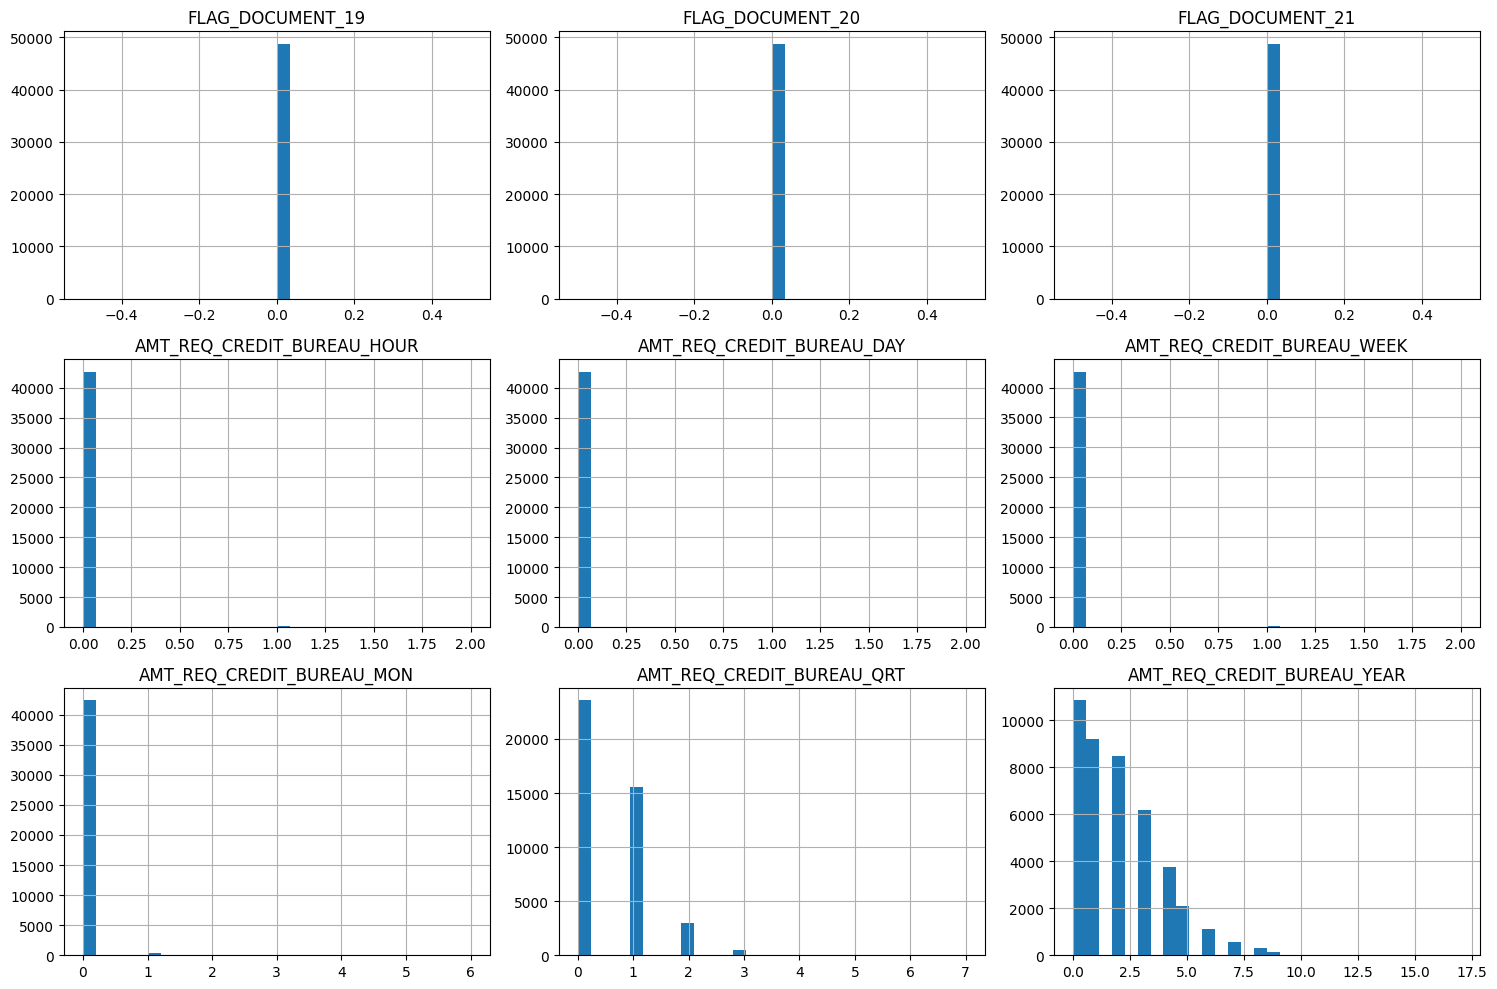

In [53]:
numeric_cols = dfs["application_test"].select_dtypes(include="number").columns
chunk_size = 12

for i in range(0, len(numeric_cols), chunk_size):
    cols_chunk = numeric_cols[i:i + chunk_size]
    dfs["application_test"][cols_chunk].hist(figsize=(15, 10), bins=30)
    plt.tight_layout()
    plt.show()

In [54]:
for c in ['DAYS_BIRTH', 'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    print(c, (dfs["application_test"][c] == 0).sum())

DAYS_BIRTH 0
DAYS_EMPLOYED 0
DAYS_REGISTRATION 13
DAYS_ID_PUBLISH 5
DAYS_LAST_PHONE_CHANGE 5801


##### 5. bureau table

In [55]:
dfs['bureau']

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [56]:
dfs['bureau'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [57]:
((dfs['bureau'].isnull().sum() / len(dfs['bureau'])) * 100).round(2).sort_values(ascending=False)

AMT_ANNUITY               71.47
AMT_CREDIT_MAX_OVERDUE    65.51
DAYS_ENDDATE_FACT         36.92
AMT_CREDIT_SUM_LIMIT      34.48
AMT_CREDIT_SUM_DEBT       15.01
DAYS_CREDIT_ENDDATE        6.15
CREDIT_ACTIVE              0.00
CREDIT_CURRENCY            0.00
DAYS_CREDIT                0.00
CREDIT_DAY_OVERDUE         0.00
SK_ID_BUREAU               0.00
CNT_CREDIT_PROLONG         0.00
AMT_CREDIT_SUM             0.00
AMT_CREDIT_SUM_OVERDUE     0.00
CREDIT_TYPE                0.00
DAYS_CREDIT_UPDATE         0.00
SK_ID_CURR                 0.00
dtype: float64

<Axes: >

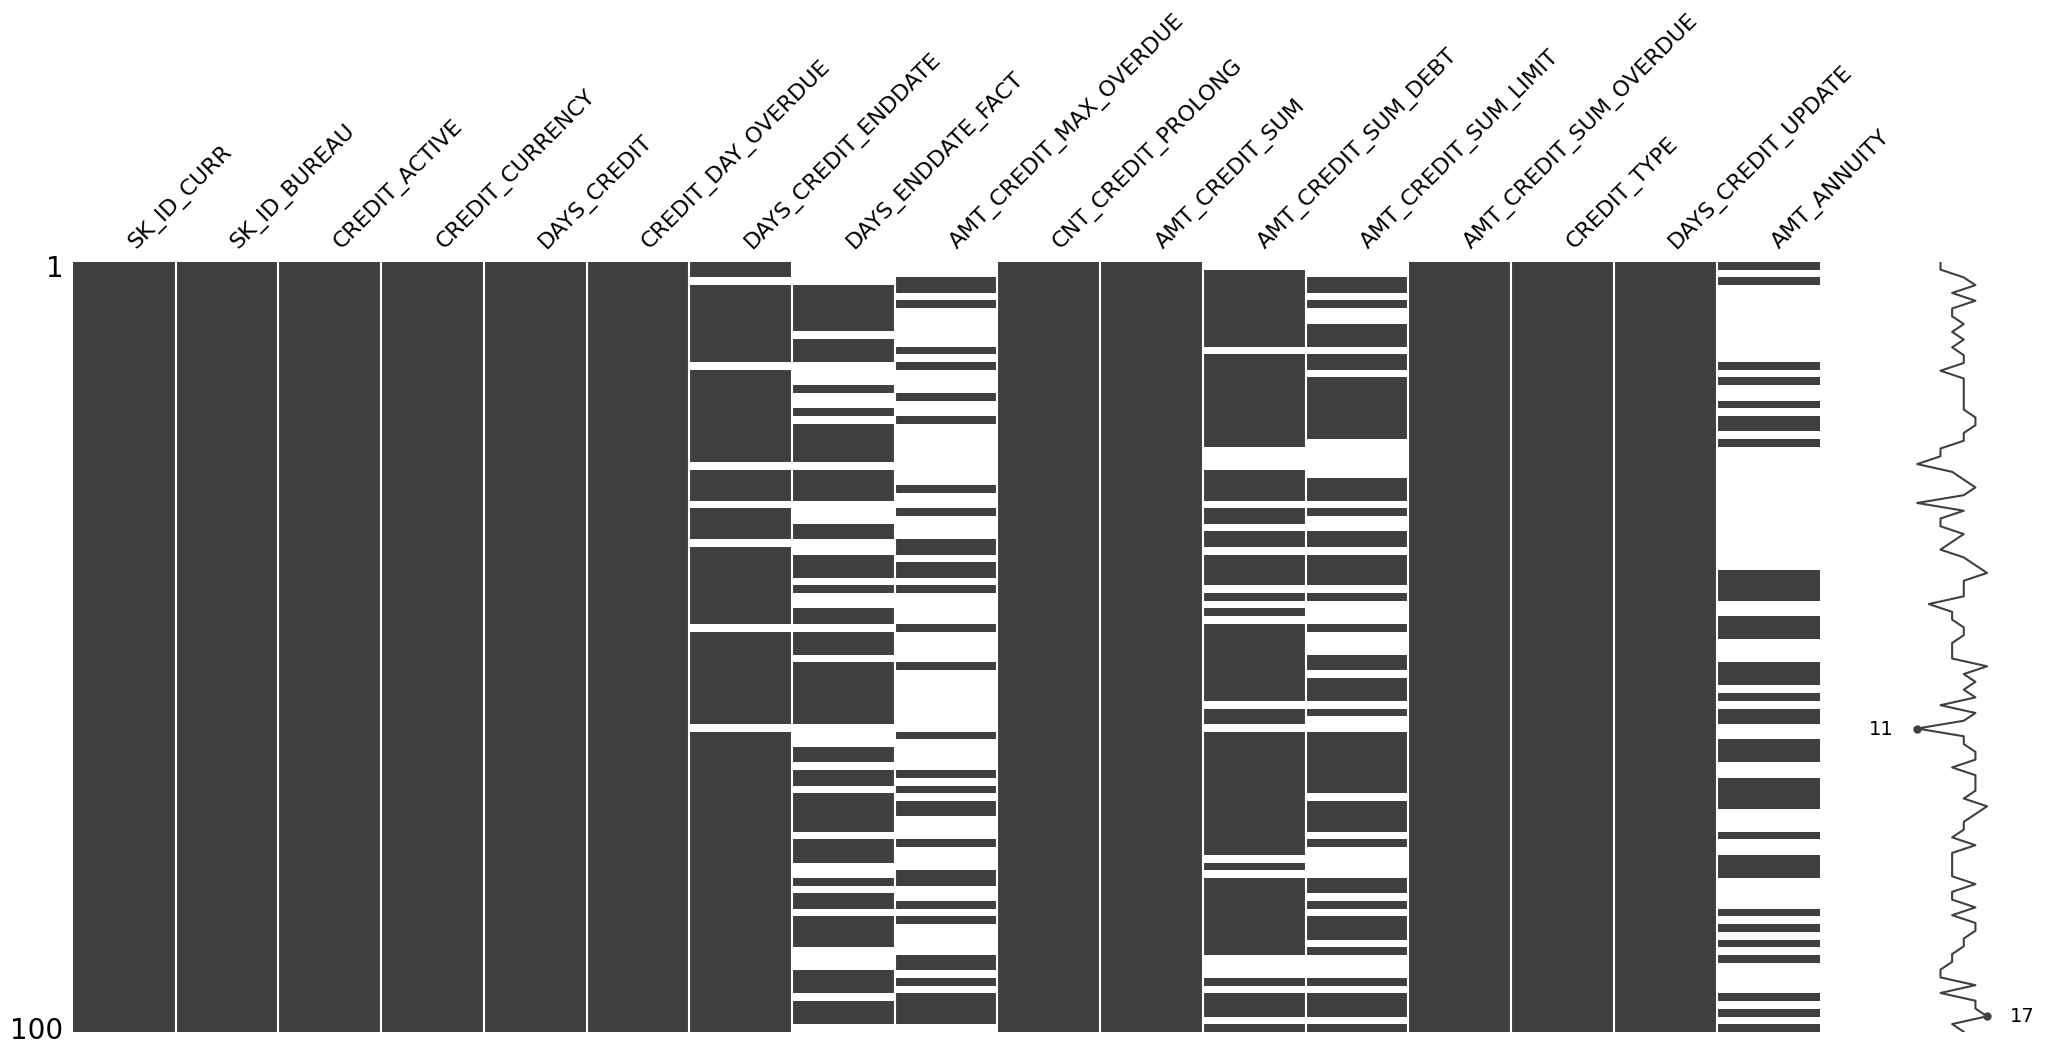

In [58]:
%matplotlib inline
msno.matrix(dfs['bureau'].sample(100))

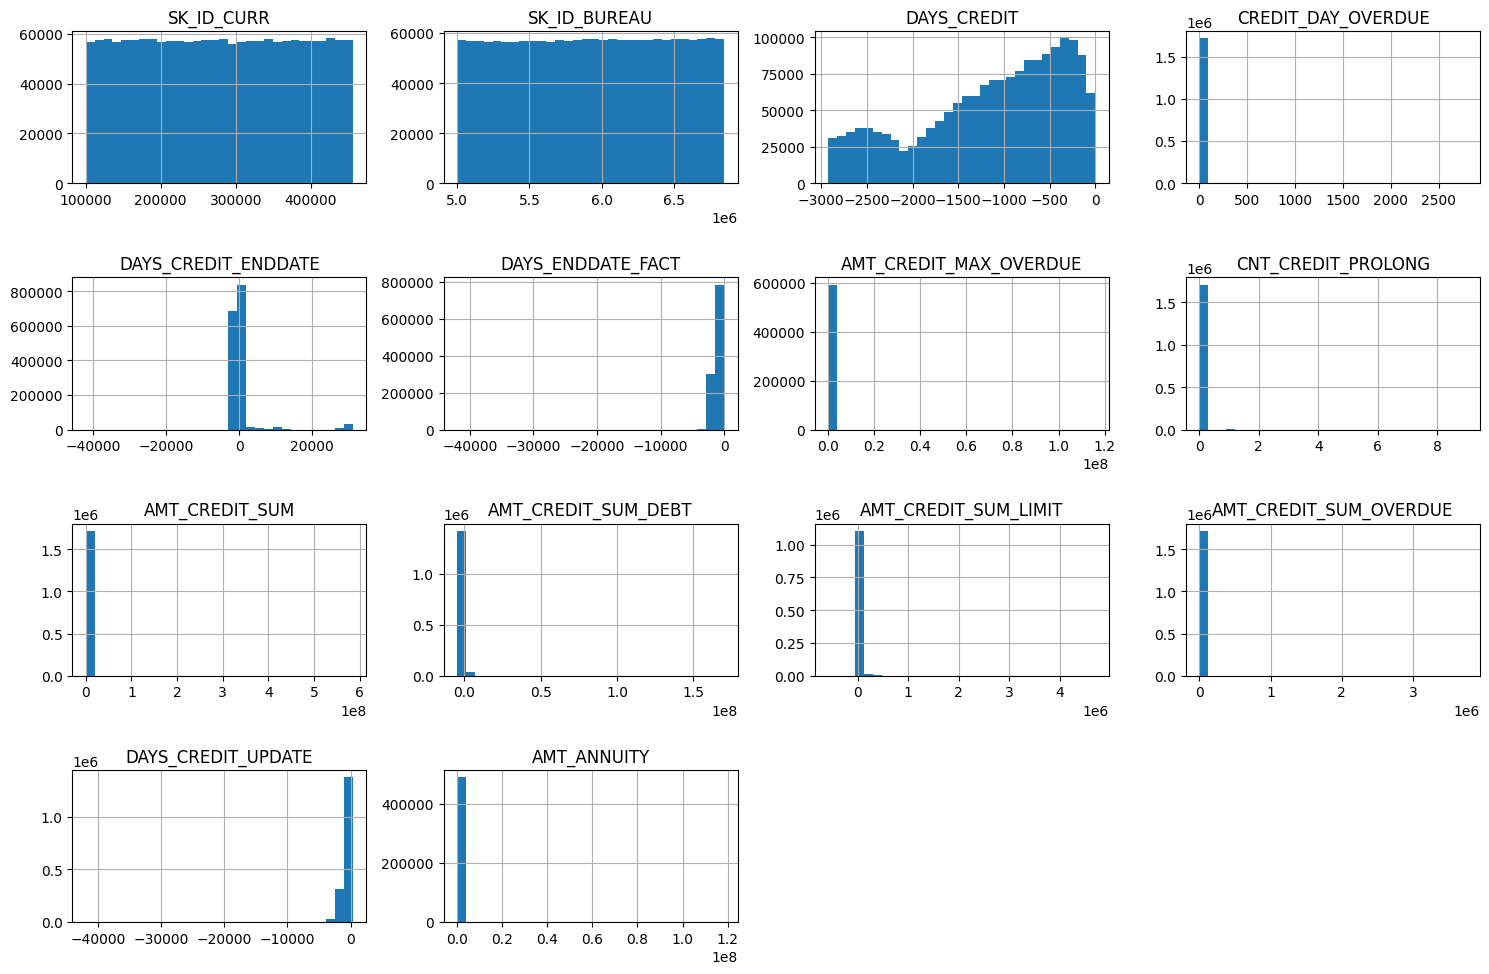

In [59]:
import matplotlib.pyplot as plt

dfs["bureau"].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 6. bureau_balance table

In [60]:
dfs['bureau_balance'].iloc[:200]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
195,5715455,-69,X
196,5715455,-70,X
197,5715455,-71,X
198,5715455,-72,X


In [61]:
dfs['bureau_balance'].info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [62]:
dfs['bureau_balance']['STATUS'].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

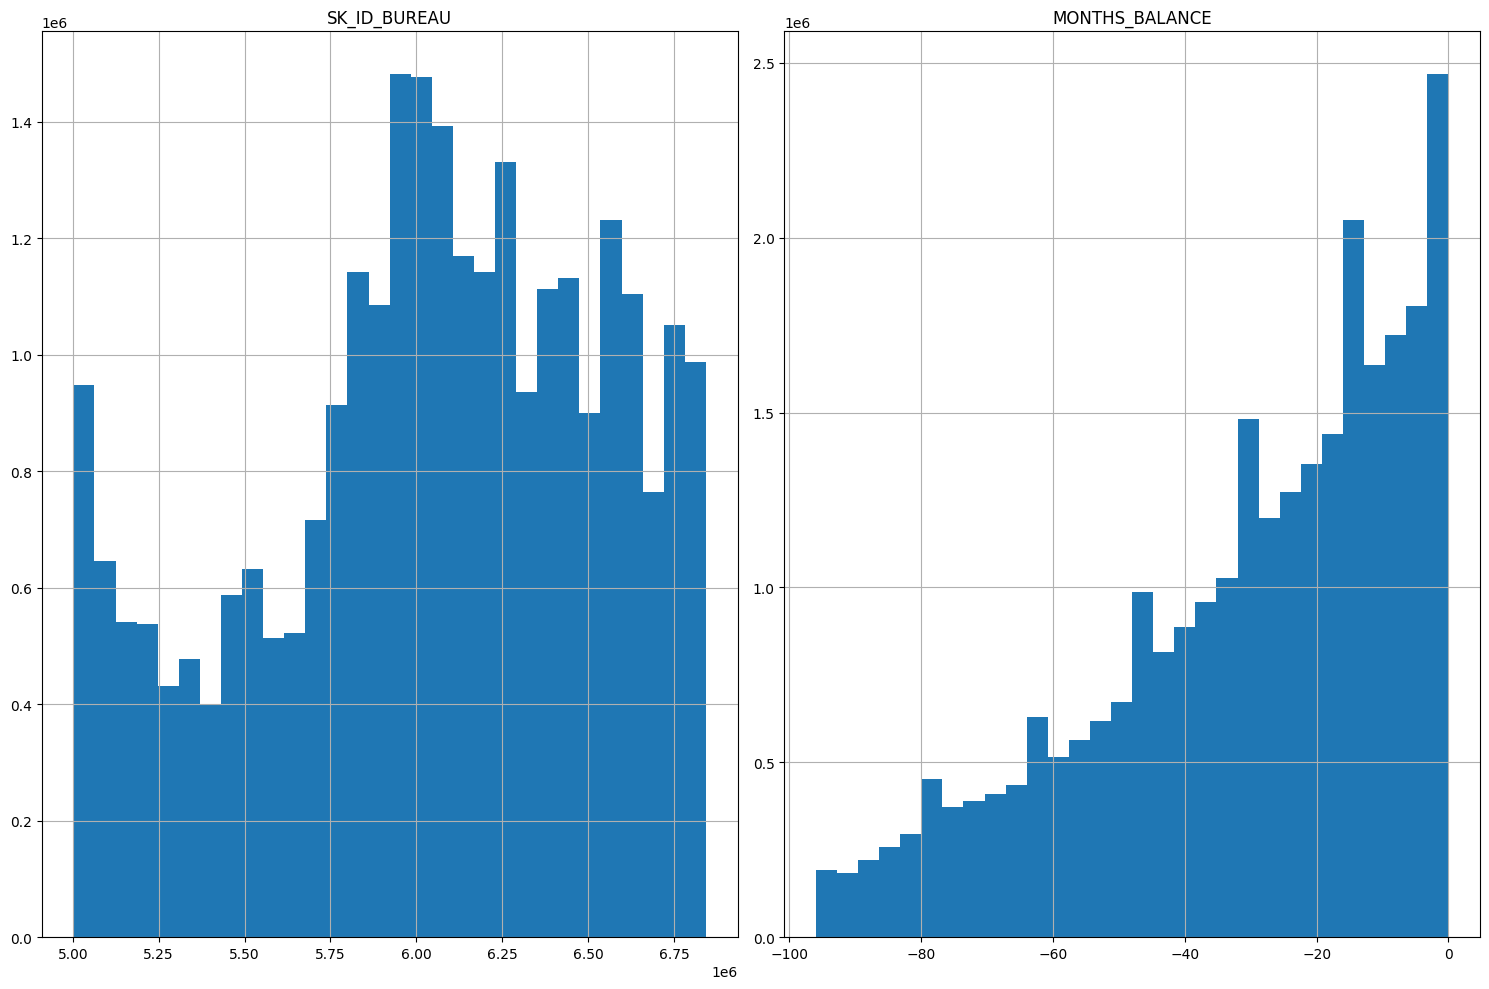

In [63]:
import matplotlib.pyplot as plt

dfs["bureau_balance"].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 7. credit_card_balance table

In [64]:
dfs['credit_card_balance']

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840307,1036507,328243,-9,0.000,45000,NaN,0.0,NaN,NaN,0.000,...,0.000,0.000,NaN,0,NaN,NaN,0.0,Active,0,0
3840308,1714892,347207,-9,0.000,45000,0.0,0.0,0.0,0.0,0.000,...,0.000,0.000,0.0,0,0.0,0.0,23.0,Active,0,0
3840309,1302323,215757,-9,275784.975,585000,270000.0,270000.0,0.0,0.0,2250.000,...,273093.975,273093.975,2.0,2,0.0,0.0,18.0,Active,0,0
3840310,1624872,430337,-10,0.000,450000,NaN,0.0,NaN,NaN,0.000,...,0.000,0.000,NaN,0,NaN,NaN,0.0,Active,0,0


In [65]:
dfs['credit_card_balance'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [66]:
((dfs['credit_card_balance'].isnull().sum() / len(dfs['credit_card_balance'])) * 100).round(2).sort_values(ascending=False)

AMT_PAYMENT_CURRENT           20.00
AMT_DRAWINGS_ATM_CURRENT      19.52
CNT_DRAWINGS_POS_CURRENT      19.52
AMT_DRAWINGS_OTHER_CURRENT    19.52
AMT_DRAWINGS_POS_CURRENT      19.52
CNT_DRAWINGS_OTHER_CURRENT    19.52
CNT_DRAWINGS_ATM_CURRENT      19.52
CNT_INSTALMENT_MATURE_CUM      7.95
AMT_INST_MIN_REGULARITY        7.95
SK_ID_PREV                     0.00
AMT_TOTAL_RECEIVABLE           0.00
SK_DPD                         0.00
NAME_CONTRACT_STATUS           0.00
CNT_DRAWINGS_CURRENT           0.00
AMT_PAYMENT_TOTAL_CURRENT      0.00
AMT_RECIVABLE                  0.00
AMT_RECEIVABLE_PRINCIPAL       0.00
SK_ID_CURR                     0.00
AMT_DRAWINGS_CURRENT           0.00
AMT_CREDIT_LIMIT_ACTUAL        0.00
AMT_BALANCE                    0.00
MONTHS_BALANCE                 0.00
SK_DPD_DEF                     0.00
dtype: float64

<Axes: >

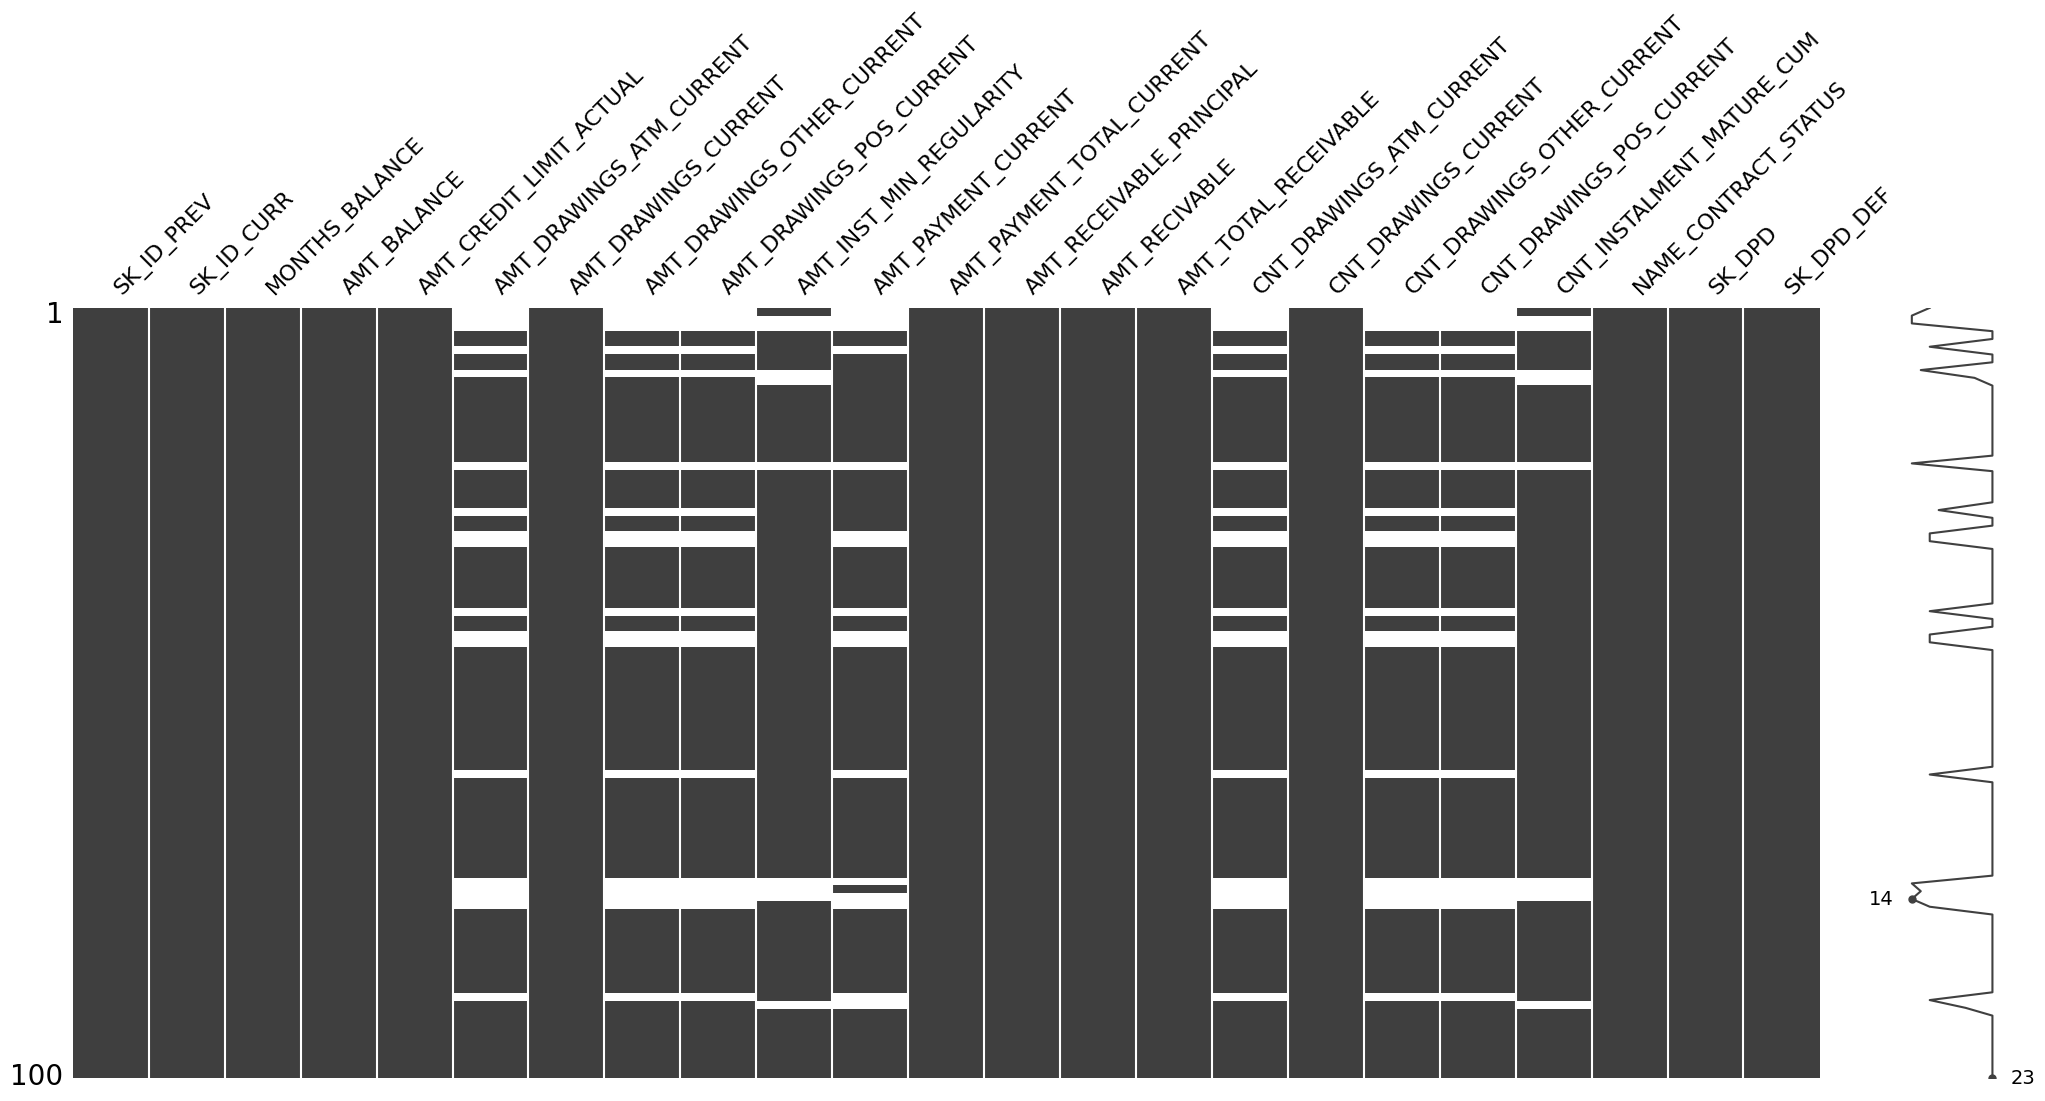

In [67]:
%matplotlib inline
msno.matrix(dfs['credit_card_balance'].sample(100))

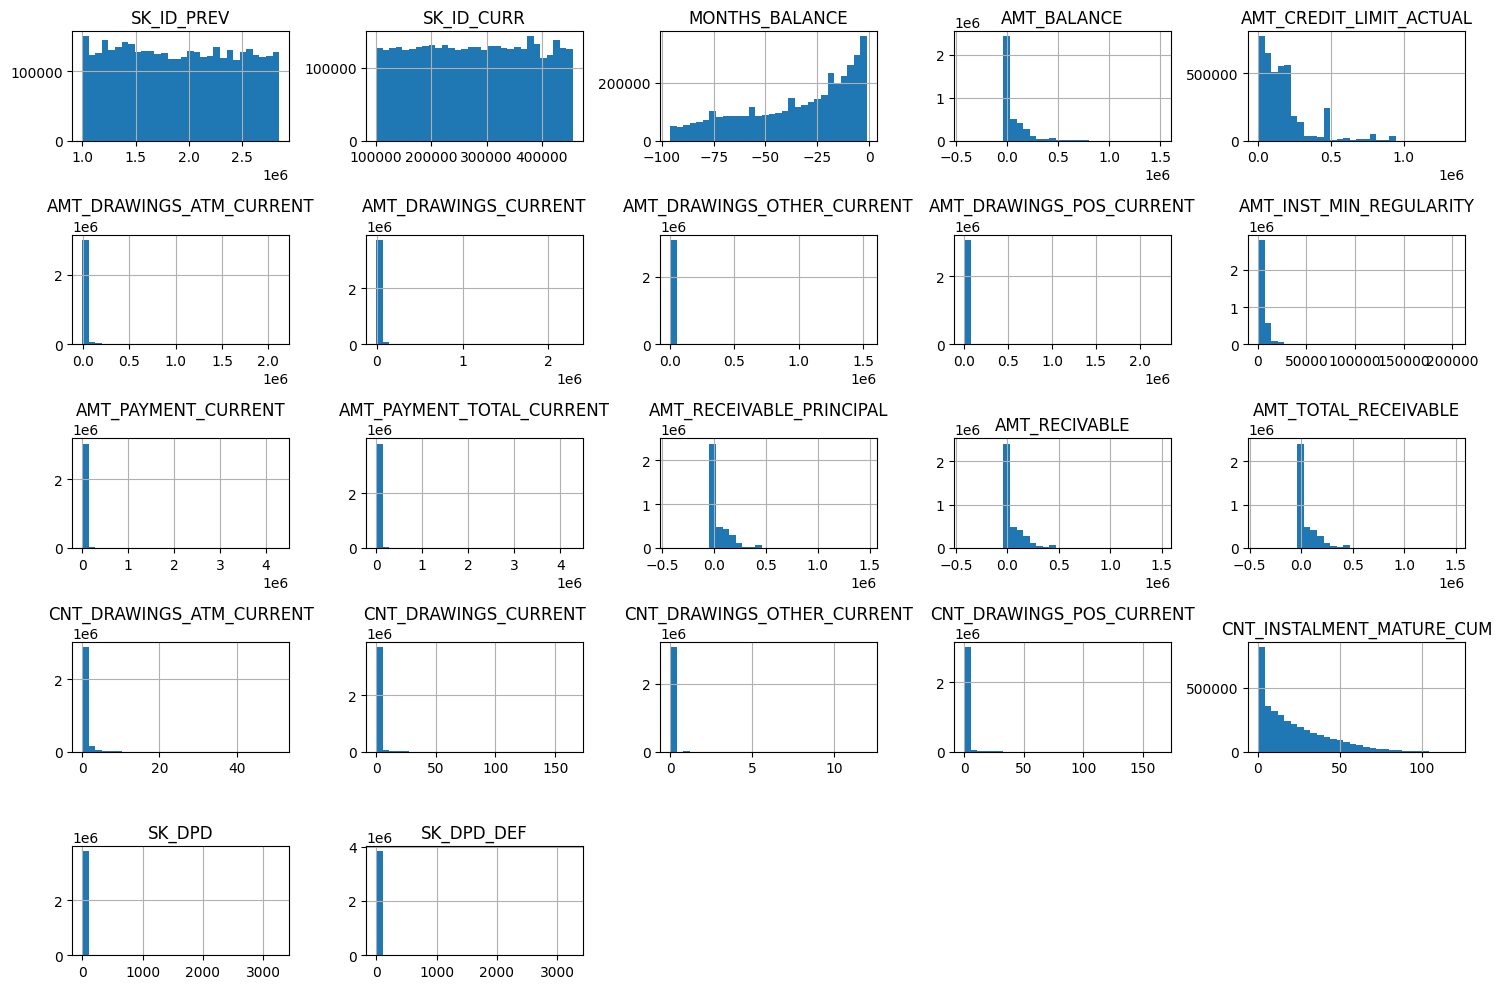

In [68]:
dfs['credit_card_balance'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 8. installments_payments table

In [69]:
dfs['installments_payments']

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585
...,...,...,...,...,...,...,...,...
13605396,2186857,428057,0.0,66,-1624.0,NaN,67.500,NaN
13605397,1310347,414406,0.0,47,-1539.0,NaN,67.500,NaN
13605398,1308766,402199,0.0,43,-7.0,NaN,43737.435,NaN
13605399,1062206,409297,0.0,43,-1986.0,NaN,67.500,NaN


In [70]:
dfs['installments_payments'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [71]:
((dfs['installments_payments'].isnull().sum() / len(dfs['installments_payments'])) * 100).round(2).sort_values(ascending=False)

DAYS_ENTRY_PAYMENT        0.02
AMT_PAYMENT               0.02
SK_ID_PREV                0.00
SK_ID_CURR                0.00
NUM_INSTALMENT_VERSION    0.00
NUM_INSTALMENT_NUMBER     0.00
DAYS_INSTALMENT           0.00
AMT_INSTALMENT            0.00
dtype: float64

<Axes: >

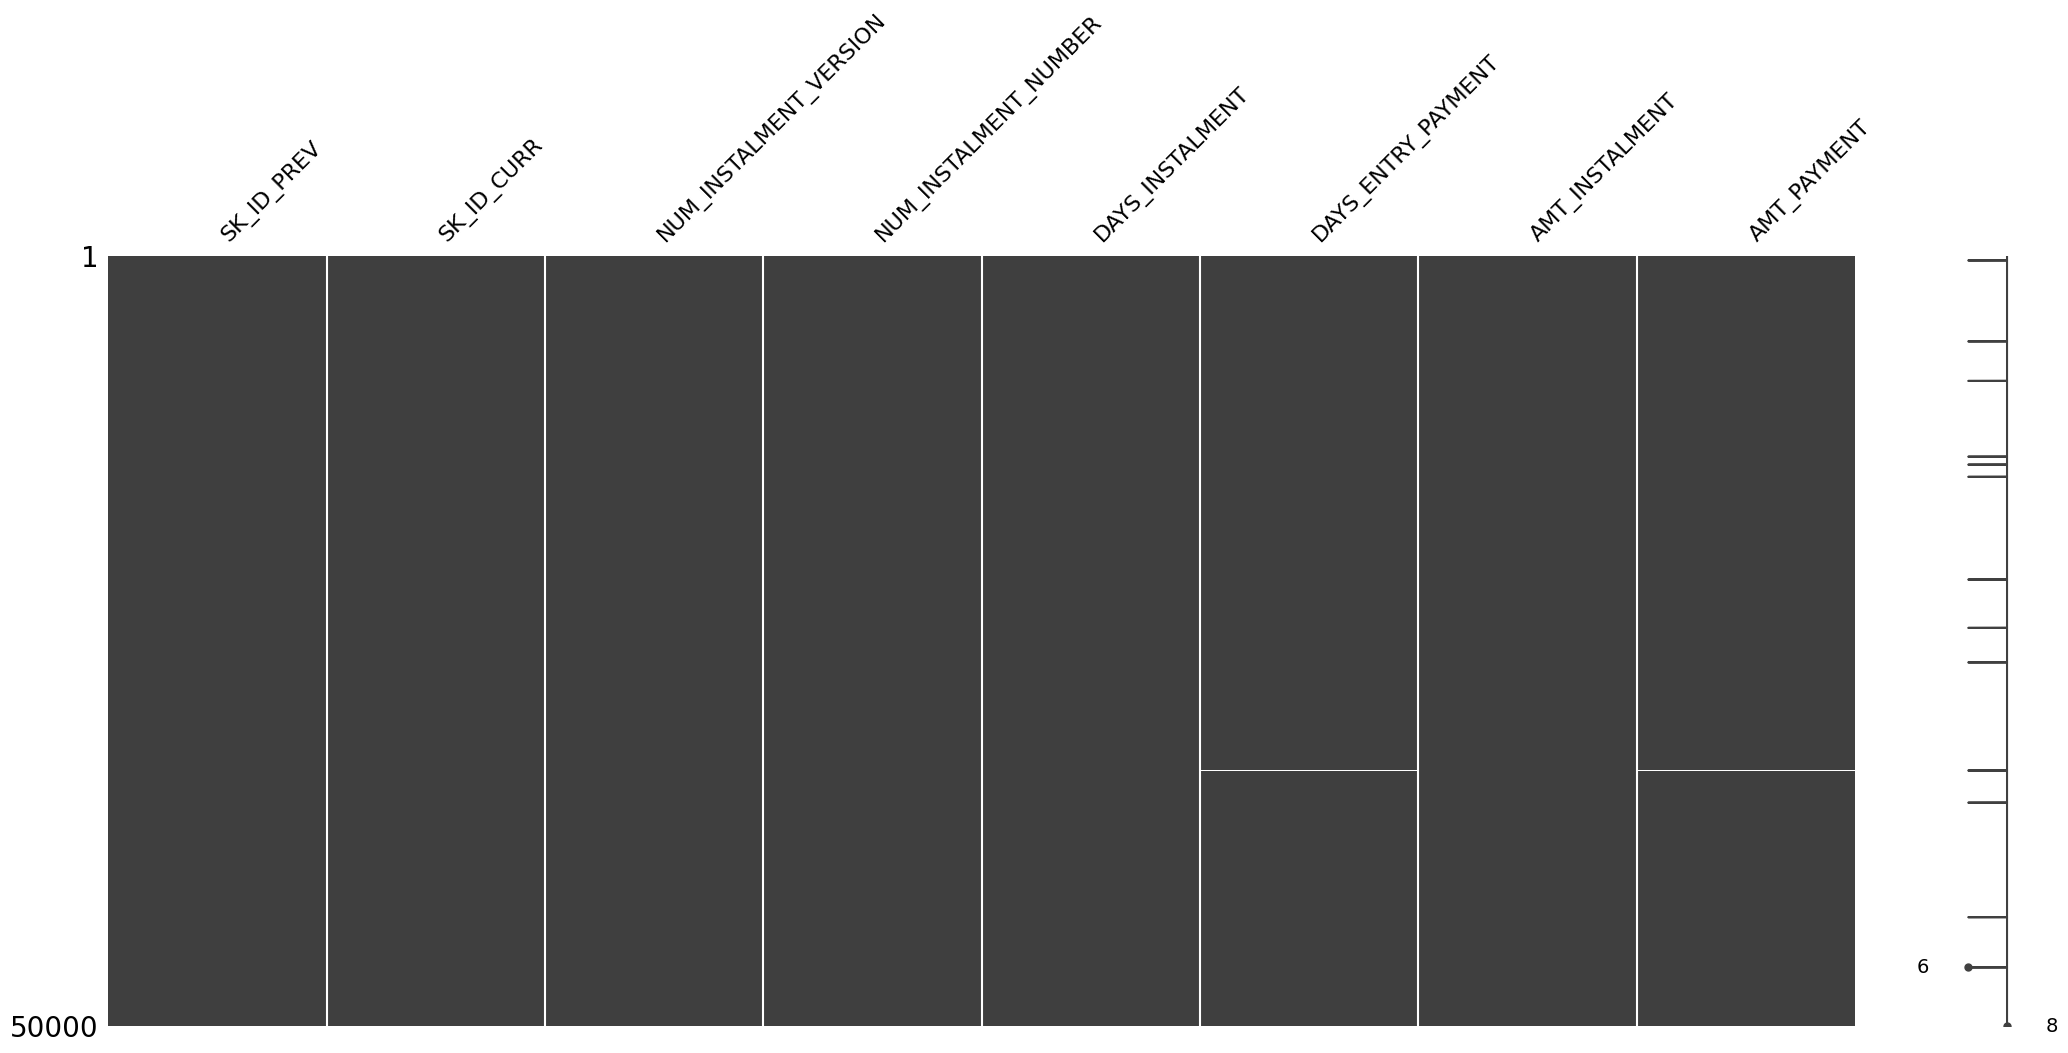

In [72]:
%matplotlib inline
msno.matrix(dfs['installments_payments'].sample(50000))

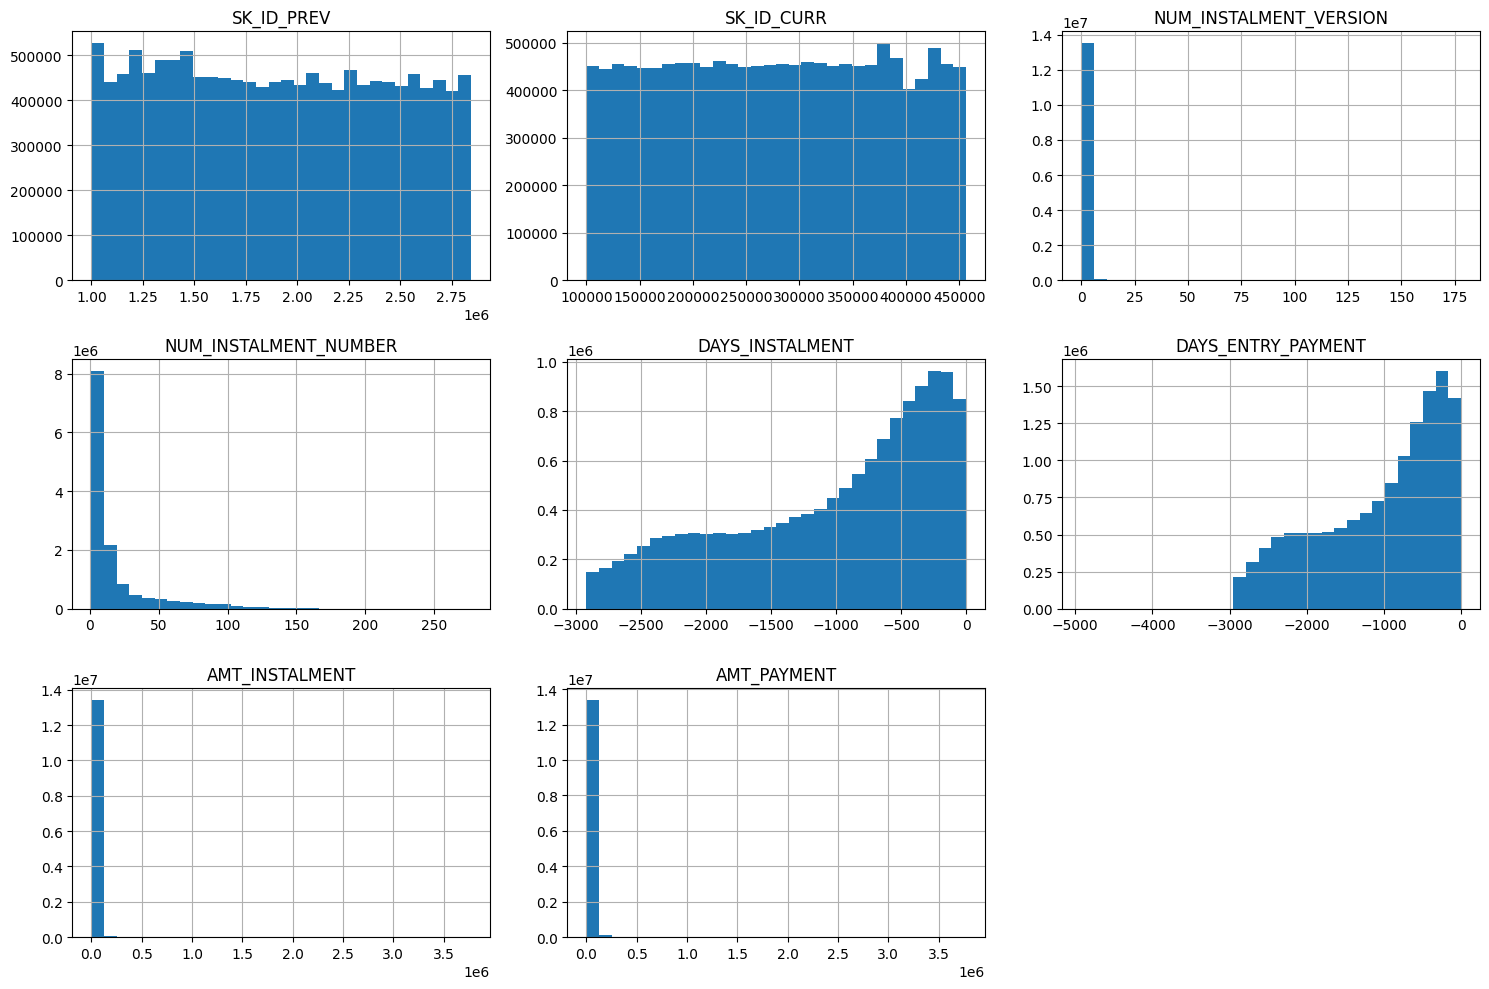

In [73]:
import matplotlib.pyplot as plt

dfs['installments_payments'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 9. prev_application table

In [74]:
dfs['prev_application']

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290,267295.5,311400.0,0.0,267295.5,WEDNESDAY,12,...,Furniture,30.0,low_normal,POS industry with interest,365243.0,-508.0,362.0,-358.0,-351.0,0.0
1670210,2357031,334635,Consumer loans,6622.020,87750.0,64291.5,29250.0,87750.0,TUESDAY,15,...,Furniture,12.0,middle,POS industry with interest,365243.0,-1604.0,-1274.0,-1304.0,-1297.0,0.0
1670211,2659632,249544,Consumer loans,11520.855,105237.0,102523.5,10525.5,105237.0,MONDAY,12,...,Consumer electronics,10.0,low_normal,POS household with interest,365243.0,-1457.0,-1187.0,-1187.0,-1181.0,0.0
1670212,2785582,400317,Cash loans,18821.520,180000.0,191880.0,NaN,180000.0,WEDNESDAY,9,...,XNA,12.0,low_normal,Cash X-Sell: low,365243.0,-1155.0,-825.0,-825.0,-817.0,1.0


In [75]:
dfs['prev_application'].info(verbose=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [76]:
((dfs['prev_application'].isnull().sum() / len(dfs['prev_application'])) * 100).round(2).sort_values(ascending=False)

RATE_INTEREST_PRIVILEGED       99.64
RATE_INTEREST_PRIMARY          99.64
RATE_DOWN_PAYMENT              53.64
AMT_DOWN_PAYMENT               53.64
NAME_TYPE_SUITE                49.12
NFLAG_INSURED_ON_APPROVAL      40.30
DAYS_FIRST_DRAWING             40.30
DAYS_FIRST_DUE                 40.30
DAYS_LAST_DUE_1ST_VERSION      40.30
DAYS_LAST_DUE                  40.30
DAYS_TERMINATION               40.30
AMT_GOODS_PRICE                23.08
AMT_ANNUITY                    22.29
CNT_PAYMENT                    22.29
PRODUCT_COMBINATION             0.02
CHANNEL_TYPE                    0.00
NAME_PRODUCT_TYPE               0.00
NAME_YIELD_GROUP                0.00
SELLERPLACE_AREA                0.00
NAME_SELLER_INDUSTRY            0.00
NAME_GOODS_CATEGORY             0.00
NAME_PORTFOLIO                  0.00
SK_ID_PREV                      0.00
NAME_CLIENT_TYPE                0.00
CODE_REJECT_REASON              0.00
SK_ID_CURR                      0.00
DAYS_DECISION                   0.00
N

<Axes: >

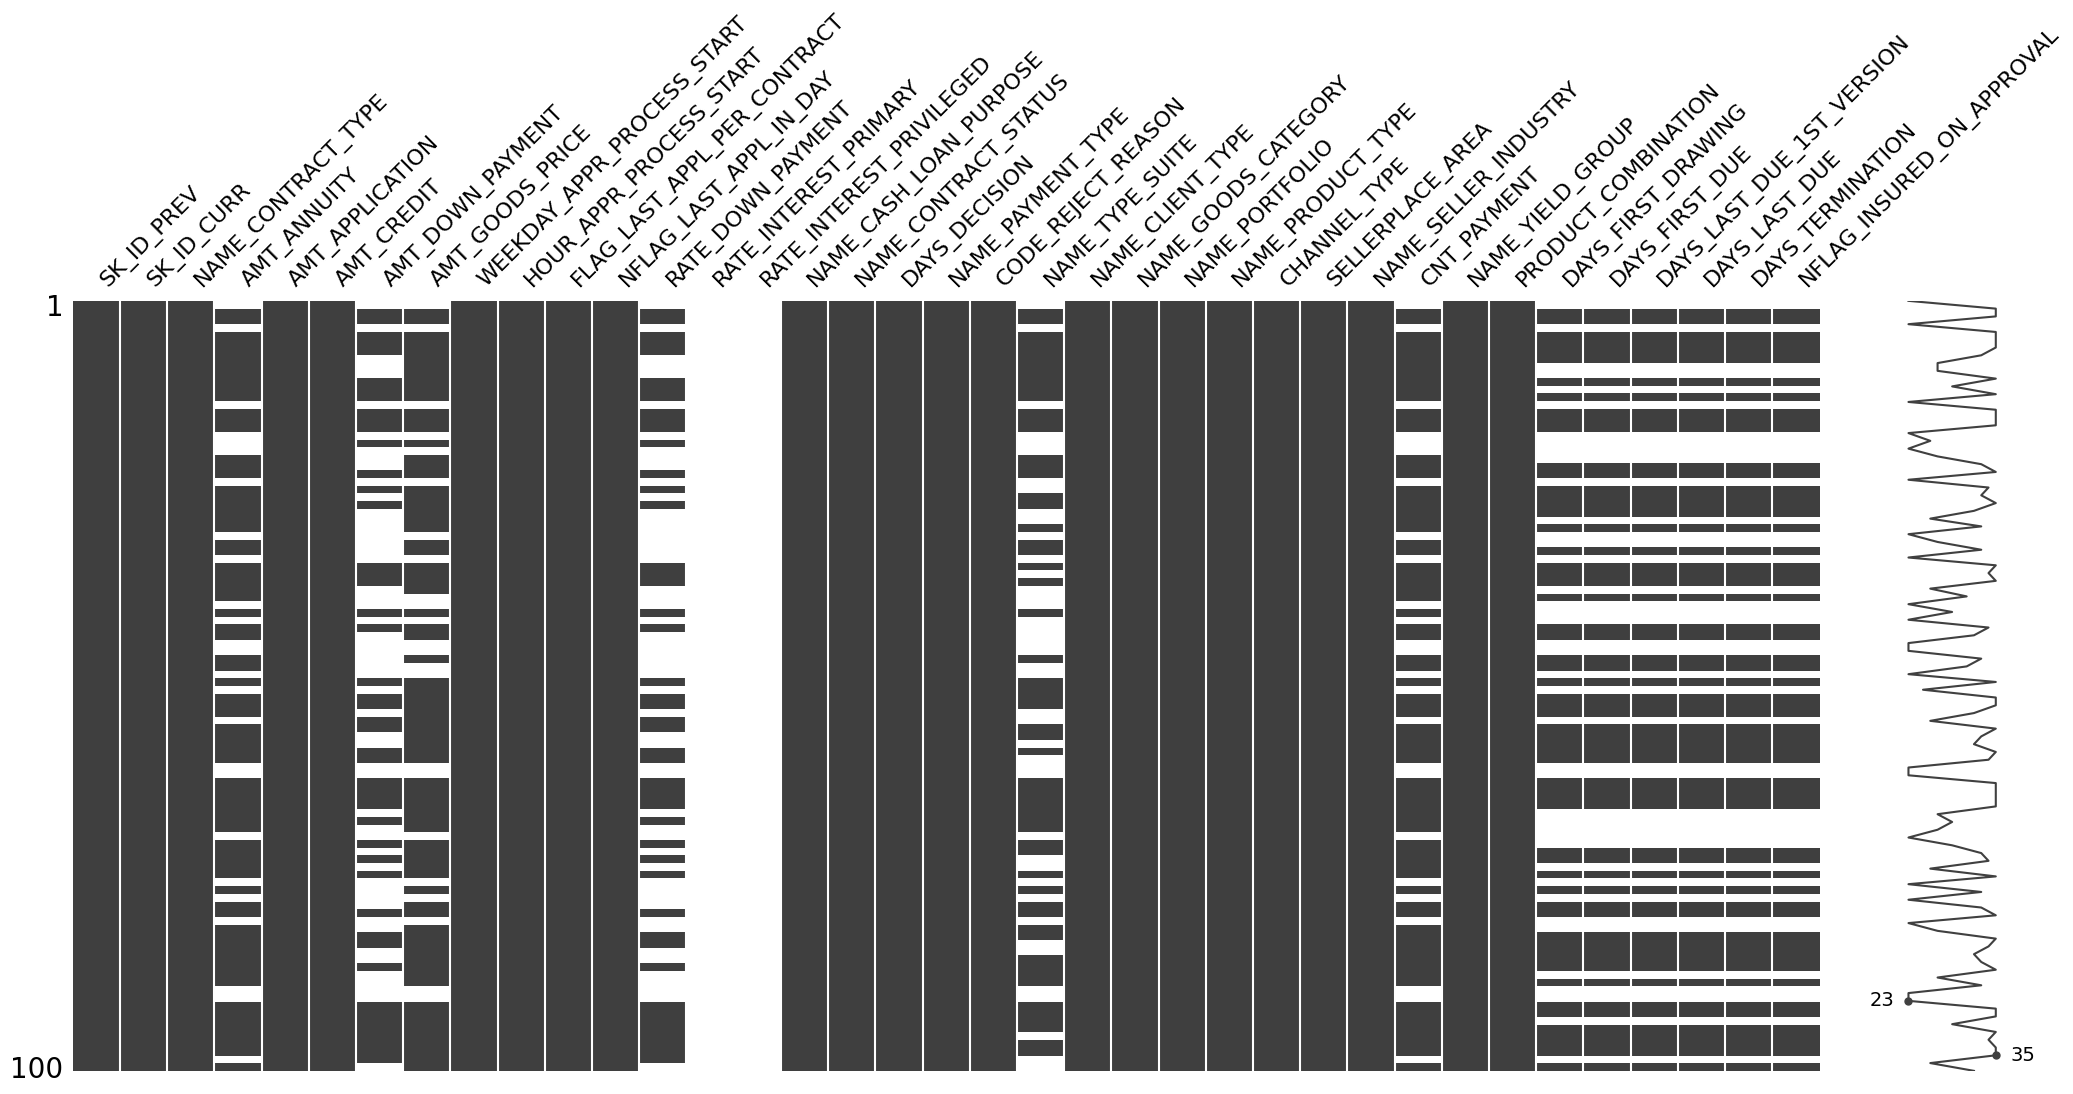

In [77]:
%matplotlib inline
msno.matrix(dfs['prev_application'].sample(100))

In [78]:
with pd.option_context('display.max_rows', 130):
    display(
        dfs['prev_application'].nunique().sort_values(ascending=False))

SK_ID_PREV                     1670214
AMT_ANNUITY                     357959
SK_ID_CURR                      338857
RATE_DOWN_PAYMENT               207033
AMT_APPLICATION                  93885
AMT_GOODS_PRICE                  93885
AMT_CREDIT                       86803
AMT_DOWN_PAYMENT                 29278
DAYS_LAST_DUE_1ST_VERSION         4605
DAYS_DECISION                     2922
DAYS_FIRST_DUE                    2892
DAYS_LAST_DUE                     2873
DAYS_FIRST_DRAWING                2838
DAYS_TERMINATION                  2830
SELLERPLACE_AREA                  2097
RATE_INTEREST_PRIMARY              148
CNT_PAYMENT                         49
NAME_GOODS_CATEGORY                 28
NAME_CASH_LOAN_PURPOSE              25
RATE_INTEREST_PRIVILEGED            25
HOUR_APPR_PROCESS_START             24
PRODUCT_COMBINATION                 17
NAME_SELLER_INDUSTRY                11
CODE_REJECT_REASON                   9
CHANNEL_TYPE                         8
NAME_TYPE_SUITE          

In [79]:
for col in dfs['prev_application'].columns:
    n = dfs['prev_application'][col].nunique()
    if (n <= 30 and n > 2): # Only columns with fewer than 30 unique values, but more than 2, are displayed (this excludes flags and other binary columns)
        print(f"{col} ({n} values) :", dfs['prev_application'][col].unique(), "\n")

NAME_CONTRACT_TYPE (4 values) : ['Consumer loans' 'Cash loans' 'Revolving loans' 'XNA'] 

WEEKDAY_APPR_PROCESS_START (7 values) : ['SATURDAY' 'THURSDAY' 'TUESDAY' 'MONDAY' 'FRIDAY' 'SUNDAY' 'WEDNESDAY'] 

HOUR_APPR_PROCESS_START (24 values) : [15 11  7  9  8 10 12 13 14 16  6  4  5 19 17 18 20 22 21  3  1  2 23  0] 

RATE_INTEREST_PRIVILEGED (25 values) : [0.86733615        nan 0.83509514 0.56871036 0.84513742 0.852537
 0.71564482 0.63794926 0.82082452 0.4244186  0.83245243 0.6448203
 0.51374207 0.54281184 0.37315011 0.80655391 0.50211416 0.63742072
 0.72515856 0.78065539 1.         0.54809725 0.79069767 0.48414376
 0.43657505 0.85465116] 

NAME_CASH_LOAN_PURPOSE (25 values) : ['XAP' 'XNA' 'Repairs' 'Everyday expenses' 'Car repairs'
 'Building a house or an annex' 'Other' 'Journey'
 'Purchase of electronic equipment' 'Medicine' 'Payments on other loans'
 'Urgent needs' 'Buying a used car' 'Buying a new car'
 'Buying a holiday home / land' 'Education' 'Buying a home' 'Furniture'
 'Buyin

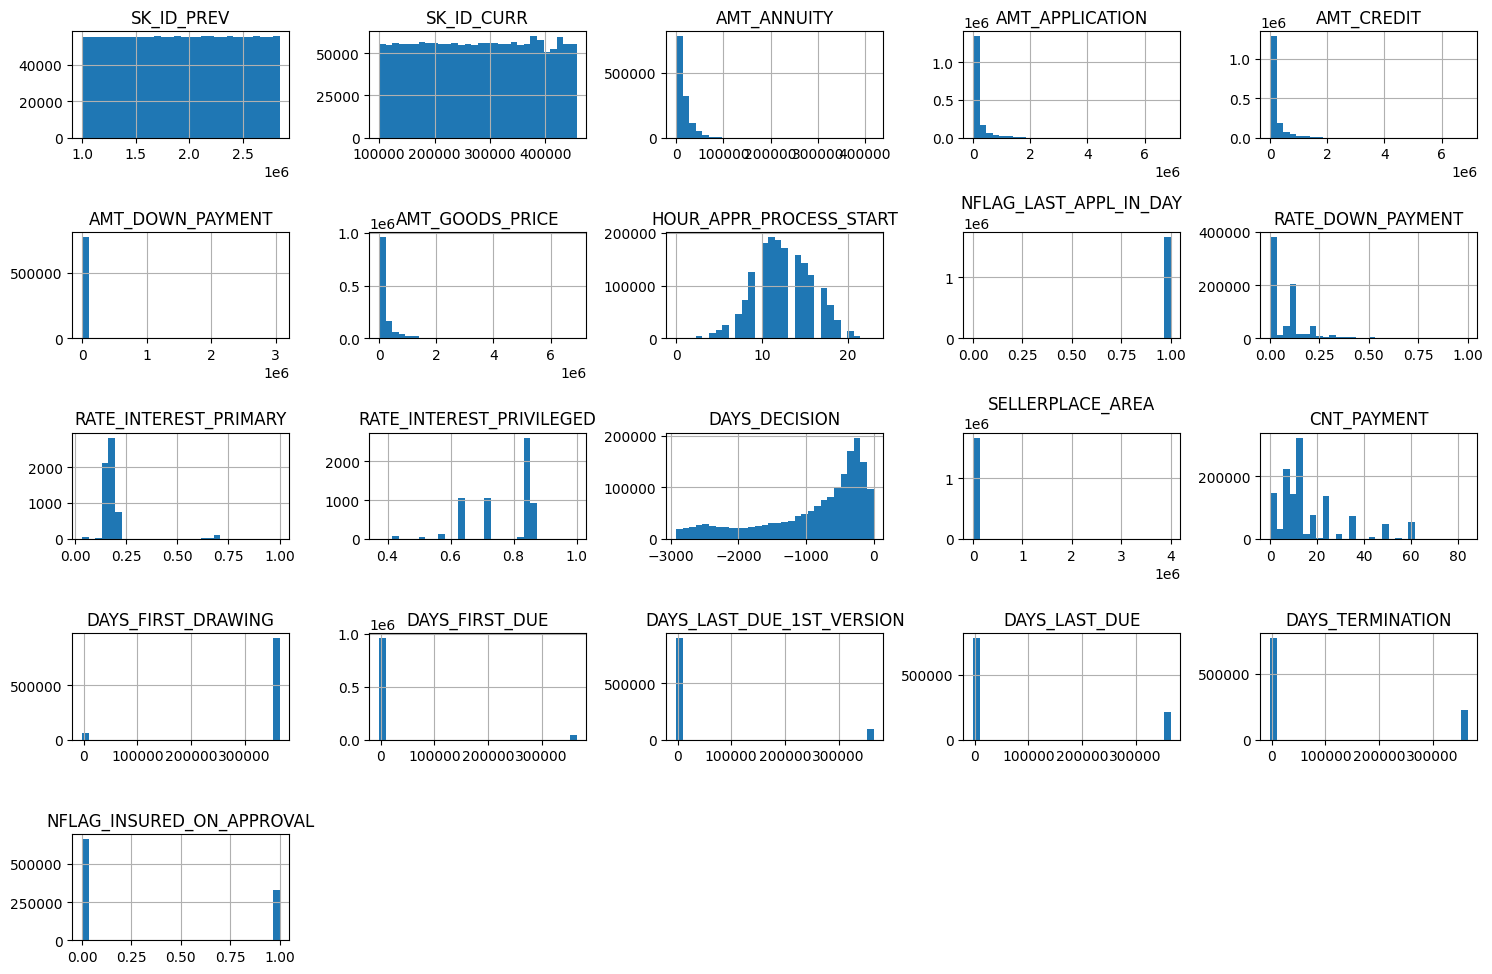

In [80]:
import matplotlib.pyplot as plt

dfs['prev_application'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

##### 10. sample_submission table

In [81]:
dfs['sample_submission']

,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5
...,...,...
48739,456221,0.5
48740,456222,0.5
48741,456223,0.5
48742,456224,0.5


In [82]:
dfs['sample_submission']['TARGET'].unique()

array([0.5])

## JOIN AND MERGE

## 1. BUREAU & BUREAU_BALANCE

In [123]:
dfs['bureau']

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [130]:
dfs['bureau_balance']

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27299920,5041336,-47,X
27299921,5041336,-48,X
27299922,5041336,-49,X
27299923,5041336,-50,X


In [131]:
dfs['bureau_balance'][dfs['bureau_balance']['SK_ID_BUREAU']==5715448]

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
5,5715448,-5,C
6,5715448,-6,C
7,5715448,-7,C
8,5715448,-8,C
9,5715448,-9,0


A **credit bureau** is an external organisation that *centralises all of a person's credits, gathered from different lending institutions*. 

A client might have a mortgage with one bank, a credit card with another, and a car loan at a dealership — *the credit bureau knows about all of them and tracks them.* 

As a result, a client can have several credits (one `SK_ID_CURR` mapped to several `SK_ID_BUREAU`) in the bureau table. For example, three rows sharing the same `SK_ID_CURR` (each with a different `SK_ID_BUREAU`) mean the client has three different credits.

**bureau_balance** gives further detail on the payment `STATUS` of each credit, month by month, since it was opened. For example, if a `SK_ID_BUREAU` has 24 rows, it means this specific credit has been monitored monthly for the past 2 years, and it is linked back to a `SK_ID_CURR`, the client ID.

In [138]:
import pandas as pd

pd.DataFrame(dfs['bureau_balance'].groupby(by='SK_ID_BUREAU', as_index=False)['STATUS'])

,0,1
0,5001709,26079753 C 26079754 C 26079755 C 2607...
1,5001710,2846316 C 2846317 C 2846318 C 2846319...
2,5001711,2846399 X 2846400 0 2846401 0 2846402...
3,5001712,2846403 C 2846404 C 2846405 C 2846406...
4,5001713,1415228 X 1415229 X 1415230 X 1415231...
...,...,...
817390,6842884,23543861 C 23543862 C 23543863 C 2354...
817391,6842885,23543909 5 23543910 5 23543911 5 2354...
817392,6842886,23543933 C 23543934 C 23543935 C 2354...
817393,6842887,23543966 C 23543967 C 23543968 C 2354...


In [171]:
pd.DataFrame(dfs['bureau_balance'].groupby(by='SK_ID_BUREAU', as_index=False)['STATUS']).value_counts()

TypeError: unhashable type: 'Series'

In [134]:
# PREPARE BUREAU_BALANCE
df_bureau_balance = (
    dfs['bureau_balance']
    .groupby('SK_ID_BUREAU')['STATUS']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

df_bureau_balance

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X
0,5001709,0,0,0,0,0,0,86,11
1,5001710,5,0,0,0,0,0,48,30
2,5001711,3,0,0,0,0,0,0,1
3,5001712,10,0,0,0,0,0,9,0
4,5001713,0,0,0,0,0,0,0,22
...,...,...,...,...,...,...,...,...,...
817390,6842884,9,0,0,0,0,0,20,19
817391,6842885,12,0,0,0,0,12,0,0
817392,6842886,8,0,0,0,0,0,25,0
817393,6842887,6,0,0,0,0,0,31,0


The method we use is `groupby('SK_ID_BUREAU')['STATUS'].value_counts().unstack(fill_value=0)`, which, for each credit (SK_ID_BUREAU), counts how many months were spent in each STATUS category, then reshapes the result so that each STATUS value becomes its own column.

In [137]:
df = dfs['bureau'].merge(df_bureau_balance, on='SK_ID_BUREAU', how='left')
df

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,DAYS_CREDIT_UPDATE,AMT_ANNUITY,0,1,2,3,4,5,C,X
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,...,-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,...,-2493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,...,-967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,...,-1508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. PREVIOUS APPLICATION - POS_CASH_balance, credit_card_balance, installments_payments

### Aggregation

In [140]:
dfs['installments_payments']['SK_ID_CURR'].sort_values()

3458712     100001
3435373     100001
2624024     100001
1761012     100001
3774071     100001
             ...  
11551234    456255
13087700    456255
11589266    456255
12567614    456255
11683864    456255
Name: SK_ID_CURR, Length: 13605401, dtype: int64

In [ ]:
dfs['prev_application']['SK_ID_CURR'].isin(
    dfs['application_train']['SK_ID_CURR']
)

0           True
1           True
2           True
3           True
4           True
           ...  
1670209    False
1670210    False
1670211     True
1670212     True
1670213     True
Name: SK_ID_CURR, Length: 1670214, dtype: bool

Étape A — agréger les 3 tables mensuelles sur SK_ID_PREV

In [143]:
dfs['POS_CASH'].sort_values(by='SK_ID_CURR')

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
8531326,1851984,100001,-94,4.0,0.0,Active,0,0
1891462,1851984,100001,-95,4.0,1.0,Active,7,7
8789081,1369693,100001,-56,4.0,3.0,Active,0,0
4704415,1369693,100001,-54,4.0,1.0,Active,0,0
7167007,1369693,100001,-57,4.0,4.0,Active,0,0
...,...,...,...,...,...,...,...,...
3839119,2631384,456255,-6,36.0,16.0,Active,0,0
4876277,2631384,456255,-5,36.0,15.0,Active,0,0
1386050,2631384,456255,-11,36.0,21.0,Active,0,0
3766097,2631384,456255,-25,36.0,35.0,Active,0,0


In [146]:
dfs['POS_CASH']['NAME_CONTRACT_STATUS'].nunique()

9

In [164]:
with pd.option_context('display.max_rows', None):
    display(dfs['POS_CASH'][dfs['POS_CASH']['SK_ID_CURR']==456255].sort_values(by=['SK_ID_PREV', 'MONTHS_BALANCE']))

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
1743388,1179690,456255,-23,24.0,24.0,Active,0,0
3850938,1179690,456255,-22,24.0,23.0,Active,0,0
5254110,1179690,456255,-21,24.0,22.0,Active,0,0
1810321,1179690,456255,-20,24.0,21.0,Active,0,0
1792408,1179690,456255,-19,24.0,20.0,Active,0,0
1293593,1179690,456255,-18,24.0,19.0,Active,0,0
2537781,1179690,456255,-17,24.0,18.0,Active,0,0
136414,1179690,456255,-16,24.0,17.0,Active,0,0
82281,1179690,456255,-15,24.0,16.0,Active,0,0
2099940,1179690,456255,-14,24.0,15.0,Active,0,0


In [166]:
# 1. Transforms values in NAME_CONTRACT_STATUS into dummies
status_dummies = pd.get_dummies(dfs['POS_CASH']['NAME_CONTRACT_STATUS'], prefix='POS_STATUS')
status_dummies

,POS_STATUS_Active,POS_STATUS_Amortized debt,POS_STATUS_Approved,POS_STATUS_Canceled,POS_STATUS_Completed,POS_STATUS_Demand,POS_STATUS_Returned to the store,POS_STATUS_Signed,POS_STATUS_XNA
0,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
10001353,True,False,False,False,False,False,False,False,False
10001354,True,False,False,False,False,False,False,False,False
10001355,True,False,False,False,False,False,False,False,False
10001356,True,False,False,False,False,False,False,False,False


In [167]:
# 2. Place these 0/1 columns next to POS_CASH
pos = pd.concat([dfs['POS_CASH'], status_dummies], axis=1)
pos 

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF,POS_STATUS_Active,POS_STATUS_Amortized debt,POS_STATUS_Approved,POS_STATUS_Canceled,POS_STATUS_Completed,POS_STATUS_Demand,POS_STATUS_Returned to the store,POS_STATUS_Signed,POS_STATUS_XNA
0,1803195,182943,-31,48.0,45.0,Active,0,0,True,False,False,False,False,False,False,False,False
1,1715348,367990,-33,36.0,35.0,Active,0,0,True,False,False,False,False,False,False,False,False
2,1784872,397406,-32,12.0,9.0,Active,0,0,True,False,False,False,False,False,False,False,False
3,1903291,269225,-35,48.0,42.0,Active,0,0,True,False,False,False,False,False,False,False,False
4,2341044,334279,-35,36.0,35.0,Active,0,0,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.0,0.0,Active,843,0,True,False,False,False,False,False,False,False,False
10001354,1717234,141565,-19,12.0,0.0,Active,602,0,True,False,False,False,False,False,False,False,False
10001355,1283126,315695,-21,10.0,0.0,Active,609,0,True,False,False,False,False,False,False,False,False
10001356,1082516,450255,-22,12.0,0.0,Active,614,0,True,False,False,False,False,False,False,False,False


In [168]:
# 3. PREPARATION FOR THE AGGREGATION
# Use a dictionary : focus on the numeric columns first...
agg_dict = {
    'MONTHS_BALANCE': 'count',
    'CNT_INSTALMENT': 'mean',
    'CNT_INSTALMENT_FUTURE': 'mean',
    'SK_DPD': 'max',
    'SK_DPD_DEF': 'max',
}
# ...then add 'sum' for each dummy columns we just created
for col in status_dummies.columns:
    agg_dict[col] = 'sum'


In [169]:
agg_dict

{'MONTHS_BALANCE': 'count',
 'CNT_INSTALMENT': 'mean',
 'CNT_INSTALMENT_FUTURE': 'mean',
 'SK_DPD': 'max',
 'SK_DPD_DEF': 'max',
 'POS_STATUS_Active': 'sum',
 'POS_STATUS_Amortized debt': 'sum',
 'POS_STATUS_Approved': 'sum',
 'POS_STATUS_Canceled': 'sum',
 'POS_STATUS_Completed': 'sum',
 'POS_STATUS_Demand': 'sum',
 'POS_STATUS_Returned to the store': 'sum',
 'POS_STATUS_Signed': 'sum',
 'POS_STATUS_XNA': 'sum'}

In [170]:
# 4. AGGREGRATION
pos_agg = pos.groupby('SK_ID_PREV', as_index=False).agg(agg_dict)

pos_agg

,SK_ID_PREV,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF,POS_STATUS_Active,POS_STATUS_Amortized debt,POS_STATUS_Approved,POS_STATUS_Canceled,POS_STATUS_Completed,POS_STATUS_Demand,POS_STATUS_Returned to the store,POS_STATUS_Signed,POS_STATUS_XNA
0,1000001,3,8.666667,7.666667,0,0,2,0,0,0,1,0,0,0,0
1,1000002,5,5.200000,2.000000,0,0,4,0,0,0,1,0,0,0,0
2,1000003,4,12.000000,10.500000,0,0,4,0,0,0,0,0,0,0,0
3,1000004,8,9.625000,6.125000,0,0,7,0,0,0,1,0,0,0,0
4,1000005,11,10.000000,5.000000,0,0,10,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936320,2843494,3,32.666667,31.666667,0,0,2,0,0,0,1,0,0,0,0
936321,2843495,8,53.375000,49.875000,0,0,7,0,0,0,1,0,0,0,0
936322,2843497,21,24.000000,14.000000,0,0,21,0,0,0,0,0,0,0,0
936323,2843498,7,27.428571,24.285714,0,0,6,0,0,0,1,0,0,0,0


In [ ]:

cc_agg = dfs['credit_card_balance'].groupby('SK_ID_PREV', as_index=False).agg({
    'AMT_BALANCE': 'mean',
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean',
    'SK_DPD': 'max',
})

inst_agg = dfs['installments_payments'].groupby('SK_ID_PREV', as_index=False).agg({
    'AMT_INSTALMENT': 'mean',      # montant dû moyen par échéance
    'AMT_PAYMENT': 'mean',         # montant réellement payé moyen
    'DAYS_INSTALMENT': 'count',    # nb d'échéances
})

In [87]:
df = dfs['application_train']
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [88]:
df['SK_ID_CURR']

0         100002
1         100003
2         100004
3         100006
4         100007
           ...  
307506    456251
307507    456252
307508    456253
307509    456254
307510    456255
Name: SK_ID_CURR, Length: 307511, dtype: int64

In [89]:
dfs['sample_submission']['SK_ID_CURR'].isin(df['SK_ID_CURR'])

0        False
1        False
2        False
3        False
4        False
         ...  
48739    False
48740    False
48741    False
48742    False
48743    False
Name: SK_ID_CURR, Length: 48744, dtype: bool

In [90]:
dfs['sample_submission']['TARGET'].unique()

array([0.5])

In [ ]:
set(dfs['application_test']['SK_ID_CURR'])==set(dfs['sample_submission']['SK_ID_CURR'])

True

In [ ]:
set(dfs['bureau']['SK_ID_CURR'])==set(dfs['application_t']['SK_ID_CURR'])

False

In [ ]:
dfs['bureau']['SK_ID_BUREAU'].sort_values(ascending=True)

1706035    5000000
1706036    5000001
61505      5000002
61506      5000003
61507      5000004
            ...   
1705293    6843453
1705294    6843454
1705295    6843455
1705296    6843456
1705297    6843457
Name: SK_ID_BUREAU, Length: 1716428, dtype: int64

In [ ]:
ids_train = set(dfs['application_train']['SK_ID_CURR'])
ids_test = set(dfs['application_test']['SK_ID_CURR'])
ids_bureau = set(dfs['bureau']['SK_ID_CURR'])

print("bureau ids aussi dans train:", len(ids_bureau & ids_train))
print("bureau ids aussi dans test:", len(ids_bureau & ids_test))

bureau ids aussi dans train: 263491
bureau ids aussi dans test: 42320
